In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
# ============================================================
# CHECK CUDA, GPU, PYTORCH, AND OFFICIAL MAMBA
# ============================================================

import os
import sys
import torch

print("=" * 70)
print("1. PYTORCH AND GPU CHECK")
print("=" * 70)

print("PyTorch Version       :", torch.__version__)
print("PyTorch CUDA Version  :", torch.version.cuda)
print("CUDA Available        :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("Number of GPUs        :", torch.cuda.device_count())
    print("GPU Name              :", torch.cuda.get_device_name(0))
    print(
        "Compute Capability    :",
        torch.cuda.get_device_capability(0)
    )

    # Test whether PyTorch can actually execute on the GPU
    try:
        x = torch.randn(100, 100, device="cuda")
        y = x @ x

        print("CUDA Computation Test : PASSED ✅")
        print("Tensor Device         :", y.device)

    except Exception as e:

        print("CUDA Computation Test : FAILED ❌")
        print("CUDA Error            :", e)

else:

    print("GPU NOT AVAILABLE ❌")
    print("Enable Tesla T4 in Kaggle settings.")


print("\n" + "=" * 70)
print("2. MAMBA REPOSITORY CHECK")
print("=" * 70)

MAMBA_ROOT = (
    "/kaggle/input/models/"
    "likithasrimaddipatla/"
    "mamba-statespace-model/"
    "pytorch/default/1"
)

print("Mamba Path:")
print(MAMBA_ROOT)

print(
    "Repository Exists     :",
    os.path.exists(MAMBA_ROOT)
)

print(
    "mamba_ssm Exists      :",
    os.path.exists(
        os.path.join(MAMBA_ROOT, "mamba_ssm")
    )
)


print("\n" + "=" * 70)
print("3. OFFICIAL MAMBA IMPORT CHECK")
print("=" * 70)

# Make the repository visible to Python
if MAMBA_ROOT not in sys.path:
    sys.path.insert(0, MAMBA_ROOT)

try:

    from mamba_ssm.modules.mamba_simple import Mamba

    print("Official Mamba Import : PASSED ✅")
    print("Imported Class        :", Mamba)

except Exception as e:

    print("Official Mamba Import : FAILED ❌")
    print("Error Type            :", type(e).__name__)
    print("Error Message         :", str(e))


print("\n" + "=" * 70)
print("CHECK COMPLETED")
print("=" * 70)

In [1]:
# ============================================================
# VERIFY OFFICIAL MAMBA INSTALLATION
# ============================================================

import torch

print("=" * 70)
print("ENVIRONMENT")
print("=" * 70)

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.version.cuda)
print("GPU     :", torch.cuda.get_device_name(0))
print("CUDA OK :", torch.cuda.is_available())

print("\n" + "=" * 70)
print("MAMBA IMPORT")
print("=" * 70)

from mamba_ssm import Mamba

print("Official Mamba import: PASSED ✅")
print("Mamba class:", Mamba)

print("\n" + "=" * 70)
print("MAMBA FORWARD-PASS TEST")
print("=" * 70)

device = torch.device("cuda")

model = Mamba(
    d_model=128,  # Same as our CNN feature dimension
    d_state=16,
    d_conv=4,
    expand=2
).to(device)

# Simulates:
# 2 cell tracks × 30 time steps × 128 CNN features
x = torch.randn(
    2,
    30,
    128,
    device=device
)

model.eval()

with torch.no_grad():
    y = model(x)

print("Input Shape  :", x.shape)
print("Output Shape :", y.shape)
print("Output Device:", y.device)

assert y.shape == x.shape

print("\nOFFICIAL MAMBA TEST PASSED ✅")

ENVIRONMENT
PyTorch : 2.10.0+cu128
CUDA    : 12.8
GPU     : Tesla T4
CUDA OK : True

MAMBA IMPORT
Official Mamba import: PASSED ✅
Mamba class: <class 'mamba_ssm.modules.mamba_simple.Mamba'>

MAMBA FORWARD-PASS TEST
Input Shape  : torch.Size([2, 30, 128])
Output Shape : torch.Size([2, 30, 128])
Output Device: cuda:0

OFFICIAL MAMBA TEST PASSED ✅


In [5]:
from mamba_ssm import Mamba

In [6]:
import time

print("Starting Mamba import...")

start = time.time()

try:
    from mamba_ssm.modules.mamba_simple import Mamba

    print("Mamba import: PASSED ✅")
    print("Import time:", round(time.time() - start, 2), "seconds")
    print("Mamba class:", Mamba)

except Exception as e:

    print("Mamba import: FAILED ❌")
    print("Error type:", type(e).__name__)
    print("Error:", e)

Starting Mamba import...
Mamba import: PASSED ✅
Import time: 0.0 seconds
Mamba class: <class 'mamba_ssm.modules.mamba_simple.Mamba'>


In [7]:
import torch

device = "cuda"

mamba = Mamba(
    d_model=128,
    d_state=16,
    d_conv=4,
    expand=2
).to(device)

x = torch.randn(
    1,      # one cell trajectory
    30,     # 30 frames
    128,    # CNN features
    device=device
)

print("Input :", x.shape)

mamba.eval()

with torch.no_grad():
    y = mamba(x)

print("Output:", y.shape)
print("Device:", y.device)

Input : torch.Size([1, 30, 128])
Output: torch.Size([1, 30, 128])
Device: cuda:0


In [8]:
# ============================================================
# CELL 1 — IMPORTS, DEVICE, PATHS
# ============================================================

import os
import glob
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from mamba_ssm import Mamba


# ---------------- DEVICE ----------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("ENVIRONMENT")
print("=" * 70)

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.version.cuda)
print("Device  :", device)

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))


# ---------------- DATA PATHS ----------------

ROOT = (
    "/kaggle/input/datasets/"
    "likithasrimaddipatla/"
    "hela-train/"
    "DIC-C2DH-HeLa"
)

SEQUENCE = "01"

IMAGE_DIR = os.path.join(
    ROOT,
    SEQUENCE
)

TRACK_MASK_DIR = os.path.join(
    ROOT,
    f"{SEQUENCE}_GT",
    "TRA"
)

LINEAGE_FILE = os.path.join(
    TRACK_MASK_DIR,
    "man_track.txt"
)


# ---------------- FIND FILES ----------------

image_files = sorted(
    glob.glob(
        os.path.join(
            IMAGE_DIR,
            "t*.tif"
        )
    )
)

track_mask_files = sorted(
    glob.glob(
        os.path.join(
            TRACK_MASK_DIR,
            "man_track*.tif"
        )
    )
)


# ---------------- PRINT RESULTS ----------------

print("\n" + "=" * 70)
print("CTC DATA")
print("=" * 70)

print("Root exists        :", os.path.exists(ROOT))
print("Image directory    :", os.path.exists(IMAGE_DIR))
print("Track-mask folder  :", os.path.exists(TRACK_MASK_DIR))

print("\nRaw frames         :", len(image_files))
print("Tracking masks     :", len(track_mask_files))
print("Lineage file       :", os.path.exists(LINEAGE_FILE))

if len(image_files) > 0:
    print("\nFirst image:")
    print(image_files[0])

if len(track_mask_files) > 0:
    print("\nFirst tracking mask:")
    print(track_mask_files[0])


# ---------------- SAFETY CHECK ----------------

assert len(image_files) == 84, (
    f"Expected 84 images, found {len(image_files)}"
)

assert len(track_mask_files) == 84, (
    f"Expected 84 tracking masks, "
    f"found {len(track_mask_files)}"
)

print("\nCELL 1 PASSED ✅")

ENVIRONMENT
PyTorch : 2.10.0+cu128
CUDA    : 12.8
Device  : cuda
GPU     : Tesla T4

CTC DATA
Root exists        : True
Image directory    : True
Track-mask folder  : True

Raw frames         : 84
Tracking masks     : 84
Lineage file       : True

First image:
/kaggle/input/datasets/likithasrimaddipatla/hela-train/DIC-C2DH-HeLa/01/t000.tif

First tracking mask:
/kaggle/input/datasets/likithasrimaddipatla/hela-train/DIC-C2DH-HeLa/01_GT/TRA/man_track000.tif

CELL 1 PASSED ✅


FRAME AND TRACKING-MASK CHECK
Frame index        : 0

Raw frame shape    : (512, 512)
Raw frame dtype    : uint8
Raw intensity range: 47 to 255

Track mask shape   : (512, 512)
Track mask dtype   : uint16

Unique mask values : [ 0  1  5  7 11 15 19 23 27 32 34]
Cell Track IDs     : [ 1  5  7 11 15 19 23 27 32 34]
Cells in frame     : 10


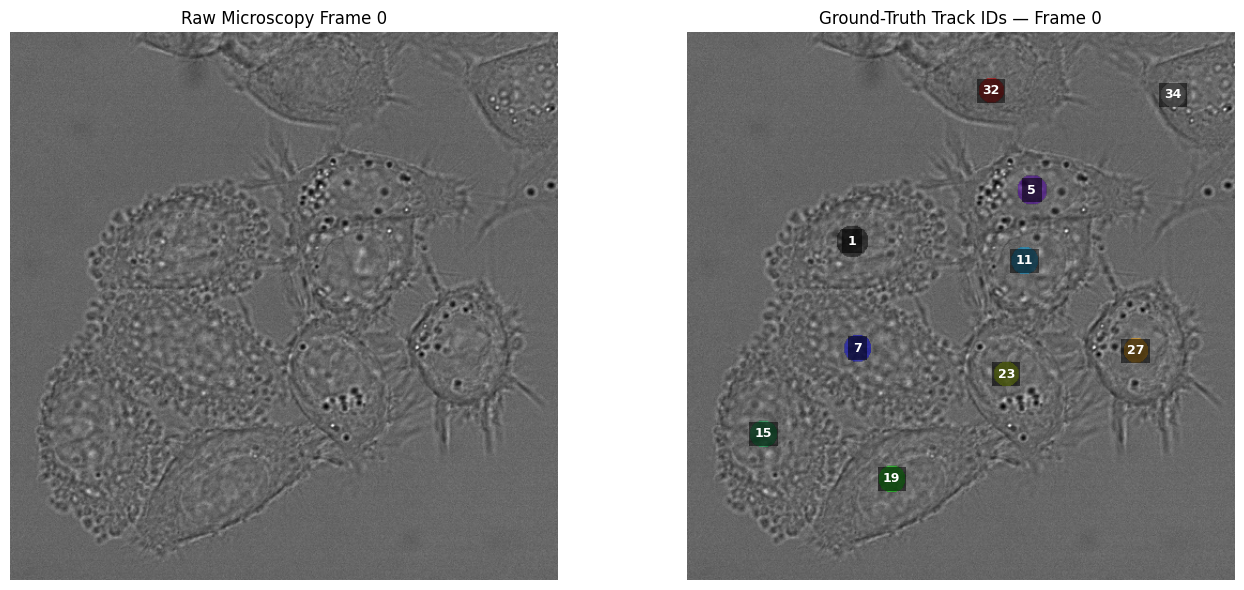


CELL 2 PASSED ✅


In [9]:
# ============================================================
# CELL 2 — LOAD AND VISUALIZE RAW FRAME + TRACKING MASK
# ============================================================

# Choose a frame
frame_idx = 0

# Load raw microscopy image
raw_frame = np.array(
    Image.open(image_files[frame_idx])
)

# Load ground-truth tracking mask
track_mask = np.array(
    Image.open(track_mask_files[frame_idx])
)


print("=" * 70)
print("FRAME AND TRACKING-MASK CHECK")
print("=" * 70)

print("Frame index        :", frame_idx)

print("\nRaw frame shape    :", raw_frame.shape)
print("Raw frame dtype    :", raw_frame.dtype)
print("Raw intensity range:",
      raw_frame.min(), "to", raw_frame.max())

print("\nTrack mask shape   :", track_mask.shape)
print("Track mask dtype   :", track_mask.dtype)

# 0 is background; every nonzero value is a cell Track ID
track_ids = np.unique(track_mask)
cell_track_ids = track_ids[track_ids != 0]

print("\nUnique mask values :", track_ids)
print("Cell Track IDs     :", cell_track_ids)
print("Cells in frame     :", len(cell_track_ids))


# ---------------- VISUALIZATION ----------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# Raw microscopy frame
axes[0].imshow(
    raw_frame,
    cmap="gray"
)

axes[0].set_title(
    f"Raw Microscopy Frame {frame_idx}"
)

axes[0].axis("off")


# Ground-truth tracking mask
mask_display = np.ma.masked_where(
    track_mask == 0,
    track_mask
)

axes[1].imshow(
    raw_frame,
    cmap="gray"
)

axes[1].imshow(
    mask_display,
    alpha=0.55,
    cmap="nipy_spectral"
)

axes[1].set_title(
    f"Ground-Truth Track IDs — Frame {frame_idx}"
)

axes[1].axis("off")


# Add Track ID number at the center of each cell
for track_id in cell_track_ids:

    rows, cols = np.where(
        track_mask == track_id
    )

    center_y = int(rows.mean())
    center_x = int(cols.mean())

    axes[1].text(
        center_x,
        center_y,
        str(track_id),
        color="white",
        fontsize=9,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(
            facecolor="black",
            alpha=0.55,
            edgecolor="none"
        )
    )


plt.tight_layout()
plt.show()


# ---------------- VALIDATION ----------------

assert raw_frame.shape == track_mask.shape, (
    "Raw frame and tracking mask have different shapes."
)

assert len(cell_track_ids) > 0, (
    "No tracked cells were found."
)

print("\nCELL 2 PASSED ✅")

In [11]:
# ============================================================
# CELL 3 — LOAD CTC LINEAGE INFORMATION
# ============================================================

lineage = {}

with open(LINEAGE_FILE, "r") as file:

    for line in file:

        # Skip empty lines
        if not line.strip():
            continue

        track_id, start_frame, end_frame, parent_id = map(
            int,
            line.split()
        )

        lineage[track_id] = {
            "start": start_frame,
            "end": end_frame,
            "parent": parent_id
        }


print("=" * 70)
print("CTC LINEAGE INFORMATION")
print("=" * 70)

print("Total Tracks:", len(lineage))


print("\nFirst 10 Tracks:\n")

for track_id in list(lineage.keys())[:10]:

    info = lineage[track_id]

    track_length = (
        info["end"]
        - info["start"]
        + 1
    )

    print(
        f"Track {track_id:2d} | "
        f"Start: {info['start']:2d} | "
        f"End: {info['end']:2d} | "
        f"Length: {track_length:2d} | "
        f"Parent: {info['parent']}"
    )


# ============================================================
# FIND CELL DIVISIONS
# ============================================================

children_by_parent = {}

for child_id, info in lineage.items():

    parent_id = info["parent"]

    if parent_id != 0:

        if parent_id not in children_by_parent:
            children_by_parent[parent_id] = []

        children_by_parent[parent_id].append(
            child_id
        )


print("\n" + "=" * 70)
print("PARENT → DAUGHTER RELATIONSHIPS")
print("=" * 70)

for parent_id, children in children_by_parent.items():

    print(
        f"Parent Track {parent_id} "
        f"→ Daughter Tracks {children}"
    )


# ============================================================
# VALIDATION
# ============================================================

assert len(lineage) == 38, (
    f"Expected 38 tracks, "
    f"but found {len(lineage)}"
)

print("\nCELL 3 PASSED ✅")

CTC LINEAGE INFORMATION
Total Tracks: 38

First 10 Tracks:

Track  1 | Start:  0 | End: 29 | Length: 30 | Parent: 0
Track  3 | Start: 30 | End: 83 | Length: 54 | Parent: 1
Track  4 | Start: 30 | End: 83 | Length: 54 | Parent: 1
Track  5 | Start:  0 | End: 68 | Length: 69 | Parent: 0
Track  6 | Start: 69 | End: 76 | Length:  8 | Parent: 0
Track  7 | Start:  0 | End: 35 | Length: 36 | Parent: 0
Track  8 | Start: 36 | End: 83 | Length: 48 | Parent: 7
Track 10 | Start: 36 | End: 83 | Length: 48 | Parent: 7
Track 11 | Start:  0 | End: 61 | Length: 62 | Parent: 0
Track 12 | Start: 62 | End: 83 | Length: 22 | Parent: 11

PARENT → DAUGHTER RELATIONSHIPS
Parent Track 1 → Daughter Tracks [3, 4]
Parent Track 7 → Daughter Tracks [8, 10]
Parent Track 11 → Daughter Tracks [12, 14]
Parent Track 15 → Daughter Tracks [16, 18]
Parent Track 19 → Daughter Tracks [21, 22]
Parent Track 23 → Daughter Tracks [24, 26]
Parent Track 27 → Daughter Tracks [28, 30]
Parent Track 32 → Daughter Tracks [35, 36]
Parent 

In [12]:
# ============================================================
# CELL 4 — EXTRACT ALL CELL DETECTIONS AND CROPS
# ============================================================

from collections import defaultdict

# Extra pixels around every cell bounding box
CROP_MARGIN = 8

# Stores every cell detection
all_detections = []

# Groups detections by Track ID
detections_by_track = defaultdict(list)


for frame_idx, (image_path, mask_path) in enumerate(
    zip(image_files, track_mask_files)
):

    # --------------------------------------------------------
    # LOAD RAW FRAME AND TRACKING MASK
    # --------------------------------------------------------

    image = np.array(
        Image.open(image_path)
    )

    mask = np.array(
        Image.open(mask_path)
    )


    # --------------------------------------------------------
    # FIND ALL TRACK IDs IN THIS FRAME
    # --------------------------------------------------------

    track_ids_in_frame = np.unique(mask)

    # Remove background ID = 0
    track_ids_in_frame = (
        track_ids_in_frame[
            track_ids_in_frame != 0
        ]
    )


    # --------------------------------------------------------
    # EXTRACT EACH CELL
    # --------------------------------------------------------

    for track_id in track_ids_in_frame:

        # Binary mask for this cell
        cell_mask = (
            mask == track_id
        )

        # Pixel coordinates
        rows, cols = np.where(
            cell_mask
        )

        # Safety check
        if len(rows) == 0:
            continue


        # ----------------------------------------------------
        # CELL GEOMETRY
        # ----------------------------------------------------

        area = int(
            cell_mask.sum()
        )

        centroid_y = float(
            rows.mean()
        )

        centroid_x = float(
            cols.mean()
        )


        # Original bounding box
        y_min = int(
            rows.min()
        )

        y_max = int(
            rows.max()
        ) + 1

        x_min = int(
            cols.min()
        )

        x_max = int(
            cols.max()
        ) + 1


        # ----------------------------------------------------
        # ADD CROP MARGIN
        # ----------------------------------------------------

        crop_y_min = max(
            0,
            y_min - CROP_MARGIN
        )

        crop_y_max = min(
            image.shape[0],
            y_max + CROP_MARGIN
        )

        crop_x_min = max(
            0,
            x_min - CROP_MARGIN
        )

        crop_x_max = min(
            image.shape[1],
            x_max + CROP_MARGIN
        )


        # ----------------------------------------------------
        # EXTRACT RAW-IMAGE CROP
        # ----------------------------------------------------

        crop = image[
            crop_y_min:crop_y_max,
            crop_x_min:crop_x_max
        ].copy()


        # ----------------------------------------------------
        # EXTRACT LOCAL CELL MASK
        # ----------------------------------------------------

        local_mask = cell_mask[
            crop_y_min:crop_y_max,
            crop_x_min:crop_x_max
        ].astype(np.uint8)


        # ----------------------------------------------------
        # STORE DETECTION
        # ----------------------------------------------------

        detection = {

            "frame": int(frame_idx),

            "track_id": int(track_id),

            "crop": crop,

            "cell_mask": local_mask,

            "centroid": (
                centroid_x,
                centroid_y
            ),

            "area": area,

            "bbox": (
                x_min,
                y_min,
                x_max,
                y_max
            ),

            "crop_bbox": (
                crop_x_min,
                crop_y_min,
                crop_x_max,
                crop_y_max
            )
        }


        all_detections.append(
            detection
        )

        detections_by_track[
            int(track_id)
        ].append(
            detection
        )


# ============================================================
# SORT EACH TRACK BY TIME
# ============================================================

for track_id in detections_by_track:

    detections_by_track[
        track_id
    ].sort(
        key=lambda item: item["frame"]
    )


# ============================================================
# PRINT SUMMARY
# ============================================================

print("=" * 70)
print("CELL EXTRACTION SUMMARY")
print("=" * 70)

print(
    "Frames processed       :",
    len(image_files)
)

print(
    "Total cell detections  :",
    len(all_detections)
)

print(
    "Unique tracks extracted:",
    len(detections_by_track)
)


print("\nFirst detection:\n")

first = all_detections[0]

print(
    "Frame       :",
    first["frame"]
)

print(
    "Track ID    :",
    first["track_id"]
)

print(
    "Crop shape  :",
    first["crop"].shape
)

print(
    "Mask shape  :",
    first["cell_mask"].shape
)

print(
    "Centroid    :",
    first["centroid"]
)

print(
    "Area        :",
    first["area"]
)

print(
    "Bounding box:",
    first["bbox"]
)


print("\nFirst 10 track lengths:\n")

for track_id in sorted(
    detections_by_track.keys()
)[:10]:

    print(
        f"Track {track_id:2d}"
        f" → "
        f"{len(detections_by_track[track_id])}"
        f" frames"
    )


# ============================================================
# VALIDATION
# ============================================================

assert len(
    detections_by_track
) == len(
    lineage
), (
    "Extracted track count does not match "
    "the lineage track count."
)


for track_id, information in lineage.items():

    expected_length = (
        information["end"]
        - information["start"]
        + 1
    )

    actual_length = len(
        detections_by_track[track_id]
    )

    assert (
        actual_length
        == expected_length
    ), (
        f"Track {track_id}: "
        f"expected {expected_length} frames, "
        f"found {actual_length}."
    )


print(
    "\nAll extracted track lengths "
    "match man_track.txt ✅"
)

print(
    "\nCELL 4 PASSED ✅"
)

CELL EXTRACTION SUMMARY
Frames processed       : 84
Total cell detections  : 1120
Unique tracks extracted: 38

First detection:

Frame       : 0
Track ID    : 1
Crop shape  : (45, 45)
Mask shape  : (45, 45)
Centroid    : (154.0, 195.0)
Area        : 697
Bounding box: (140, 181, 169, 210)

First 10 track lengths:

Track  1 → 30 frames
Track  3 → 54 frames
Track  4 → 54 frames
Track  5 → 69 frames
Track  6 → 8 frames
Track  7 → 36 frames
Track  8 → 48 frames
Track 10 → 48 frames
Track 11 → 62 frames
Track 12 → 22 frames

All extracted track lengths match man_track.txt ✅

CELL 4 PASSED ✅


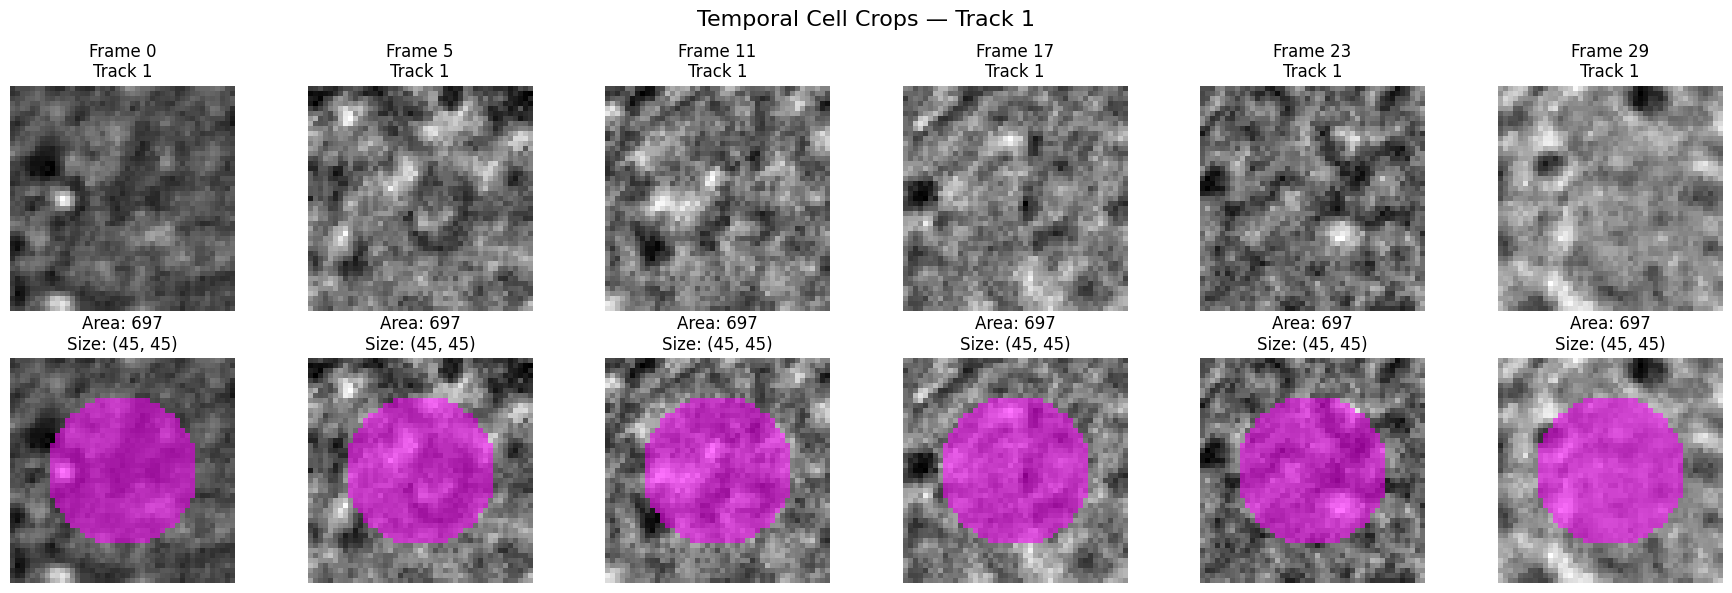

TRACK 1 TEMPORAL CROP CHECK
Frame  0 | Crop: (45, 45) | Area:  697 | Centroid: (154.0, 195.0)
Frame  5 | Crop: (45, 45) | Area:  697 | Centroid: (156.0, 197.0)
Frame 11 | Crop: (45, 45) | Area:  697 | Centroid: (156.0, 199.0)
Frame 17 | Crop: (45, 45) | Area:  697 | Centroid: (159.0, 201.0)
Frame 23 | Crop: (45, 45) | Area:  697 | Centroid: (159.0, 201.0)
Frame 29 | Crop: (45, 45) | Area:  697 | Centroid: (159.0, 201.0)

CELL 5 PASSED ✅


In [13]:
# ============================================================
# CELL 5 — VISUALIZE EXTRACTED CELL CROPS
# ============================================================

# Select Track 1
selected_track_id = 1

track_detections = detections_by_track[
    selected_track_id
]

# Select frames from different points in the track
sample_indices = np.linspace(
    0,
    len(track_detections) - 1,
    6,
    dtype=int
)


fig, axes = plt.subplots(
    2,
    6,
    figsize=(18, 6)
)


for column, detection_index in enumerate(
    sample_indices
):

    detection = track_detections[
        detection_index
    ]

    crop = detection["crop"]

    local_mask = detection["cell_mask"]


    # --------------------------------------------------------
    # ROW 1 — RAW CELL CROP
    # --------------------------------------------------------

    axes[0, column].imshow(
        crop,
        cmap="gray"
    )

    axes[0, column].set_title(
        f"Frame {detection['frame']}\n"
        f"Track {detection['track_id']}"
    )

    axes[0, column].axis("off")


    # --------------------------------------------------------
    # ROW 2 — CELL MASK OVER RAW CROP
    # --------------------------------------------------------

    axes[1, column].imshow(
        crop,
        cmap="gray"
    )

    masked_cell = np.ma.masked_where(
        local_mask == 0,
        local_mask
    )

    axes[1, column].imshow(
        masked_cell,
        cmap="spring",
        alpha=0.55
    )

    axes[1, column].set_title(
        f"Area: {detection['area']}\n"
        f"Size: {crop.shape}"
    )

    axes[1, column].axis("off")


plt.suptitle(
    f"Temporal Cell Crops — Track {selected_track_id}",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# PRINT TEMPORAL INFORMATION
# ============================================================

print("=" * 70)
print(
    f"TRACK {selected_track_id} "
    "TEMPORAL CROP CHECK"
)
print("=" * 70)

for detection_index in sample_indices:

    detection = track_detections[
        detection_index
    ]

    print(
        f"Frame {detection['frame']:2d}"
        f" | "
        f"Crop: {detection['crop'].shape}"
        f" | "
        f"Area: {detection['area']:4d}"
        f" | "
        f"Centroid: "
        f"({detection['centroid'][0]:.1f}, "
        f"{detection['centroid'][1]:.1f})"
    )


print("\nCELL 5 PASSED ✅")

In [14]:
# ============================================================
# CELL 6 — RESIZE, NORMALIZE, AND BUILD TRACK TENSORS
# ============================================================

from PIL import Image

TARGET_SIZE = (64, 64)

track_tensors = {}

for track_id in sorted(detections_by_track.keys()):

    sequence_tensors = []

    for detection in detections_by_track[track_id]:

        # ----------------------------------------------------
        # GET RAW CELL CROP
        # ----------------------------------------------------

        crop = detection["crop"]

        # ----------------------------------------------------
        # RESIZE TO 64 × 64
        # ----------------------------------------------------

        resized_crop = np.array(
            Image.fromarray(crop).resize(
                TARGET_SIZE,
                resample=Image.Resampling.BILINEAR
            ),
            dtype=np.float32
        )

        # ----------------------------------------------------
        # NORMALIZE TO [0, 1]
        # ----------------------------------------------------

        resized_crop = resized_crop / 255.0

        # ----------------------------------------------------
        # CONVERT TO PYTORCH TENSOR
        #
        # Before: [64, 64]
        # After : [1, 64, 64]
        # ----------------------------------------------------

        crop_tensor = torch.from_numpy(
            resized_crop
        ).unsqueeze(0)

        sequence_tensors.append(
            crop_tensor
        )

    # --------------------------------------------------------
    # STACK ALL TIME STEPS
    #
    # [T × (1, 64, 64)]
    #          ↓
    # [T, 1, 64, 64]
    # --------------------------------------------------------

    track_tensors[track_id] = torch.stack(
        sequence_tensors,
        dim=0
    )


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("TRACK-TENSOR SUMMARY")
print("=" * 70)

print(
    "Total track tensors:",
    len(track_tensors)
)

print("\nFirst 10 tracks:\n")

for track_id in sorted(
    track_tensors.keys()
)[:10]:

    tensor = track_tensors[
        track_id
    ]

    print(
        f"Track {track_id:2d}"
        f" → "
        f"{tuple(tensor.shape)}"
    )


# ============================================================
# CHECK TRACK 1
# ============================================================

sample = track_tensors[1]

print("\n" + "=" * 70)
print("TRACK 1 CHECK")
print("=" * 70)

print(
    "Shape :",
    sample.shape
)

print(
    "Dtype :",
    sample.dtype
)

print(
    "Minimum:",
    sample.min().item()
)

print(
    "Maximum:",
    sample.max().item()
)


# ============================================================
# VALIDATION
# ============================================================

assert len(track_tensors) == 38

assert (
    track_tensors[1].shape
    == torch.Size([30, 1, 64, 64])
)

assert (
    track_tensors[3].shape
    == torch.Size([54, 1, 64, 64])
)

assert (
    track_tensors[5].shape
    == torch.Size([69, 1, 64, 64])
)

for track_id, tensor in track_tensors.items():

    assert tensor.ndim == 4

    assert tensor.shape[1:] == (
        1,
        64,
        64
    )

    assert torch.isfinite(
        tensor
    ).all()

print(
    "\nAll 38 tracks were resized "
    "and converted successfully ✅"
)

print(
    "\nCELL 6 PASSED ✅"
)

TRACK-TENSOR SUMMARY
Total track tensors: 38

First 10 tracks:

Track  1 → (30, 1, 64, 64)
Track  3 → (54, 1, 64, 64)
Track  4 → (54, 1, 64, 64)
Track  5 → (69, 1, 64, 64)
Track  6 → (8, 1, 64, 64)
Track  7 → (36, 1, 64, 64)
Track  8 → (48, 1, 64, 64)
Track 10 → (48, 1, 64, 64)
Track 11 → (62, 1, 64, 64)
Track 12 → (22, 1, 64, 64)

TRACK 1 CHECK
Shape : torch.Size([30, 1, 64, 64])
Dtype : torch.float32
Minimum: 0.21176470816135406
Maximum: 0.8274509906768799

All 38 tracks were resized and converted successfully ✅

CELL 6 PASSED ✅


In [15]:
# ============================================================
# CELL 7 — CNN CELL APPEARANCE ENCODER
# ============================================================

import torch
import torch.nn as nn


class CellEncoder(nn.Module):

    def __init__(self, feature_dim=128):

        super().__init__()

        self.encoder = nn.Sequential(

            # ------------------------------------------------
            # BLOCK 1
            # [1, 64, 64]
            #       ↓
            # [32, 32, 32]
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(
                kernel_size=2
            ),


            # ------------------------------------------------
            # BLOCK 2
            # [32, 32, 32]
            #       ↓
            # [64, 16, 16]
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(
                kernel_size=2
            ),


            # ------------------------------------------------
            # BLOCK 3
            # [64, 16, 16]
            #       ↓
            # [128, 16, 16]
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=64,
                out_channels=feature_dim,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                feature_dim
            ),

            nn.ReLU(
                inplace=True
            ),


            # ------------------------------------------------
            # GLOBAL FEATURE
            # [128, 16, 16]
            #       ↓
            # [128, 1, 1]
            # ------------------------------------------------

            nn.AdaptiveAvgPool2d(
                output_size=(1, 1)
            )
        )


    def forward(self, x):

        # Input:
        # [N, 1, 64, 64]

        features = self.encoder(x)

        # [N, 128, 1, 1]
        #          ↓
        # [N, 128]

        features = features.flatten(
            start_dim=1
        )

        return features


# ============================================================
# CREATE CNN
# ============================================================

cnn_encoder = CellEncoder(
    feature_dim=128
).to(device)


print("=" * 70)
print("CNN CELL ENCODER")
print("=" * 70)

print(cnn_encoder)


# ============================================================
# TEST USING COMPLETE TRACK 1
# ============================================================

track_1 = track_tensors[1].to(
    device
)

print("\n" + "=" * 70)
print("CNN FORWARD-PASS TEST")
print("=" * 70)

print(
    "CNN Input :",
    track_1.shape
)


cnn_encoder.eval()

with torch.no_grad():

    track_1_features = cnn_encoder(
        track_1
    )


print(
    "CNN Output:",
    track_1_features.shape
)

print(
    "Device    :",
    track_1_features.device
)

print(
    "Finite    :",
    torch.isfinite(
        track_1_features
    ).all().item()
)


# ============================================================
# VALIDATION
# ============================================================

assert (
    track_1_features.shape
    == torch.Size([30, 128])
)

assert torch.isfinite(
    track_1_features
).all()


print(
    "\nCNN ENCODER TEST PASSED ✅"
)

print(
    "\nCELL 7 PASSED ✅"
)

CNN CELL ENCODER
CellEncoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
)

CNN FORWARD-PASS TEST
CNN Input : torch.Size([30, 1, 64, 64])
CNN Output: torch.Size([30, 128])
Device    : cuda:0
Finite    : True

CNN ENCODER

In [16]:
# ============================================================
# CELL 8 — OFFICIAL MAMBA TEMPORAL BACKBONE TEST
# ============================================================

import torch
from mamba_ssm import Mamba


# ============================================================
# CREATE OFFICIAL MAMBA
# ============================================================

temporal_mamba = Mamba(
    d_model=128,   # CNN feature dimension
    d_state=16,    # Internal SSM state size
    d_conv=4,      # Local temporal convolution
    expand=2       # Internal expansion factor
).to(device)


print("=" * 70)
print("OFFICIAL TEMPORAL MAMBA")
print("=" * 70)

print(temporal_mamba)


# ============================================================
# PREPARE TRACK 1 FEATURES
# ============================================================

# Current CNN output:
# [30, 128]
#
# Mamba expects:
# [Batch, Time, Feature]
#
# Add batch dimension:
# [1, 30, 128]

mamba_input = track_1_features.unsqueeze(0)


print("\n" + "=" * 70)
print("MAMBA FORWARD-PASS TEST")
print("=" * 70)

print(
    "Mamba Input :",
    mamba_input.shape
)


# ============================================================
# FORWARD PASS
# ============================================================

temporal_mamba.eval()

with torch.no_grad():

    temporal_features = temporal_mamba(
        mamba_input
    )


print(
    "Mamba Output:",
    temporal_features.shape
)

print(
    "Device      :",
    temporal_features.device
)

print(
    "Finite      :",
    torch.isfinite(
        temporal_features
    ).all().item()
)


# ============================================================
# VERIFY THAT TEMPORAL OUTPUT IS VALID
# ============================================================

assert (
    temporal_features.shape
    == torch.Size([1, 30, 128])
)

assert torch.isfinite(
    temporal_features
).all()


print(
    "\nOFFICIAL MAMBA FORWARD PASS PASSED ✅"
)

print(
    "\nCELL 8 PASSED ✅"
)

OFFICIAL TEMPORAL MAMBA
Mamba(
  (in_proj): Linear(in_features=128, out_features=512, bias=False)
  (conv1d): Conv1d(256, 256, kernel_size=(4,), stride=(1,), padding=(3,), groups=256)
  (act): SiLU()
  (x_proj): Linear(in_features=256, out_features=40, bias=False)
  (dt_proj): Linear(in_features=8, out_features=256, bias=True)
  (out_proj): Linear(in_features=256, out_features=128, bias=False)
)

MAMBA FORWARD-PASS TEST
Mamba Input : torch.Size([1, 30, 128])
Mamba Output: torch.Size([1, 30, 128])
Device      : cuda:0
Finite      : True

OFFICIAL MAMBA FORWARD PASS PASSED ✅

CELL 8 PASSED ✅


In [17]:
# ============================================================
# CELL 9 — COMPLETE TEMPORAL CELL MAMBA MODEL
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from mamba_ssm import Mamba


class TemporalCellMamba(nn.Module):

    def __init__(
        self,
        feature_dim=128,
        embedding_dim=64
    ):
        super().__init__()


        # ====================================================
        # 1. CNN APPEARANCE ENCODER
        # ====================================================

        self.cell_encoder = CellEncoder(
            feature_dim=feature_dim
        )


        # ====================================================
        # 2. OFFICIAL MAMBA TEMPORAL BACKBONE
        # ====================================================

        self.temporal_mamba = Mamba(

            d_model=feature_dim,

            d_state=16,

            d_conv=4,

            expand=2
        )


        # ====================================================
        # 3. TRACKING EMBEDDING HEAD
        # ====================================================

        self.embedding_head = nn.Sequential(

            nn.Linear(
                feature_dim,
                feature_dim
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                feature_dim,
                embedding_dim
            )
        )


    def forward(self, x):

        # ====================================================
        # INPUT
        #
        # x:
        # [Batch, Time, Channel, Height, Width]
        #
        # Example:
        # [1, 30, 1, 64, 64]
        # ====================================================

        B, T, C, H, W = x.shape


        # ====================================================
        # CNN ENCODING
        # ====================================================

        # Combine batch and time:
        #
        # [B, T, C, H, W]
        #          ↓
        # [B × T, C, H, W]

        x = x.reshape(
            B * T,
            C,
            H,
            W
        )


        # CNN output:
        #
        # [B × T, 128]

        appearance_features = self.cell_encoder(
            x
        )


        # Restore temporal structure:
        #
        # [B × T, 128]
        #        ↓
        # [B, T, 128]

        appearance_features = (
            appearance_features.reshape(
                B,
                T,
                -1
            )
        )


        # ====================================================
        # OFFICIAL MAMBA TEMPORAL MODELING
        # ====================================================

        # Input:
        # [B, T, 128]
        #
        # Output:
        # [B, T, 128]

        temporal_features = (
            self.temporal_mamba(
                appearance_features
            )
        )


        # ====================================================
        # TRACKING EMBEDDING
        # ====================================================

        # [B, T, 128]
        #       ↓
        # [B, T, 64]

        embeddings = self.embedding_head(
            temporal_features
        )


        # ====================================================
        # L2 NORMALIZATION
        # ====================================================

        # Makes cosine similarity suitable for matching.

        embeddings = F.normalize(

            embeddings,

            p=2,

            dim=-1
        )


        return embeddings


# ============================================================
# CREATE COMPLETE MODEL
# ============================================================

model = TemporalCellMamba(

    feature_dim=128,

    embedding_dim=64

).to(device)


print("=" * 70)
print("COMPLETE TEMPORAL CELL MAMBA MODEL")
print("=" * 70)

print(model)


# ============================================================
# PARAMETER COUNT
# ============================================================

total_parameters = sum(

    parameter.numel()

    for parameter in model.parameters()
)


trainable_parameters = sum(

    parameter.numel()

    for parameter in model.parameters()

    if parameter.requires_grad
)


print(
    "\nTotal Parameters    :",
    f"{total_parameters:,}"
)

print(
    "Trainable Parameters:",
    f"{trainable_parameters:,}"
)

COMPLETE TEMPORAL CELL MAMBA MODEL
TemporalCellMamba(
  (cell_encoder): CellEncoder(
    (encoder): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU(inplace=True)
      (11): AdaptiveAvgPool2d(output_size=(1, 1))
    )
  )
  (temporal_mamba): Mamba(
    (in_proj): Linear(in_features

In [18]:
# ============================================================
# CELL 9B — TEST COMPLETE CNN → MAMBA → EMBEDDING MODEL
# ============================================================

# Track 1:
# Original shape = [30, 1, 64, 64]

track_1_input = (
    track_tensors[1]
    .unsqueeze(0)       # Add batch dimension
    .to(device)
)

# New shape:
# [1, 30, 1, 64, 64]


print("=" * 70)
print("COMPLETE MODEL FORWARD TEST")
print("=" * 70)

print(
    "Model Input :",
    track_1_input.shape
)


# ------------------------------------------------------------
# EVALUATION MODE
# ------------------------------------------------------------

model.eval()


# ------------------------------------------------------------
# COMPLETE FORWARD PASS
#
# Cell crops
#     ↓
# CNN
#     ↓
# Official Mamba
#     ↓
# Embedding Head
# ------------------------------------------------------------

with torch.no_grad():

    track_1_embeddings = model(
        track_1_input
    )


# ------------------------------------------------------------
# PRINT OUTPUT
# ------------------------------------------------------------

print(
    "Model Output:",
    track_1_embeddings.shape
)

print(
    "Device      :",
    track_1_embeddings.device
)

print(
    "Finite      :",
    torch.isfinite(
        track_1_embeddings
    ).all().item()
)


# ------------------------------------------------------------
# CHECK EMBEDDING NORMALIZATION
# ------------------------------------------------------------

embedding_norms = torch.linalg.vector_norm(

    track_1_embeddings,

    ord=2,

    dim=-1
)


print(
    "Mean embedding norm:",
    embedding_norms.mean().item()
)

print(
    "Minimum norm       :",
    embedding_norms.min().item()
)

print(
    "Maximum norm       :",
    embedding_norms.max().item()
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

assert (
    track_1_embeddings.shape
    == torch.Size([1, 30, 64])
), (
    "Unexpected model-output shape."
)


assert torch.isfinite(
    track_1_embeddings
).all(), (
    "Model output contains NaN or infinity."
)


assert torch.allclose(

    embedding_norms,

    torch.ones_like(
        embedding_norms
    ),

    atol=1e-4

), (
    "Tracking embeddings are not L2 normalized."
)


print(
    "\nCNN → OFFICIAL MAMBA → "
    "EMBEDDING HEAD PASSED ✅"
)

print(
    "\nCELL 9 PASSED ✅"
)

COMPLETE MODEL FORWARD TEST
Model Input : torch.Size([1, 30, 1, 64, 64])
Model Output: torch.Size([1, 30, 64])
Device      : cuda:0
Finite      : True
Mean embedding norm: 1.0
Minimum norm       : 0.9999999403953552
Maximum norm       : 1.0

CNN → OFFICIAL MAMBA → EMBEDDING HEAD PASSED ✅

CELL 9 PASSED ✅


In [20]:
# ============================================================
# CELL 10 — TEMPORAL WINDOW DATASET
# ============================================================

import random

from torch.utils.data import (
    Dataset,
    DataLoader
)


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

WINDOW_SIZE = 8

WINDOW_STRIDE = 1


# ============================================================
# DATASET
# ============================================================

class TemporalWindowDataset(Dataset):

    def __init__(
        self,
        track_tensors,
        window_size=8,
        stride=1
    ):

        self.track_tensors = track_tensors

        self.window_size = window_size

        self.stride = stride

        self.samples = []


        # ----------------------------------------------------
        # CREATE TEMPORAL WINDOWS
        # ----------------------------------------------------

        for track_id in sorted(
            track_tensors.keys()
        ):

            sequence = track_tensors[
                track_id
            ]

            track_length = sequence.shape[0]


            # Skip tracks shorter than window size

            if track_length < window_size:

                continue


            # Create overlapping windows

            for start in range(

                0,

                track_length
                - window_size
                + 1,

                stride

            ):

                end = (
                    start
                    + window_size
                )


                self.samples.append({

                    "track_id":
                    int(track_id),

                    "start":
                    int(start),

                    "end":
                    int(end)

                })


    def __len__(self):

        return len(
            self.samples
        )


    def __getitem__(
        self,
        index
    ):

        information = self.samples[
            index
        ]


        track_id = information[
            "track_id"
        ]


        start = information[
            "start"
        ]


        end = information[
            "end"
        ]


        # Shape:
        # [8, 1, 64, 64]

        temporal_window = (

            self.track_tensors[
                track_id
            ][
                start:end
            ]

        )


        return {

            "sequence":
            temporal_window,

            "track_id":
            torch.tensor(
                track_id,
                dtype=torch.long
            ),

            "start":
            torch.tensor(
                start,
                dtype=torch.long
            )

        }


# ============================================================
# CREATE DATASET
# ============================================================

training_dataset = TemporalWindowDataset(

    track_tensors=track_tensors,

    window_size=WINDOW_SIZE,

    stride=WINDOW_STRIDE

)


# ============================================================
# PRINT SUMMARY
# ============================================================

print("=" * 70)

print(
    "TEMPORAL WINDOW DATASET"
)

print("=" * 70)


print(
    "Window size       :",
    WINDOW_SIZE
)


print(
    "Window stride     :",
    WINDOW_STRIDE
)


print(
    "Training samples  :",
    len(training_dataset)
)


# ------------------------------------------------------------
# INSPECT FIRST SAMPLE
# ------------------------------------------------------------

sample = training_dataset[0]


print(
    "\nFirst sample shape:",
    sample["sequence"].shape
)


print(
    "Track ID          :",
    sample["track_id"].item()
)


print(
    "Window start      :",
    sample["start"].item()
)


# ============================================================
# VALIDATION
# ============================================================

assert (

    sample["sequence"].shape

    ==

    torch.Size(
        [
            WINDOW_SIZE,
            1,
            64,
            64
        ]
    )

)


assert (

    len(training_dataset)

    > 0

)


print(
    "\nTEMPORAL WINDOW "
    "DATASET PASSED ✅"
)

print(
    "\nCELL 10 PASSED ✅"
)

TEMPORAL WINDOW DATASET
Window size       : 8
Window stride     : 1
Training samples  : 894

First sample shape: torch.Size([8, 1, 64, 64])
Track ID          : 1
Window start      : 0

TEMPORAL WINDOW DATASET PASSED ✅

CELL 10 PASSED ✅


In [21]:
# ============================================================
# CELL 11 — TRACK-WISE TRAIN/VALIDATION SPLIT
# ============================================================

import random
import torch

from torch.utils.data import (
    Dataset,
    DataLoader
)


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


# ============================================================
# SPLIT COMPLETE TRACK IDs
# ============================================================

all_track_ids = sorted(
    track_tensors.keys()
)

shuffled_track_ids = (
    all_track_ids.copy()
)

random.shuffle(
    shuffled_track_ids
)


split_index = int(
    0.80
    * len(shuffled_track_ids)
)


train_track_ids = sorted(
    shuffled_track_ids[
        :split_index
    ]
)


validation_track_ids = sorted(
    shuffled_track_ids[
        split_index:
    ]
)


print("=" * 70)

print(
    "TRACK-WISE TRAIN/VALIDATION SPLIT"
)

print("=" * 70)


print(
    "Total tracks      :",
    len(all_track_ids)
)


print(
    "Training tracks   :",
    len(train_track_ids)
)


print(
    "Validation tracks :",
    len(validation_track_ids)
)


print(
    "\nTraining Track IDs:"
)

print(
    train_track_ids
)


print(
    "\nValidation Track IDs:"
)

print(
    validation_track_ids
)


# ============================================================
# DATASET USING ONLY SELECTED TRACK IDs
# ============================================================

class TrackSplitWindowDataset(Dataset):

    def __init__(
        self,
        track_tensors,
        selected_track_ids,
        window_size=8,
        stride=1
    ):

        self.track_tensors = (
            track_tensors
        )

        self.window_size = (
            window_size
        )

        self.samples = []


        for track_id in sorted(
            selected_track_ids
        ):

            sequence = (
                track_tensors[
                    track_id
                ]
            )


            track_length = (
                sequence.shape[0]
            )


            # Ignore tracks shorter
            # than the temporal window

            if (
                track_length
                < window_size
            ):

                continue


            for start in range(

                0,

                track_length
                - window_size
                + 1,

                stride

            ):

                end = (
                    start
                    + window_size
                )


                self.samples.append({

                    "track_id":
                    int(track_id),

                    "start":
                    int(start),

                    "end":
                    int(end)

                })


    def __len__(self):

        return len(
            self.samples
        )


    def __getitem__(
        self,
        index
    ):

        information = (
            self.samples[
                index
            ]
        )


        track_id = (
            information[
                "track_id"
            ]
        )


        start = (
            information[
                "start"
            ]
        )


        end = (
            information[
                "end"
            ]
        )


        sequence = (

            self.track_tensors[
                track_id
            ][
                start:end
            ]

        )


        return {

            "sequence":
            sequence,

            "track_id":
            torch.tensor(
                track_id,
                dtype=torch.long
            ),

            "start":
            torch.tensor(
                start,
                dtype=torch.long
            )

        }


# ============================================================
# CREATE TRAIN AND VALIDATION DATASETS
# ============================================================

train_dataset = (
    TrackSplitWindowDataset(

        track_tensors=
        track_tensors,

        selected_track_ids=
        train_track_ids,

        window_size=
        WINDOW_SIZE,

        stride=
        WINDOW_STRIDE
    )
)


validation_dataset = (
    TrackSplitWindowDataset(

        track_tensors=
        track_tensors,

        selected_track_ids=
        validation_track_ids,

        window_size=
        WINDOW_SIZE,

        stride=
        WINDOW_STRIDE
    )
)


# ============================================================
# CREATE DATALOADERS
# ============================================================

BATCH_SIZE = 8


train_loader = DataLoader(

    train_dataset,

    batch_size=
    BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True,

    drop_last=True
)


validation_loader = DataLoader(

    validation_dataset,

    batch_size=
    BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    drop_last=False
)


# ============================================================
# SUMMARY
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "DATALOADER SUMMARY"
)

print("=" * 70)


print(
    "Training windows   :",
    len(train_dataset)
)


print(
    "Validation windows :",
    len(validation_dataset)
)


print(
    "Training batches   :",
    len(train_loader)
)


print(
    "Validation batches :",
    len(validation_loader)
)


# ============================================================
# TEST ONE TRAINING BATCH
# ============================================================

batch = next(
    iter(train_loader)
)


print(
    "\nSequence batch shape:",
    batch[
        "sequence"
    ].shape
)


print(
    "Track-ID batch shape:",
    batch[
        "track_id"
    ].shape
)


print(
    "Example Track IDs  :",
    batch[
        "track_id"
    ].tolist()
)


# ============================================================
# VALIDATION
# ============================================================

assert set(
    train_track_ids
).isdisjoint(
    set(
        validation_track_ids
    )
)


assert (

    batch[
        "sequence"
    ].shape[1:]

    ==

    torch.Size(
        [
            8,
            1,
            64,
            64
        ]
    )

)


print(
    "\nNo Track-ID leakage "
    "between train and validation ✅"
)


print(
    "\nCELL 11 PASSED ✅"
)

TRACK-WISE TRAIN/VALIDATION SPLIT
Total tracks      : 38
Training tracks   : 30
Validation tracks : 8

Training Track IDs:
[1, 4, 5, 6, 7, 12, 14, 15, 16, 18, 22, 24, 26, 27, 30, 32, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 52, 54, 55, 56]

Validation Track IDs:
[3, 8, 10, 11, 19, 21, 23, 28]

DATALOADER SUMMARY
Training windows   : 564
Validation windows : 330
Training batches   : 70
Validation batches : 42

Sequence batch shape: torch.Size([8, 8, 1, 64, 64])
Track-ID batch shape: torch.Size([8])
Example Track IDs  : [5, 4, 18, 16, 5, 34, 24, 32]

No Track-ID leakage between train and validation ✅

CELL 11 PASSED ✅


In [22]:
# ============================================================
# CELL 12 — TEMPORAL TRIPLET DATASET
# ============================================================

import random

from torch.utils.data import (
    Dataset,
    DataLoader
)


class TemporalTripletDataset(Dataset):

    def __init__(
        self,
        track_tensors,
        selected_track_ids,
        window_size=8,
        samples_per_epoch=1000
    ):

        self.track_tensors = track_tensors

        self.window_size = window_size

        self.samples_per_epoch = samples_per_epoch


        # Keep only tracks that can produce
        # at least one complete temporal window

        self.valid_track_ids = [

            track_id

            for track_id
            in selected_track_ids

            if (
                track_tensors[
                    track_id
                ].shape[0]

                >= window_size
            )
        ]


        assert (
            len(self.valid_track_ids)
            >= 2
        )


    def __len__(self):

        return self.samples_per_epoch


    def get_random_window(
        self,
        track_id
    ):

        sequence = self.track_tensors[
            track_id
        ]


        track_length = sequence.shape[0]


        maximum_start = (

            track_length

            - self.window_size

        )


        start = random.randint(

            0,

            maximum_start

        )


        end = (

            start

            + self.window_size

        )


        return (

            sequence[
                start:end
            ],

            start

        )


    def __getitem__(
        self,
        index
    ):

        # ----------------------------------------------------
        # SELECT ANCHOR TRACK
        # ----------------------------------------------------

        anchor_track_id = random.choice(

            self.valid_track_ids

        )


        # ----------------------------------------------------
        # SELECT A DIFFERENT NEGATIVE TRACK
        # ----------------------------------------------------

        negative_candidates = [

            track_id

            for track_id
            in self.valid_track_ids

            if (
                track_id

                !=

                anchor_track_id
            )
        ]


        negative_track_id = random.choice(

            negative_candidates

        )


        # ----------------------------------------------------
        # ANCHOR WINDOW
        # ----------------------------------------------------

        anchor, anchor_start = (

            self.get_random_window(

                anchor_track_id

            )

        )


        # ----------------------------------------------------
        # POSITIVE WINDOW
        #
        # Same biological Track ID
        # ----------------------------------------------------

        positive, positive_start = (

            self.get_random_window(

                anchor_track_id

            )

        )


        # ----------------------------------------------------
        # NEGATIVE WINDOW
        #
        # Different biological Track ID
        # ----------------------------------------------------

        negative, negative_start = (

            self.get_random_window(

                negative_track_id

            )

        )


        return {

            "anchor":
            anchor,

            "positive":
            positive,

            "negative":
            negative,

            "anchor_track_id":
            torch.tensor(

                anchor_track_id,

                dtype=torch.long

            ),

            "negative_track_id":
            torch.tensor(

                negative_track_id,

                dtype=torch.long

            ),

            "anchor_start":
            torch.tensor(

                anchor_start,

                dtype=torch.long

            ),

            "positive_start":
            torch.tensor(

                positive_start,

                dtype=torch.long

            )

        }


# ============================================================
# CREATE TRAINING TRIPLET DATASET
# ============================================================

triplet_train_dataset = (

    TemporalTripletDataset(

        track_tensors=
        track_tensors,

        selected_track_ids=
        train_track_ids,

        window_size=
        WINDOW_SIZE,

        samples_per_epoch=
        1000

    )

)


# ============================================================
# CREATE TRIPLET DATALOADER
# ============================================================

TRIPLET_BATCH_SIZE = 8


triplet_train_loader = DataLoader(

    triplet_train_dataset,

    batch_size=
    TRIPLET_BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True,

    drop_last=True

)


# ============================================================
# TEST ONE BATCH
# ============================================================

triplet_batch = next(

    iter(
        triplet_train_loader
    )

)


print("=" * 70)

print(
    "TEMPORAL TRIPLET DATASET"
)

print("=" * 70)


print(

    "Anchor shape   :",

    triplet_batch[
        "anchor"
    ].shape

)


print(

    "Positive shape :",

    triplet_batch[
        "positive"
    ].shape

)


print(

    "Negative shape :",

    triplet_batch[
        "negative"
    ].shape

)


print(

    "\nAnchor Track IDs:",

    triplet_batch[
        "anchor_track_id"
    ].tolist()

)


print(

    "Negative IDs    :",

    triplet_batch[
        "negative_track_id"
    ].tolist()

)


# ============================================================
# VALIDATION
# ============================================================

assert (

    triplet_batch[
        "anchor"
    ].shape

    ==

    torch.Size(
        [
            8,
            8,
            1,
            64,
            64
        ]
    )

)


assert torch.all(

    triplet_batch[
        "anchor_track_id"
    ]

    !=

    triplet_batch[
        "negative_track_id"
    ]

)


print(

    "\nEvery positive comes from "
    "the anchor Track ID ✅"

)


print(

    "Every negative comes from "
    "a different Track ID ✅"

)


print(

    "\nCELL 12 PASSED ✅"

)

TEMPORAL TRIPLET DATASET
Anchor shape   : torch.Size([8, 8, 1, 64, 64])
Positive shape : torch.Size([8, 8, 1, 64, 64])
Negative shape : torch.Size([8, 8, 1, 64, 64])

Anchor Track IDs: [30, 30, 30, 5, 32, 56, 34, 39]
Negative IDs    : [39, 6, 22, 27, 6, 14, 54, 34]

Every positive comes from the anchor Track ID ✅
Every negative comes from a different Track ID ✅

CELL 12 PASSED ✅


In [23]:
# ============================================================
# CELL 13 — TRAIN CNN + OFFICIAL MAMBA WITH TRIPLET LOSS
# ============================================================

import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# TRAINING SETTINGS
# ============================================================

EPOCHS = 20

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-5

TRIPLET_MARGIN = 0.30

CHECKPOINT_PATH = (
    "/kaggle/working/"
    "best_temporal_cell_mamba.pt"
)


# ============================================================
# LOSS AND OPTIMIZER
# ============================================================

criterion = nn.TripletMarginLoss(
    margin=TRIPLET_MARGIN,
    p=2,
    reduction="mean"
)


optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY

)


# Reduce learning rate if loss stops improving

scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=0.5,

        patience=3

    )
)


# ============================================================
# CONVERT TEMPORAL OUTPUT INTO ONE WINDOW EMBEDDING
# ============================================================

def get_window_embedding(
    model,
    sequence
):

    # sequence:
    # [B, 8, 1, 64, 64]

    # Model output:
    # [B, 8, 64]

    temporal_embeddings = model(
        sequence
    )


    # Mean pooling over time:
    #
    # [B, 8, 64]
    #       ↓
    # [B, 64]

    window_embedding = (
        temporal_embeddings.mean(
            dim=1
        )
    )


    # Normalize again after temporal pooling

    window_embedding = F.normalize(

        window_embedding,

        p=2,

        dim=-1

    )


    return window_embedding


# ============================================================
# TRAINING
# ============================================================

best_loss = float("inf")

training_history = []


print("=" * 70)

print(
    "TRAINING TEMPORAL CELL MAMBA"
)

print("=" * 70)


print(
    "Epochs          :",
    EPOCHS
)

print(
    "Learning rate   :",
    LEARNING_RATE
)

print(
    "Triplet margin  :",
    TRIPLET_MARGIN
)

print(
    "Batches/epoch   :",
    len(triplet_train_loader)
)

print(
    "Checkpoint      :",
    CHECKPOINT_PATH
)

print("=" * 70)


training_start = time.time()


for epoch in range(
    1,
    EPOCHS + 1
):

    model.train()

    running_loss = 0.0

    positive_distance_sum = 0.0

    negative_distance_sum = 0.0


    epoch_start = time.time()


    for batch in triplet_train_loader:


        # ====================================================
        # MOVE DATA TO T4
        # ====================================================

        anchor = (

            batch["anchor"]

            .to(
                device,
                non_blocking=True
            )

        )


        positive = (

            batch["positive"]

            .to(
                device,
                non_blocking=True
            )

        )


        negative = (

            batch["negative"]

            .to(
                device,
                non_blocking=True
            )

        )


        # ====================================================
        # CLEAR OLD GRADIENTS
        # ====================================================

        optimizer.zero_grad(
            set_to_none=True
        )


        # ====================================================
        # FORWARD PASSES
        # ====================================================

        anchor_embedding = (
            get_window_embedding(

                model,

                anchor

            )
        )


        positive_embedding = (
            get_window_embedding(

                model,

                positive

            )
        )


        negative_embedding = (
            get_window_embedding(

                model,

                negative

            )
        )


        # ====================================================
        # TRIPLET LOSS
        # ====================================================

        loss = criterion(

            anchor_embedding,

            positive_embedding,

            negative_embedding

        )


        # ====================================================
        # BACKPROPAGATION
        # ====================================================

        loss.backward()


        # Prevent unstable gradients

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=1.0

        )


        optimizer.step()


        # ====================================================
        # DISTANCE STATISTICS
        # ====================================================

        with torch.no_grad():


            positive_distance = (

                F.pairwise_distance(

                    anchor_embedding,

                    positive_embedding

                ).mean()

            )


            negative_distance = (

                F.pairwise_distance(

                    anchor_embedding,

                    negative_embedding

                ).mean()

            )


        running_loss += (
            loss.item()
        )


        positive_distance_sum += (
            positive_distance.item()
        )


        negative_distance_sum += (
            negative_distance.item()
        )


    # ========================================================
    # EPOCH STATISTICS
    # ========================================================

    average_loss = (

        running_loss

        /

        len(
            triplet_train_loader
        )

    )


    average_positive_distance = (

        positive_distance_sum

        /

        len(
            triplet_train_loader
        )

    )


    average_negative_distance = (

        negative_distance_sum

        /

        len(
            triplet_train_loader
        )

    )


    scheduler.step(
        average_loss
    )


    current_learning_rate = (

        optimizer.param_groups[0][
            "lr"
        ]

    )


    epoch_time = (

        time.time()

        - epoch_start

    )


    training_history.append({

        "epoch":
        epoch,

        "loss":
        average_loss,

        "positive_distance":
        average_positive_distance,

        "negative_distance":
        average_negative_distance

    })


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    saved = ""


    if average_loss < best_loss:


        best_loss = average_loss


        torch.save(

            {

                "epoch":
                epoch,

                "model_state_dict":
                model.state_dict(),

                "optimizer_state_dict":
                optimizer.state_dict(),

                "loss":
                best_loss,

                "feature_dim":
                128,

                "embedding_dim":
                64,

                "window_size":
                WINDOW_SIZE

            },

            CHECKPOINT_PATH

        )


        saved = " ← BEST MODEL SAVED ✅"


    # ========================================================
    # PRINT EPOCH
    # ========================================================

    print(

        f"Epoch "
        f"{epoch:02d}/{EPOCHS}"

        f" | Loss: "
        f"{average_loss:.6f}"

        f" | Positive: "
        f"{average_positive_distance:.4f}"

        f" | Negative: "
        f"{average_negative_distance:.4f}"

        f" | LR: "
        f"{current_learning_rate:.2e}"

        f" | Time: "
        f"{epoch_time:.1f}s"

        f"{saved}"

    )


# ============================================================
# TRAINING COMPLETE
# ============================================================

total_training_time = (

    time.time()

    - training_start

)


print("\n" + "=" * 70)

print(
    "TRAINING COMPLETED ✅"
)

print("=" * 70)


print(

    "Best training loss:",

    f"{best_loss:.6f}"

)


print(

    "Total time:",

    f"{total_training_time / 60:.2f}",

    "minutes"

)


print(

    "Checkpoint exists:",

    os.path.exists(
        CHECKPOINT_PATH
    )

)


print(

    "Checkpoint path:",

    CHECKPOINT_PATH

)

TRAINING TEMPORAL CELL MAMBA
Epochs          : 20
Learning rate   : 0.0001
Triplet margin  : 0.3
Batches/epoch   : 125
Checkpoint      : /kaggle/working/best_temporal_cell_mamba.pt
Epoch 01/20 | Loss: 0.130246 | Positive: 0.1555 | Negative: 0.5169 | LR: 1.00e-04 | Time: 5.0s ← BEST MODEL SAVED ✅
Epoch 02/20 | Loss: 0.060014 | Positive: 0.2689 | Negative: 0.9747 | LR: 1.00e-04 | Time: 4.3s ← BEST MODEL SAVED ✅
Epoch 03/20 | Loss: 0.053545 | Positive: 0.2625 | Negative: 1.0236 | LR: 1.00e-04 | Time: 4.3s ← BEST MODEL SAVED ✅
Epoch 04/20 | Loss: 0.041437 | Positive: 0.2836 | Negative: 1.0400 | LR: 1.00e-04 | Time: 4.3s ← BEST MODEL SAVED ✅
Epoch 05/20 | Loss: 0.039538 | Positive: 0.3013 | Negative: 1.0747 | LR: 1.00e-04 | Time: 4.4s ← BEST MODEL SAVED ✅
Epoch 06/20 | Loss: 0.039344 | Positive: 0.2811 | Negative: 1.0422 | LR: 1.00e-04 | Time: 4.3s ← BEST MODEL SAVED ✅
Epoch 07/20 | Loss: 0.025817 | Positive: 0.2753 | Negative: 1.1402 | LR: 1.00e-04 | Time: 4.3s ← BEST MODEL SAVED ✅
Epoch 0

In [24]:
# ============================================================
# CELL 14 — LOAD BEST TRAINED CHECKPOINT
# ============================================================

import os
import torch

CHECKPOINT_PATH = (
    "/kaggle/working/"
    "best_temporal_cell_mamba.pt"
)

assert os.path.exists(
    CHECKPOINT_PATH
), "Checkpoint file was not found."


# ------------------------------------------------------------
# LOAD CHECKPOINT
# ------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)


# ------------------------------------------------------------
# RESTORE BEST MODEL WEIGHTS
# ------------------------------------------------------------

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)

model.eval()


# ------------------------------------------------------------
# PRINT INFORMATION
# ------------------------------------------------------------

print("=" * 70)
print("BEST TEMPORAL CELL MAMBA CHECKPOINT")
print("=" * 70)

print(
    "Best epoch        :",
    checkpoint["epoch"]
)

print(
    "Best training loss:",
    checkpoint["loss"]
)

print(
    "Feature dimension :",
    checkpoint["feature_dim"]
)

print(
    "Embedding dimension:",
    checkpoint["embedding_dim"]
)

print(
    "Window size       :",
    checkpoint["window_size"]
)

print(
    "Model device      :",
    next(
        model.parameters()
    ).device
)


print(
    "\nBEST MODEL LOADED SUCCESSFULLY ✅"
)

print(
    "\nCELL 14 PASSED ✅"
)

BEST TEMPORAL CELL MAMBA CHECKPOINT
Best epoch        : 18
Best training loss: 0.015478049993515014
Feature dimension : 128
Embedding dimension: 64
Window size       : 8
Model device      : cuda:0

BEST MODEL LOADED SUCCESSFULLY ✅

CELL 14 PASSED ✅


In [25]:
# ============================================================
# CELL 15 — EVALUATE UNSEEN VALIDATION TRACKS
# ============================================================

import random
import numpy as np
import torch
import torch.nn.functional as F


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

NUM_EVALUATION_TRIPLETS = 500

random.seed(123)

np.random.seed(123)

torch.manual_seed(123)


# ------------------------------------------------------------
# VALIDATION TRACKS LONG ENOUGH FOR 8-FRAME WINDOWS
# ------------------------------------------------------------

valid_validation_tracks = [

    track_id

    for track_id in validation_track_ids

    if track_tensors[track_id].shape[0] >= WINDOW_SIZE

]


print("=" * 70)
print("UNSEEN-TRACK VALIDATION")
print("=" * 70)

print(
    "Validation Track IDs:",
    valid_validation_tracks
)

print(
    "Evaluation triplets :",
    NUM_EVALUATION_TRIPLETS
)


# ------------------------------------------------------------
# RANDOM TEMPORAL WINDOW
# ------------------------------------------------------------

def sample_window(
    track_id,
    window_size=WINDOW_SIZE
):

    sequence = track_tensors[
        track_id
    ]

    maximum_start = (

        sequence.shape[0]

        - window_size

    )

    start = random.randint(

        0,

        maximum_start

    )

    window = sequence[

        start:

        start + window_size

    ]

    return window


# ------------------------------------------------------------
# EVALUATION STORAGE
# ------------------------------------------------------------

positive_distances = []

negative_distances = []

correct_triplets = 0


# ------------------------------------------------------------
# EVALUATION MODE
# ------------------------------------------------------------

model.eval()


with torch.no_grad():

    for _ in range(
        NUM_EVALUATION_TRIPLETS
    ):


        # ====================================================
        # SELECT ANCHOR TRACK
        # ====================================================

        anchor_track_id = random.choice(

            valid_validation_tracks

        )


        # ====================================================
        # SELECT DIFFERENT NEGATIVE TRACK
        # ====================================================

        negative_candidates = [

            track_id

            for track_id
            in valid_validation_tracks

            if track_id != anchor_track_id

        ]


        negative_track_id = random.choice(

            negative_candidates

        )


        # ====================================================
        # CREATE WINDOWS
        # ====================================================

        anchor = sample_window(

            anchor_track_id

        ).unsqueeze(0).to(device)


        positive = sample_window(

            anchor_track_id

        ).unsqueeze(0).to(device)


        negative = sample_window(

            negative_track_id

        ).unsqueeze(0).to(device)


        # ====================================================
        # GET TRAINED TEMPORAL EMBEDDINGS
        # ====================================================

        anchor_embedding = (

            get_window_embedding(

                model,

                anchor

            )

        )


        positive_embedding = (

            get_window_embedding(

                model,

                positive

            )

        )


        negative_embedding = (

            get_window_embedding(

                model,

                negative

            )

        )


        # ====================================================
        # CALCULATE DISTANCES
        # ====================================================

        positive_distance = (

            F.pairwise_distance(

                anchor_embedding,

                positive_embedding

            ).item()

        )


        negative_distance = (

            F.pairwise_distance(

                anchor_embedding,

                negative_embedding

            ).item()

        )


        positive_distances.append(

            positive_distance

        )


        negative_distances.append(

            negative_distance

        )


        # Correct if same-track window
        # is closer than different-track window

        if (

            positive_distance

            <

            negative_distance

        ):

            correct_triplets += 1


# ============================================================
# RESULTS
# ============================================================

mean_positive_distance = float(

    np.mean(
        positive_distances
    )

)


mean_negative_distance = float(

    np.mean(
        negative_distances
    )

)


triplet_accuracy = (

    100.0

    * correct_triplets

    / NUM_EVALUATION_TRIPLETS

)


distance_gap = (

    mean_negative_distance

    - mean_positive_distance

)


print("\n" + "=" * 70)

print("VALIDATION RESULTS")

print("=" * 70)


print(

    "Mean same-track distance      :",

    f"{mean_positive_distance:.4f}"

)


print(

    "Mean different-track distance :",

    f"{mean_negative_distance:.4f}"

)


print(

    "Distance separation gap       :",

    f"{distance_gap:.4f}"

)


print(

    "Triplet ranking accuracy      :",

    f"{triplet_accuracy:.2f}%"

)


# ============================================================
# INTERPRETATION
# ============================================================

print("\n" + "=" * 70)

print("INTERPRETATION")

print("=" * 70)


if (

    mean_positive_distance

    <

    mean_negative_distance

):

    print(

        "PASSED ✅"

    )

    print(

        "Unseen same-track sequences are, "
        "on average, closer than unseen "
        "different-track sequences."

    )

else:

    print(

        "NOT PASSED ❌"

    )

    print(

        "The model did not separate unseen "
        "track identities correctly."

    )


print(

    "\nCELL 15 COMPLETED ✅"

)

UNSEEN-TRACK VALIDATION
Validation Track IDs: [3, 8, 10, 11, 19, 21, 23, 28]
Evaluation triplets : 500

VALIDATION RESULTS
Mean same-track distance      : 0.4459
Mean different-track distance : 0.9864
Distance separation gap       : 0.5405
Triplet ranking accuracy      : 86.60%

INTERPRETATION
PASSED ✅
Unseen same-track sequences are, on average, closer than unseen different-track sequences.

CELL 15 COMPLETED ✅


In [26]:
# ============================================================
# CELL 16 — BUILD FRAME-WISE ANONYMOUS DETECTIONS
# ============================================================

from collections import defaultdict

# ------------------------------------------------------------
# IMPORTANT
#
# The tracker will use:
#   crop_tensor
#   centroid
#   area
#   bounding box
#
# The tracker will NOT use:
#   gt_track_id
#
# gt_track_id is retained only for evaluation after tracking.
# ------------------------------------------------------------

detections_by_frame = defaultdict(list)


for detection in all_detections:

    frame_idx = detection["frame"]

    gt_track_id = detection["track_id"]


    # --------------------------------------------------------
    # FIND THE POSITION OF THIS DETECTION
    # INSIDE ITS GT TRAJECTORY
    # --------------------------------------------------------

    track_sequence = detections_by_track[
        gt_track_id
    ]

    temporal_position = None

    for position, track_detection in enumerate(
        track_sequence
    ):

        if (
            track_detection["frame"]
            == frame_idx
        ):

            temporal_position = position

            break


    assert temporal_position is not None


    # --------------------------------------------------------
    # GET THE ALREADY RESIZED 64 × 64 CELL TENSOR
    # --------------------------------------------------------

    crop_tensor = track_tensors[
        gt_track_id
    ][
        temporal_position
    ]


    # --------------------------------------------------------
    # CREATE ANONYMOUS DETECTION
    # --------------------------------------------------------

    anonymous_detection = {

        # Information allowed during tracking

        "frame":
        int(frame_idx),

        "crop_tensor":
        crop_tensor.clone(),

        "centroid":
        np.asarray(
            detection["centroid"],
            dtype=np.float32
        ),

        "area":
        float(
            detection["area"]
        ),

        "bbox":
        detection["bbox"],

        "crop_bbox":
        detection["crop_bbox"],


        # Evaluation only
        #
        # NEVER use this field for matching.

        "gt_track_id":
        int(gt_track_id)

    }


    detections_by_frame[
        frame_idx
    ].append(
        anonymous_detection
    )


# ============================================================
# SORT DETECTIONS SPATIALLY
#
# This gives each frame a deterministic order.
# It does not use GT identity.
# ============================================================

for frame_idx in detections_by_frame:

    detections_by_frame[
        frame_idx
    ].sort(

        key=lambda detection: (

            detection[
                "centroid"
            ][0],

            detection[
                "centroid"
            ][1]

        )

    )


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)

print(
    "ANONYMOUS FRAME-WISE DETECTIONS"
)

print("=" * 70)


print(
    "Frames:",
    len(detections_by_frame)
)


print(
    "Total detections:",
    sum(

        len(
            frame_detections
        )

        for frame_detections
        in detections_by_frame.values()

    )
)


print("\nFirst 10 frame counts:\n")


for frame_idx in range(10):

    print(

        f"Frame {frame_idx:2d}"

        f" → "

        f"{len(detections_by_frame[frame_idx])}"

        f" segmented cells"

    )


# ============================================================
# INSPECT FRAME 0
# ============================================================

print("\n" + "=" * 70)

print(
    "FRAME 0 DETECTIONS"
)

print("=" * 70)


for detection_index, detection in enumerate(

    detections_by_frame[0]

):

    print(

        f"Detection {detection_index:2d}"

        f" | Centroid: "

        f"({detection['centroid'][0]:.1f}, "

        f"{detection['centroid'][1]:.1f})"

        f" | Area: "

        f"{detection['area']:.0f}"

    )


# ============================================================
# VALIDATION
# ============================================================

assert (

    len(
        detections_by_frame
    )

    == 84

)


assert (

    sum(

        len(
            frame_detections
        )

        for frame_detections
        in detections_by_frame.values()

    )

    == 1120

)


assert (

    len(
        detections_by_frame[0]
    )

    == 10

)


for frame_idx in range(84):

    for detection in detections_by_frame[
        frame_idx
    ]:

        assert (

            detection[
                "crop_tensor"
            ].shape

            ==

            torch.Size(
                [
                    1,
                    64,
                    64
                ]
            )

        )


print(

    "\nGT identities are retained only "
    "for later evaluation."

)


print(

    "They will NOT be used by "
    "the matching algorithm."

)


print(

    "\nCELL 16 PASSED ✅"

)

ANONYMOUS FRAME-WISE DETECTIONS
Frames: 84
Total detections: 1120

First 10 frame counts:

Frame  0 → 10 segmented cells
Frame  1 → 10 segmented cells
Frame  2 → 10 segmented cells
Frame  3 → 10 segmented cells
Frame  4 → 10 segmented cells
Frame  5 → 10 segmented cells
Frame  6 → 10 segmented cells
Frame  7 → 10 segmented cells
Frame  8 → 10 segmented cells
Frame  9 → 11 segmented cells

FRAME 0 DETECTIONS
Detection  0 | Centroid: (71.0, 375.0) | Area: 517
Detection  1 | Centroid: (154.0, 195.0) | Area: 697
Detection  2 | Centroid: (159.0, 295.0) | Area: 517
Detection  3 | Centroid: (191.0, 417.0) | Area: 517
Detection  4 | Centroid: (284.0, 54.0) | Area: 437
Detection  5 | Centroid: (298.0, 319.0) | Area: 437
Detection  6 | Centroid: (315.0, 213.0) | Area: 517
Detection  7 | Centroid: (322.0, 147.0) | Area: 609
Detection  8 | Centroid: (419.0, 297.0) | Area: 437
Detection  9 | Centroid: (454.0, 58.0) | Area: 437

GT identities are retained only for later evaluation.
They will NOT be 

In [27]:
# ============================================================
# CELL 17 — ENCODE ALL ANONYMOUS CELL DETECTIONS
# ============================================================

import torch
import torch.nn.functional as F


# ============================================================
# SETTINGS
# ============================================================

ENCODING_BATCH_SIZE = 128


# ============================================================
# USE THE TRAINED CNN FROM THE BEST CHECKPOINT
# ============================================================

model.eval()

model.cell_encoder.eval()


# ============================================================
# COLLECT ALL DETECTIONS
# ============================================================

flat_detections = []


for frame_idx in sorted(
    detections_by_frame.keys()
):

    for detection in detections_by_frame[
        frame_idx
    ]:

        flat_detections.append(
            detection
        )


print("=" * 70)

print(
    "TRAINED CNN APPEARANCE ENCODING"
)

print("=" * 70)


print(
    "Total anonymous detections:",
    len(flat_detections)
)


print(
    "Encoding batch size       :",
    ENCODING_BATCH_SIZE
)


# ============================================================
# ENCODE IN BATCHES
# ============================================================

all_appearance_features = []


with torch.no_grad():

    for start in range(

        0,

        len(flat_detections),

        ENCODING_BATCH_SIZE

    ):


        end = min(

            start
            + ENCODING_BATCH_SIZE,

            len(flat_detections)

        )


        # ----------------------------------------------------
        # CREATE CNN BATCH
        #
        # [B, 1, 64, 64]
        # ----------------------------------------------------

        crop_batch = torch.stack(

            [

                detection[
                    "crop_tensor"
                ]

                for detection

                in flat_detections[
                    start:end
                ]

            ]

        ).to(

            device,

            non_blocking=True

        )


        # ----------------------------------------------------
        # TRAINED CNN
        #
        # [B, 1, 64, 64]
        #          ↓
        # [B, 128]
        # ----------------------------------------------------

        appearance_features = (

            model.cell_encoder(

                crop_batch

            )

        )


        # ----------------------------------------------------
        # NORMALIZE FEATURES
        # ----------------------------------------------------

        appearance_features = (

            F.normalize(

                appearance_features,

                p=2,

                dim=-1

            )

        )


        all_appearance_features.append(

            appearance_features.cpu()

        )


# ============================================================
# COMBINE ALL FEATURES
# ============================================================

all_appearance_features = torch.cat(

    all_appearance_features,

    dim=0

)


# ============================================================
# ATTACH FEATURE TO EACH DETECTION
# ============================================================

for detection, feature in zip(

    flat_detections,

    all_appearance_features

):

    detection[

        "appearance_feature"

    ] = feature.clone()


# ============================================================
# SUMMARY
# ============================================================

print(
    "\nAppearance-feature tensor:",
    all_appearance_features.shape
)


print(
    "Feature dimension         :",
    all_appearance_features.shape[1]
)


print(
    "Feature dtype             :",
    all_appearance_features.dtype
)


print(
    "All values finite         :",
    torch.isfinite(

        all_appearance_features

    ).all().item()
)


# ============================================================
# FEATURE-NORM CHECK
# ============================================================

feature_norms = torch.linalg.vector_norm(

    all_appearance_features,

    ord=2,

    dim=-1

)


print(
    "Mean feature norm         :",
    feature_norms.mean().item()
)


print(
    "Minimum feature norm      :",
    feature_norms.min().item()
)


print(
    "Maximum feature norm      :",
    feature_norms.max().item()
)


# ============================================================
# CHECK FRAME 0
# ============================================================

print(
    "\nFrame 0 encoded cells     :",
    len(
        detections_by_frame[0]
    )
)


print(
    "First feature shape       :",
    detections_by_frame[0][0][
        "appearance_feature"
    ].shape
)


# ============================================================
# VALIDATION
# ============================================================

assert (

    all_appearance_features.shape

    ==

    torch.Size(
        [
            1120,
            128
        ]
    )

)


assert torch.isfinite(

    all_appearance_features

).all()


assert torch.allclose(

    feature_norms,

    torch.ones_like(
        feature_norms
    ),

    atol=1e-4

)


for frame_idx in range(84):

    for detection in detections_by_frame[
        frame_idx
    ]:

        assert (

            detection[
                "appearance_feature"
            ].shape

            ==

            torch.Size(
                [128]
            )

        )


print(
    "\nAll 1,120 detections received "
    "trained CNN appearance features ✅"
)


print(
    "\nCELL 17 PASSED ✅"
)

TRAINED CNN APPEARANCE ENCODING
Total anonymous detections: 1120
Encoding batch size       : 128

Appearance-feature tensor: torch.Size([1120, 128])
Feature dimension         : 128
Feature dtype             : torch.float32
All values finite         : True
Mean feature norm         : 1.0
Minimum feature norm      : 0.9999998807907104
Maximum feature norm      : 1.0000001192092896

Frame 0 encoded cells     : 10
First feature shape       : torch.Size([128])

All 1,120 detections received trained CNN appearance features ✅

CELL 17 PASSED ✅


In [29]:
# ============================================================
# CELL 18 — INITIALIZE PREDICTED TRACKS FROM FRAME 0
# ============================================================

import numpy as np
import torch
from collections import OrderedDict


# ============================================================
# TRACKER SETTINGS
# ============================================================

FIRST_FRAME = 0

MAX_HISTORY = 8


# ============================================================
# PREDICTED-TRACK STORAGE
# ============================================================

predicted_tracks = OrderedDict()

next_predicted_track_id = 1


# ============================================================
# INITIALIZE ONE TRACK FOR EACH FRAME-0 DETECTION
# ============================================================

for detection_index, detection in enumerate(

    detections_by_frame[FIRST_FRAME]

):

    predicted_track_id = (
        next_predicted_track_id
    )

    next_predicted_track_id += 1


    # --------------------------------------------------------
    # ASSIGN OUR PREDICTED ID
    # --------------------------------------------------------

    detection["predicted_track_id"] = (
        predicted_track_id
    )


    # --------------------------------------------------------
    # CREATE ACTIVE TRACK
    # --------------------------------------------------------

    predicted_tracks[
        predicted_track_id
    ] = {

        # Our tracker-generated identity

        "predicted_track_id":
        predicted_track_id,


        # First and latest observed frames

        "start_frame":
        FIRST_FRAME,

        "last_frame":
        FIRST_FRAME,


        # Detection history

        "detections":
        [
            detection
        ],


        # Spatial history

        "centroid_history":
        [
            detection[
                "centroid"
            ].copy()
        ],


        # Cell-area history

        "area_history":
        [
            float(
                detection[
                    "area"
                ]
            )
        ],


        # Trained CNN feature history

        "appearance_history":
        [
            detection[
                "appearance_feature"
            ].clone()
        ],


        # Track is currently active

        "active":
        True,


        # Number of consecutive missed frames

        "missed_frames":
        0,


        # Lineage fields
        # These will be used later.

        "parent_id":
        0,

        "daughter_ids":
        [],


        # ----------------------------------------------------
        # EVALUATION ONLY
        #
        # Never use this field during association.
        # ----------------------------------------------------

        "gt_history":
        [
            int(
                detection[
                    "gt_track_id"
                ]
            )
        ]

    }


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)

print(
    "FRAME-0 TRACK INITIALIZATION"
)

print("=" * 70)


print(
    "Frame-0 detections       :",
    len(
        detections_by_frame[
            FIRST_FRAME
        ]
    )
)


print(
    "Predicted tracks created :",
    len(
        predicted_tracks
    )
)


print(
    "Next available Track ID  :",
    next_predicted_track_id
)


print(
    "\nINITIAL PREDICTED TRACKS\n"
)


for predicted_track_id, track in (

    predicted_tracks.items()

):

    last_detection = (

        track[
            "detections"
        ][-1]

    )


    centroid = (

        last_detection[
            "centroid"
        ]

    )


    print(

        f"Predicted Track "
        f"{predicted_track_id:2d}"

        f" | Start: "
        f"{track['start_frame']}"

        f" | Centroid: "
        f"({centroid[0]:.1f}, "
        f"{centroid[1]:.1f})"

        f" | Area: "
        f"{last_detection['area']:.0f}"

    )


# ============================================================
# VALIDATION
# ============================================================

assert (

    len(
        predicted_tracks
    )

    ==

    len(
        detections_by_frame[0]
    )

    ==

    10

)


assert (

    next_predicted_track_id

    ==

    11

)


for predicted_track_id, track in (

    predicted_tracks.items()

):


    assert (

        track[
            "predicted_track_id"
        ]

        ==

        predicted_track_id

    )


    assert (

        len(
            track[
                "detections"
            ]
        )

        ==

        1

    )


    assert (

        track[
            "last_frame"
        ]

        ==

        0

    )


    assert (

        track[
            "appearance_history"
        ][0].shape

        ==

        torch.Size(
            [128]
        )

    )


    assert (

        track[
            "detections"
        ][0][
            "predicted_track_id"
        ]

        ==

        predicted_track_id

    )


print(
    "\nFrame 0 initialized "
    "without using GT identities ✅"
)


print(
    "\nCELL 18 PASSED ✅"
)

FRAME-0 TRACK INITIALIZATION
Frame-0 detections       : 10
Predicted tracks created : 10
Next available Track ID  : 11

INITIAL PREDICTED TRACKS

Predicted Track  1 | Start: 0 | Centroid: (71.0, 375.0) | Area: 517
Predicted Track  2 | Start: 0 | Centroid: (154.0, 195.0) | Area: 697
Predicted Track  3 | Start: 0 | Centroid: (159.0, 295.0) | Area: 517
Predicted Track  4 | Start: 0 | Centroid: (191.0, 417.0) | Area: 517
Predicted Track  5 | Start: 0 | Centroid: (284.0, 54.0) | Area: 437
Predicted Track  6 | Start: 0 | Centroid: (298.0, 319.0) | Area: 437
Predicted Track  7 | Start: 0 | Centroid: (315.0, 213.0) | Area: 517
Predicted Track  8 | Start: 0 | Centroid: (322.0, 147.0) | Area: 609
Predicted Track  9 | Start: 0 | Centroid: (419.0, 297.0) | Area: 437
Predicted Track 10 | Start: 0 | Centroid: (454.0, 58.0) | Area: 437

Frame 0 initialized without using GT identities ✅

CELL 18 PASSED ✅


In [30]:
# ============================================================
# CELL 19 — FRAME 0 → FRAME 1 ASSOCIATION COST MATRIX
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F

from scipy.optimize import linear_sum_assignment


# ============================================================
# ASSOCIATION SETTINGS
# ============================================================

APPEARANCE_WEIGHT = 0.40

MOTION_WEIGHT = 0.50

AREA_WEIGHT = 0.10


# Maximum expected displacement between adjacent frames

MAX_MOTION_DISTANCE = 50.0


# Maximum accepted combined matching cost

MATCH_COST_THRESHOLD = 0.75


# ============================================================
# GET MAMBA REPRESENTATION OF A PREDICTED TRACK
# ============================================================

def get_track_temporal_representation(
    track,
    model,
    device,
    max_history=8
):

    # --------------------------------------------------------
    # GET RECENT CNN APPEARANCE HISTORY
    # --------------------------------------------------------

    history = track[
        "appearance_history"
    ][
        -max_history:
    ]


    # --------------------------------------------------------
    # STACK FEATURES
    #
    # [T, 128]
    # --------------------------------------------------------

    history_tensor = torch.stack(
        history,
        dim=0
    )


    # --------------------------------------------------------
    # ADD BATCH DIMENSION
    #
    # [1, T, 128]
    # --------------------------------------------------------

    history_tensor = (

        history_tensor

        .unsqueeze(0)

        .to(device)

    )


    # --------------------------------------------------------
    # OFFICIAL MAMBA
    #
    # [1, T, 128]
    #       ↓
    # [1, T, 128]
    # --------------------------------------------------------

    with torch.no_grad():

        temporal_features = (

            model.temporal_mamba(

                history_tensor

            )

        )


        # ----------------------------------------------------
        # USE THE LATEST TEMPORAL STATE
        # ----------------------------------------------------

        latest_temporal_feature = (

            temporal_features[
                0,
                -1
            ]

        )


        # ----------------------------------------------------
        # PROJECT INTO 64-D TRACKING SPACE
        # ----------------------------------------------------

        track_embedding = (

            model.embedding_head(

                latest_temporal_feature

            )

        )


        track_embedding = F.normalize(

            track_embedding,

            p=2,

            dim=-1

        )


    return track_embedding


# ============================================================
# PREDICT NEXT CENTROID
# ============================================================

def predict_next_centroid(
    track
):

    centroid_history = track[
        "centroid_history"
    ]


    # --------------------------------------------------------
    # ONLY ONE OBSERVATION
    #
    # Assume zero velocity.
    # --------------------------------------------------------

    if len(
        centroid_history
    ) < 2:

        return (

            centroid_history[-1]

            .copy()

        )


    # --------------------------------------------------------
    # CONSTANT-VELOCITY PREDICTION
    # --------------------------------------------------------

    previous_centroid = (

        centroid_history[-2]

    )


    latest_centroid = (

        centroid_history[-1]

    )


    velocity = (

        latest_centroid

        - previous_centroid

    )


    predicted_centroid = (

        latest_centroid

        + velocity

    )


    return predicted_centroid


# ============================================================
# ACTIVE TRACKS AND FRAME-1 DETECTIONS
# ============================================================

active_track_ids = [

    track_id

    for track_id, track

    in predicted_tracks.items()

    if track["active"]

]


frame_1_detections = (

    detections_by_frame[1]

)


print("=" * 70)

print(
    "FRAME 0 → FRAME 1 ASSOCIATION"
)

print("=" * 70)


print(
    "Active predicted tracks:",
    len(active_track_ids)
)


print(
    "Frame-1 detections      :",
    len(frame_1_detections)
)


# ============================================================
# COMPUTE TRACK REPRESENTATIONS
# ============================================================

track_embeddings = []


for track_id in active_track_ids:

    track_embedding = (

        get_track_temporal_representation(

            predicted_tracks[
                track_id
            ],

            model,

            device,

            max_history=
            MAX_HISTORY

        )

    )


    track_embeddings.append(

        track_embedding

    )


track_embeddings = torch.stack(

    track_embeddings,

    dim=0

)


# ============================================================
# DETECTION EMBEDDINGS
#
# The candidate has no temporal history yet.
# Project its trained CNN feature using the same embedding head.
# ============================================================

detection_appearance_features = (

    torch.stack(

        [

            detection[
                "appearance_feature"
            ]

            for detection

            in frame_1_detections

        ],

        dim=0

    )

    .to(device)

)


with torch.no_grad():

    detection_embeddings = (

        model.embedding_head(

            detection_appearance_features

        )

    )


    detection_embeddings = (

        F.normalize(

            detection_embeddings,

            p=2,

            dim=-1

        )

    )


# ============================================================
# CREATE COST MATRICES
# ============================================================

number_of_tracks = (

    len(
        active_track_ids
    )

)


number_of_detections = (

    len(
        frame_1_detections
    )

)


appearance_cost_matrix = np.zeros(

    (
        number_of_tracks,
        number_of_detections
    ),

    dtype=np.float32

)


motion_cost_matrix = np.zeros_like(

    appearance_cost_matrix

)


area_cost_matrix = np.zeros_like(

    appearance_cost_matrix

)


# ============================================================
# COMPUTE EVERY TRACK–DETECTION COST
# ============================================================

for track_index, track_id in enumerate(

    active_track_ids

):


    track = predicted_tracks[

        track_id

    ]


    predicted_centroid = (

        predict_next_centroid(

            track

        )

    )


    previous_area = float(

        track[
            "area_history"
        ][-1]

    )


    for detection_index, detection in enumerate(

        frame_1_detections

    ):


        # ----------------------------------------------------
        # 1. TEMPORAL APPEARANCE COST
        #
        # Cosine distance:
        # 0 = very similar
        # 1 = unrelated
        # ----------------------------------------------------

        cosine_similarity = (

            F.cosine_similarity(

                track_embeddings[
                    track_index
                ].unsqueeze(0),

                detection_embeddings[
                    detection_index
                ].unsqueeze(0)

            ).item()

        )


        appearance_cost = (

            1.0

            - cosine_similarity

        )


        # ----------------------------------------------------
        # 2. MOTION COST
        # ----------------------------------------------------

        motion_distance = (

            np.linalg.norm(

                predicted_centroid

                -

                detection[
                    "centroid"
                ]

            )

        )


        motion_cost = min(

            motion_distance

            /

            MAX_MOTION_DISTANCE,

            1.0

        )


        # ----------------------------------------------------
        # 3. AREA-CHANGE COST
        # ----------------------------------------------------

        current_area = float(

            detection[
                "area"
            ]

        )


        area_cost = (

            abs(

                current_area

                - previous_area

            )

            /

            max(

                current_area,

                previous_area,

                1.0

            )

        )


        # ----------------------------------------------------
        # STORE COSTS
        # ----------------------------------------------------

        appearance_cost_matrix[

            track_index,
            detection_index

        ] = appearance_cost


        motion_cost_matrix[

            track_index,
            detection_index

        ] = motion_cost


        area_cost_matrix[

            track_index,
            detection_index

        ] = area_cost


# ============================================================
# COMBINED COST MATRIX
# ============================================================

combined_cost_matrix = (

    APPEARANCE_WEIGHT

    * appearance_cost_matrix


    +

    MOTION_WEIGHT

    * motion_cost_matrix


    +

    AREA_WEIGHT

    * area_cost_matrix

)


# ============================================================
# HUNGARIAN ASSIGNMENT
# ============================================================

matched_track_indices, matched_detection_indices = (

    linear_sum_assignment(

        combined_cost_matrix

    )

)


# ============================================================
# PRINT PROPOSED MATCHES
# ============================================================

print(
    "\nPROPOSED HUNGARIAN MATCHES\n"
)


accepted_matches = []


for (

    track_index,
    detection_index

) in zip(

    matched_track_indices,

    matched_detection_indices

):


    track_id = (

        active_track_ids[
            track_index
        ]

    )


    total_cost = float(

        combined_cost_matrix[

            track_index,
            detection_index

        ]

    )


    appearance_cost = float(

        appearance_cost_matrix[

            track_index,
            detection_index

        ]

    )


    motion_cost = float(

        motion_cost_matrix[

            track_index,
            detection_index

        ]

    )


    area_cost = float(

        area_cost_matrix[

            track_index,
            detection_index

        ]

    )


    accepted = (

        total_cost

        <=

        MATCH_COST_THRESHOLD

    )


    print(

        f"Track {track_id:2d}"

        f" → "

        f"Detection {detection_index:2d}"

        f" | Total: "
        f"{total_cost:.4f}"

        f" | Appearance: "
        f"{appearance_cost:.4f}"

        f" | Motion: "
        f"{motion_cost:.4f}"

        f" | Area: "
        f"{area_cost:.4f}"

        f" | "

        f"{'ACCEPT ✅' if accepted else 'REJECT ❌'}"

    )


    if accepted:

        accepted_matches.append(

            (

                track_id,

                detection_index,

                total_cost

            )

        )


# ============================================================
# SUMMARY
# ============================================================

print(
    "\nAccepted matches:",
    len(
        accepted_matches
    )
)


print(
    "Cost-matrix shape:",
    combined_cost_matrix.shape
)


print(
    "Minimum cost:",
    combined_cost_matrix.min()
)


print(
    "Maximum cost:",
    combined_cost_matrix.max()
)


# ============================================================
# VALIDATION
# ============================================================

assert (

    combined_cost_matrix.shape

    ==

    (
        10,
        10
    )

)


assert np.isfinite(

    combined_cost_matrix

).all()


assert (

    len(
        accepted_matches
    )

    > 0

)


print(
    "\nFrame 0 → Frame 1 "
    "association test completed ✅"
)


print(
    "\nCELL 19 PASSED ✅"
)

FRAME 0 → FRAME 1 ASSOCIATION
Active predicted tracks: 10
Frame-1 detections      : 10

PROPOSED HUNGARIAN MATCHES

Track  1 → Detection  0 | Total: 0.1126 | Appearance: 0.2816 | Motion: 0.0000 | Area: 0.0000 | ACCEPT ✅
Track  2 → Detection  1 | Total: 0.1402 | Appearance: 0.3505 | Motion: 0.0000 | Area: 0.0000 | ACCEPT ✅
Track  3 → Detection  2 | Total: 0.1190 | Appearance: 0.2974 | Motion: 0.0000 | Area: 0.0000 | ACCEPT ✅
Track  4 → Detection  3 | Total: 0.1063 | Appearance: 0.2658 | Motion: 0.0000 | Area: 0.0000 | ACCEPT ✅
Track  5 → Detection  4 | Total: 0.1251 | Appearance: 0.3127 | Motion: 0.0000 | Area: 0.0000 | ACCEPT ✅
Track  6 → Detection  7 | Total: 0.3922 | Appearance: 0.3377 | Motion: 0.5142 | Area: 0.0000 | ACCEPT ✅
Track  7 → Detection  5 | Total: 0.4406 | Appearance: 0.3229 | Motion: 0.6229 | Area: 0.0000 | ACCEPT ✅
Track  8 → Detection  6 | Total: 0.3530 | Appearance: 0.3825 | Motion: 0.4000 | Area: 0.0000 | ACCEPT ✅
Track  9 → Detection  8 | Total: 0.1497 | Appearance

In [31]:
# ============================================================
# CELL 20 — FULL CNN–MAMBA–HUNGARIAN TRACKER
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F

from collections import OrderedDict
from scipy.optimize import linear_sum_assignment


# ============================================================
# TRACKING SETTINGS
# ============================================================

MAX_HISTORY = 8

MAX_MISSED_FRAMES = 2

MAX_MOTION_DISTANCE = 50.0

MATCH_COST_THRESHOLD = 0.75


APPEARANCE_WEIGHT = 0.40

MOTION_WEIGHT = 0.50

AREA_WEIGHT = 0.10


# ============================================================
# RESET PREVIOUS PREDICTED TRACK IDS
# ============================================================

for frame_idx in detections_by_frame:

    for detection in detections_by_frame[frame_idx]:

        detection.pop(
            "predicted_track_id",
            None
        )


# ============================================================
# RESET TRACK STORAGE
# ============================================================

predicted_tracks = OrderedDict()

next_predicted_track_id = 1


# ============================================================
# CREATE A NEW PREDICTED TRACK
# ============================================================

def create_new_track(
    detection,
    frame_idx,
    predicted_track_id
):

    # Assign our tracker-generated ID

    detection[
        "predicted_track_id"
    ] = predicted_track_id


    return {

        # ------------------------------------------
        # Predicted identity
        # ------------------------------------------

        "predicted_track_id":
        predicted_track_id,


        # ------------------------------------------
        # Track lifetime
        # ------------------------------------------

        "start_frame":
        int(frame_idx),

        "last_frame":
        int(frame_idx),


        # ------------------------------------------
        # Detection history
        # ------------------------------------------

        "detections":
        [
            detection
        ],


        # ------------------------------------------
        # Motion history
        # ------------------------------------------

        "centroid_history":
        [
            detection[
                "centroid"
            ].copy()
        ],


        # ------------------------------------------
        # Area history
        # ------------------------------------------

        "area_history":
        [
            float(
                detection[
                    "area"
                ]
            )
        ],


        # ------------------------------------------
        # CNN appearance history
        # ------------------------------------------

        "appearance_history":
        [
            detection[
                "appearance_feature"
            ].clone()
        ],


        # ------------------------------------------
        # Tracker state
        # ------------------------------------------

        "active":
        True,

        "missed_frames":
        0,


        # ------------------------------------------
        # Lineage information
        #
        # We will estimate this later.
        # ------------------------------------------

        "parent_id":
        0,

        "daughter_ids":
        [],


        # ------------------------------------------
        # EVALUATION ONLY
        #
        # This is NEVER used in matching.
        # ------------------------------------------

        "gt_history":
        [
            int(
                detection[
                    "gt_track_id"
                ]
            )
        ]

    }


# ============================================================
# UPDATE AN EXISTING TRACK
# ============================================================

def update_existing_track(
    track,
    detection,
    frame_idx
):

    predicted_track_id = (

        track[
            "predicted_track_id"
        ]

    )


    # Assign predicted identity

    detection[
        "predicted_track_id"
    ] = predicted_track_id


    # Add detection

    track[
        "detections"
    ].append(
        detection
    )


    # Add centroid

    track[
        "centroid_history"
    ].append(

        detection[
            "centroid"
        ].copy()

    )


    # Add area

    track[
        "area_history"
    ].append(

        float(
            detection[
                "area"
            ]
        )

    )


    # Add CNN feature

    track[
        "appearance_history"
    ].append(

        detection[
            "appearance_feature"
        ].clone()

    )


    # Evaluation information only

    track[
        "gt_history"
    ].append(

        int(
            detection[
                "gt_track_id"
            ]
        )

    )


    # Update tracker state

    track[
        "last_frame"
    ] = int(
        frame_idx
    )


    track[
        "missed_frames"
    ] = 0


    track[
        "active"
    ] = True


# ============================================================
# INITIALIZE FRAME 0
# ============================================================

for detection in detections_by_frame[0]:


    predicted_tracks[

        next_predicted_track_id

    ] = create_new_track(

        detection=

        detection,

        frame_idx=

        0,

        predicted_track_id=

        next_predicted_track_id

    )


    next_predicted_track_id += 1


# ============================================================
# TRACKING STATISTICS
# ============================================================

frame_statistics = []


print("=" * 70)

print(
    "FULL CNN–MAMBA–HUNGARIAN TRACKING"
)

print("=" * 70)


print(

    "Frame 0 initialized with",

    len(
        predicted_tracks
    ),

    "predicted tracks"

)


# ============================================================
# MODEL EVALUATION MODE
# ============================================================

model.eval()


# ============================================================
# PROCESS FRAMES 1 → 83
# ============================================================

for frame_idx in range(
    1,
    84
):


    # ========================================================
    # CURRENT FRAME DETECTIONS
    # ========================================================

    current_detections = (

        detections_by_frame[
            frame_idx
        ]

    )


    # ========================================================
    # GET ACTIVE TRACKS
    # ========================================================

    active_track_ids = [

        track_id

        for track_id, track

        in predicted_tracks.items()

        if track[
            "active"
        ]

    ]


    # ========================================================
    # IF NO TRACK IS ACTIVE
    #
    # Initialize all detections as new tracks.
    # ========================================================

    if len(
        active_track_ids
    ) == 0:


        new_tracks_created = 0


        for detection in current_detections:


            predicted_tracks[

                next_predicted_track_id

            ] = create_new_track(

                detection=

                detection,

                frame_idx=

                frame_idx,

                predicted_track_id=

                next_predicted_track_id

            )


            next_predicted_track_id += 1

            new_tracks_created += 1


        frame_statistics.append({

            "frame":
            frame_idx,

            "detections":
            len(
                current_detections
            ),

            "active_before":
            0,

            "matches":
            0,

            "new_tracks":
            new_tracks_created

        })


        continue


    # ========================================================
    # GET TEMPORAL MAMBA REPRESENTATION
    # FOR EVERY ACTIVE TRACK
    # ========================================================

    track_embeddings = []


    for track_id in active_track_ids:


        track_embedding = (

            get_track_temporal_representation(

                track=

                predicted_tracks[
                    track_id
                ],

                model=

                model,

                device=

                device,

                max_history=

                MAX_HISTORY

            )

        )


        track_embeddings.append(

            track_embedding

        )


    # [Number of tracks, 64]

    track_embeddings = torch.stack(

        track_embeddings,

        dim=0

    )


    # ========================================================
    # CREATE CURRENT-DETECTION EMBEDDINGS
    # ========================================================

    detection_features = (

        torch.stack(

            [

                detection[
                    "appearance_feature"
                ]

                for detection

                in current_detections

            ],

            dim=0

        )

        .to(
            device
        )

    )


    with torch.no_grad():


        # ------------------------------------------
        # Project 128-D CNN features
        # into the trained 64-D space
        # ------------------------------------------

        detection_embeddings = (

            model.embedding_head(

                detection_features

            )

        )


        # ------------------------------------------
        # Normalize embeddings
        # ------------------------------------------

        detection_embeddings = (

            F.normalize(

                detection_embeddings,

                p=2,

                dim=-1

            )

        )


    # ========================================================
    # CREATE COST MATRICES
    # ========================================================

    number_of_tracks = len(

        active_track_ids

    )


    number_of_detections = len(

        current_detections

    )


    appearance_cost_matrix = (

        np.zeros(

            (

                number_of_tracks,

                number_of_detections

            ),

            dtype=np.float32

        )

    )


    motion_cost_matrix = (

        np.zeros_like(

            appearance_cost_matrix

        )

    )


    area_cost_matrix = (

        np.zeros_like(

            appearance_cost_matrix

        )

    )


    # ========================================================
    # CALCULATE EVERY TRACK–DETECTION COST
    # ========================================================

    for track_index, track_id in enumerate(

        active_track_ids

    ):


        track = predicted_tracks[

            track_id

        ]


        # ------------------------------------------
        # Predict the next cell position
        # ------------------------------------------

        predicted_centroid = (

            predict_next_centroid(

                track

            )

        )


        # ------------------------------------------
        # Previous cell area
        # ------------------------------------------

        previous_area = float(

            track[
                "area_history"
            ][-1]

        )


        for detection_index, detection in enumerate(

            current_detections

        ):


            # =================================================
            # 1. MAMBA TEMPORAL-APPEARANCE COST
            # =================================================

            similarity = (

                F.cosine_similarity(

                    track_embeddings[

                        track_index

                    ].unsqueeze(0),

                    detection_embeddings[

                        detection_index

                    ].unsqueeze(0)

                ).item()

            )


            appearance_cost = (

                1.0

                - similarity

            )


            # =================================================
            # 2. MOTION COST
            # =================================================

            motion_distance = (

                np.linalg.norm(

                    predicted_centroid

                    -

                    detection[
                        "centroid"
                    ]

                )

            )


            motion_cost = min(

                motion_distance

                /

                MAX_MOTION_DISTANCE,

                1.0

            )


            # =================================================
            # 3. CELL-AREA COST
            # =================================================

            current_area = float(

                detection[
                    "area"
                ]

            )


            area_cost = (

                abs(

                    current_area

                    - previous_area

                )

                /

                max(

                    current_area,

                    previous_area,

                    1.0

                )

            )


            # =================================================
            # STORE COSTS
            # =================================================

            appearance_cost_matrix[

                track_index,

                detection_index

            ] = appearance_cost


            motion_cost_matrix[

                track_index,

                detection_index

            ] = motion_cost


            area_cost_matrix[

                track_index,

                detection_index

            ] = area_cost


    # ========================================================
    # COMBINE COSTS
    # ========================================================

    combined_cost_matrix = (

        APPEARANCE_WEIGHT

        * appearance_cost_matrix


        +

        MOTION_WEIGHT

        * motion_cost_matrix


        +

        AREA_WEIGHT

        * area_cost_matrix

    )


    # ========================================================
    # HUNGARIAN MATCHING
    # ========================================================

    (

        assigned_track_indices,

        assigned_detection_indices

    ) = linear_sum_assignment(

        combined_cost_matrix

    )


    # ========================================================
    # MATCHING STORAGE
    # ========================================================

    accepted_matches = []

    matched_track_ids = set()

    matched_detection_indices = set()


    # ========================================================
    # ACCEPT MATCHES BELOW THRESHOLD
    # ========================================================

    for (

        track_index,

        detection_index

    ) in zip(

        assigned_track_indices,

        assigned_detection_indices

    ):


        total_cost = float(

            combined_cost_matrix[

                track_index,

                detection_index

            ]

        )


        if (

            total_cost

            <=

            MATCH_COST_THRESHOLD

        ):


            track_id = (

                active_track_ids[

                    track_index

                ]

            )


            # --------------------------------------
            # Update predicted track
            # --------------------------------------

            update_existing_track(

                track=

                predicted_tracks[

                    track_id

                ],

                detection=

                current_detections[

                    detection_index

                ],

                frame_idx=

                frame_idx

            )


            # --------------------------------------
            # Store successful assignment
            # --------------------------------------

            matched_track_ids.add(

                track_id

            )


            matched_detection_indices.add(

                detection_index

            )


            accepted_matches.append(

                (

                    track_id,

                    detection_index,

                    total_cost

                )

            )


    # ========================================================
    # HANDLE UNMATCHED ACTIVE TRACKS
    # ========================================================

    for track_id in active_track_ids:


        if (

            track_id

            not in

            matched_track_ids

        ):


            track = predicted_tracks[

                track_id

            ]


            track[

                "missed_frames"

            ] += 1


            # --------------------------------------
            # Stop track after too many misses
            # --------------------------------------

            if (

                track[
                    "missed_frames"
                ]

                >

                MAX_MISSED_FRAMES

            ):


                track[

                    "active"

                ] = False


    # ========================================================
    # CREATE NEW TRACKS FOR UNMATCHED CELLS
    # ========================================================

    new_tracks_created = 0


    for detection_index, detection in enumerate(

        current_detections

    ):


        if (

            detection_index

            not in

            matched_detection_indices

        ):


            predicted_tracks[

                next_predicted_track_id

            ] = create_new_track(

                detection=

                detection,

                frame_idx=

                frame_idx,

                predicted_track_id=

                next_predicted_track_id

            )


            next_predicted_track_id += 1


            new_tracks_created += 1


    # ========================================================
    # STORE FRAME STATISTICS
    # ========================================================

    frame_statistics.append({

        "frame":
        frame_idx,

        "detections":
        len(
            current_detections
        ),

        "active_before":
        len(
            active_track_ids
        ),

        "matches":
        len(
            accepted_matches
        ),

        "new_tracks":
        new_tracks_created

    })


    # ========================================================
    # PRINT TRACKING PROGRESS
    # ========================================================

    if (

        frame_idx <= 10

        or

        frame_idx % 10 == 0

        or

        frame_idx == 83

    ):


        print(

            f"Frame "
            f"{frame_idx:2d}"

            f" | Detections: "
            f"{len(current_detections):2d}"

            f" | Matches: "
            f"{len(accepted_matches):2d}"

            f" | New tracks: "
            f"{new_tracks_created:2d}"

            f" | Total predicted: "
            f"{len(predicted_tracks):3d}"

        )


# ============================================================
# FINAL TRACK LENGTHS
# ============================================================

predicted_track_lengths = {

    track_id:

    len(

        track[
            "detections"
        ]

    )

    for track_id, track

    in predicted_tracks.items()

}


# ============================================================
# TOTAL ASSIGNED DETECTIONS
# ============================================================

total_assigned_detections = sum(

    predicted_track_lengths.values()

)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)

print(
    "FULL TRACKING SUMMARY"
)

print("=" * 70)


print(

    "Frames processed:",

    len(
        detections_by_frame
    )

)


print(

    "Input detections:",

    sum(

        len(

            detections_by_frame[

                frame_idx

            ]

        )

        for frame_idx

        in detections_by_frame

    )

)


print(

    "Assigned detections:",

    total_assigned_detections

)


print(

    "Predicted tracks:",

    len(
        predicted_tracks
    )

)


print(

    "Shortest predicted track:",

    min(

        predicted_track_lengths.values()

    )

)


print(

    "Longest predicted track:",

    max(

        predicted_track_lengths.values()

    )

)


print(

    "Average predicted length:",

    round(

        float(

            np.mean(

                list(

                    predicted_track_lengths.values()

                )

            )

        ),

        2

    )

)


# ============================================================
# VALIDATION
# ============================================================

assert (

    total_assigned_detections

    ==

    1120

)


for frame_idx in range(84):


    for detection in detections_by_frame[

        frame_idx

    ]:


        assert (

            "predicted_track_id"

            in

            detection

        )


print(

    "\nEvery detection received "
    "one predicted Track ID ✅"

)


print(

    "GT Track IDs were not used "
    "in the association cost ✅"

)


print(

    "\nCELL 20 PASSED ✅"

)

FULL CNN–MAMBA–HUNGARIAN TRACKING
Frame 0 initialized with 10 predicted tracks
Frame  1 | Detections: 10 | Matches: 10 | New tracks:  0 | Total predicted:  10
Frame  2 | Detections: 10 | Matches: 10 | New tracks:  0 | Total predicted:  10
Frame  3 | Detections: 10 | Matches: 10 | New tracks:  0 | Total predicted:  10
Frame  4 | Detections: 10 | Matches: 10 | New tracks:  0 | Total predicted:  10
Frame  5 | Detections: 10 | Matches: 10 | New tracks:  0 | Total predicted:  10
Frame  6 | Detections: 10 | Matches: 10 | New tracks:  0 | Total predicted:  10
Frame  7 | Detections: 10 | Matches: 10 | New tracks:  0 | Total predicted:  10
Frame  8 | Detections: 10 | Matches: 10 | New tracks:  0 | Total predicted:  10
Frame  9 | Detections: 11 | Matches: 10 | New tracks:  1 | Total predicted:  11
Frame 10 | Detections: 10 | Matches: 10 | New tracks:  0 | Total predicted:  11
Frame 20 | Detections: 11 | Matches: 11 | New tracks:  0 | Total predicted:  11
Frame 30 | Detections: 13 | Matches: 12 |

In [33]:
# ============================================================
# CELL 21 — PREDICTED TRACK IDENTITY EVALUATION
# CORRECTED VERSION
# ============================================================

from collections import Counter
import numpy as np


# ============================================================
# GET GT TRACK IDS DIRECTLY FROM DETECTIONS
# ============================================================

ground_truth_track_ids = sorted({

    int(
        detection["gt_track_id"]
    )

    for frame_idx in detections_by_frame

    for detection in detections_by_frame[
        frame_idx
    ]

})


# ============================================================
# STORAGE
# ============================================================

track_evaluation = {}

total_correct_detections = 0

total_detections = 0


print("=" * 70)

print(
    "PREDICTED TRACK IDENTITY EVALUATION"
)

print("=" * 70)


# ============================================================
# EVALUATE EVERY PREDICTED TRACK
# ============================================================

for predicted_id, track in predicted_tracks.items():


    # --------------------------------------------------------
    # GT IDs are used ONLY for evaluation.
    #
    # They were NOT used during:
    # CNN encoding,
    # Mamba temporal modeling,
    # cost calculation,
    # or Hungarian matching.
    # --------------------------------------------------------

    gt_ids = [

        int(gt_id)

        for gt_id in track[
            "gt_history"
        ]

    ]


    # --------------------------------------------------------
    # COUNT GT IDENTITIES INSIDE THIS PREDICTED TRACK
    # --------------------------------------------------------

    gt_counts = Counter(

        gt_ids

    )


    # --------------------------------------------------------
    # FIND THE DOMINANT GT ID
    # --------------------------------------------------------

    dominant_gt_id, dominant_count = (

        gt_counts.most_common(1)[0]

    )


    # --------------------------------------------------------
    # TRACK LENGTH
    # --------------------------------------------------------

    track_length = len(

        gt_ids

    )


    # --------------------------------------------------------
    # IDENTITY PURITY
    #
    # Purity = dominant GT detections
    #          ----------------------
    #          all detections in the
    #          predicted track
    #
    # 100% means the predicted track contains
    # detections from only one GT identity.
    # --------------------------------------------------------

    purity = (

        dominant_count

        /

        track_length

    )


    # --------------------------------------------------------
    # SAVE TRACK RESULT
    # --------------------------------------------------------

    track_evaluation[

        predicted_id

    ] = {

        "dominant_gt_id":
        int(
            dominant_gt_id
        ),

        "correct":
        int(
            dominant_count
        ),

        "length":
        int(
            track_length
        ),

        "purity":
        float(
            purity
        ),

        "unique_gt_ids":
        sorted(

            set(
                gt_ids
            )

        )

    }


    # --------------------------------------------------------
    # UPDATE GLOBAL COUNTS
    # --------------------------------------------------------

    total_correct_detections += (

        dominant_count

    )


    total_detections += (

        track_length

    )


# ============================================================
# OVERALL DETECTION-WEIGHTED IDENTITY PURITY
# ============================================================

overall_identity_purity = (

    total_correct_detections

    /

    total_detections

)


# ============================================================
# BASIC RESULTS
# ============================================================

print(

    "Predicted tracks       :",

    len(
        predicted_tracks
    )

)


print(

    "Ground-truth tracks    :",

    len(
        ground_truth_track_ids
    )

)


print(

    "Evaluated detections   :",

    total_detections

)


print(

    "Overall identity purity:",

    f"{100 * overall_identity_purity:.2f}%"

)


# ============================================================
# PRINT EVERY PREDICTED TRACK
# ============================================================

print(

    "\nPREDICTED-TRACK DETAILS\n"

)


for predicted_id in predicted_tracks.keys():


    result = track_evaluation[

        predicted_id

    ]


    print(

        f"Predicted Track "
        f"{predicted_id:2d}"

        f" → Dominant GT "
        f"{result['dominant_gt_id']:2d}"

        f" | Length: "
        f"{result['length']:2d}"

        f" | Purity: "
        f"{100 * result['purity']:6.2f}%"

        f" | GT IDs: "
        f"{result['unique_gt_ids']}"

    )


# ============================================================
# TRACK-LEVEL SUMMARY
# ============================================================

perfect_purity_tracks = sum(

    np.isclose(

        result[
            "purity"
        ],

        1.0

    )

    for result

    in track_evaluation.values()

)


high_purity_tracks = sum(

    result[
        "purity"
    ]

    >= 0.90

    for result

    in track_evaluation.values()

)


mixed_identity_tracks = sum(

    len(

        result[
            "unique_gt_ids"
        ]

    )

    > 1

    for result

    in track_evaluation.values()

)


mean_track_purity = float(

    np.mean(

        [

            result[
                "purity"
            ]

            for result

            in track_evaluation.values()

        ]

    )

)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)

print(
    "IDENTITY SUMMARY"
)

print("=" * 70)


print(

    "Perfect-purity tracks   :",

    perfect_purity_tracks,

    "/",

    len(
        predicted_tracks
    )

)


print(

    "Tracks with ≥90% purity :",

    high_purity_tracks,

    "/",

    len(
        predicted_tracks
    )

)


print(

    "Mixed-identity tracks   :",

    mixed_identity_tracks

)


print(

    "Mean track purity       :",

    f"{100 * mean_track_purity:.2f}%"

)


print(

    "Weighted identity purity:",

    f"{100 * overall_identity_purity:.2f}%"

)


# ============================================================
# VALIDATION
# ============================================================

assert (

    len(
        ground_truth_track_ids
    )

    ==

    38

), (

    "Expected 38 unique GT tracks, "

    f"but found "

    f"{len(ground_truth_track_ids)}."

)


assert (

    total_detections

    ==

    1120

)


assert (

    0.0

    <=

    overall_identity_purity

    <=

    1.0

)


assert (

    len(
        track_evaluation
    )

    ==

    len(
        predicted_tracks
    )

)


print(

    "\nGT IDs were used only "
    "for post-tracking evaluation ✅"

)


print(

    "\nCELL 21 PASSED ✅"

)

PREDICTED TRACK IDENTITY EVALUATION
Predicted tracks       : 23
Ground-truth tracks    : 38
Evaluated detections   : 1120
Overall identity purity: 80.27%

PREDICTED-TRACK DETAILS

Predicted Track  1 → Dominant GT 16 | Length: 84 | Purity:  73.81% | GT IDs: [15, 16]
Predicted Track  2 → Dominant GT  4 | Length: 84 | Purity:  64.29% | GT IDs: [1, 4]
Predicted Track  3 → Dominant GT 10 | Length: 84 | Purity:  57.14% | GT IDs: [7, 10]
Predicted Track  4 → Dominant GT 22 | Length: 76 | Purity:  60.53% | GT IDs: [19, 22, 38, 42, 56]
Predicted Track  5 → Dominant GT 32 | Length: 84 | Purity:  76.19% | GT IDs: [32, 36]
Predicted Track  6 → Dominant GT 23 | Length: 84 | Purity:  78.57% | GT IDs: [23, 24]
Predicted Track  7 → Dominant GT 11 | Length: 84 | Purity:  73.81% | GT IDs: [11, 12]
Predicted Track  8 → Dominant GT  5 | Length: 77 | Purity:  89.61% | GT IDs: [5, 6]
Predicted Track  9 → Dominant GT 27 | Length: 84 | Purity:  71.43% | GT IDs: [27, 30]
Predicted Track 10 → Dominant GT 34 | L

In [35]:
# ============================================================
# CELL 22 — BUILD AND ANALYZE GT DIVISION EVENTS
# CORRECTED VERSION
# ============================================================

import os
import glob
import numpy as np

from collections import defaultdict


# ============================================================
# STEP 1 — FIND man_track.txt AUTOMATICALLY
# ============================================================

possible_lineage_files = glob.glob(

    "/kaggle/input/**/man_track.txt",

    recursive=True

)


print("=" * 70)

print(
    "LINEAGE-FILE CHECK"
)

print("=" * 70)


print(
    "man_track.txt files found:",
    len(
        possible_lineage_files
    )
)


for file_path in possible_lineage_files:

    print(
        file_path
    )


# ============================================================
# SELECT THE FILE FOR SEQUENCE 01
# ============================================================

sequence_01_lineage_files = [

    file_path

    for file_path

    in possible_lineage_files

    if (

        "01_GT" in file_path

        and

        "/TRA/" in file_path.replace(
            "\\",
            "/"
        )

    )

]


# ------------------------------------------------------------
# FALLBACK:
# Use the first man_track.txt if exact filtering fails.
# ------------------------------------------------------------

if len(
    sequence_01_lineage_files
) > 0:

    lineage_file = (

        sequence_01_lineage_files[0]

    )

elif len(
    possible_lineage_files
) > 0:

    lineage_file = (

        possible_lineage_files[0]

    )

else:

    raise FileNotFoundError(

        "Could not find man_track.txt "
        "inside /kaggle/input."

    )


print(
    "\nSelected lineage file:"
)

print(
    lineage_file
)


assert os.path.exists(

    lineage_file

)


# ============================================================
# STEP 2 — BUILD GT TRACK → DETECTIONS LOOKUP
# ============================================================

gt_track_detections = defaultdict(

    list

)


for frame_idx in sorted(

    detections_by_frame.keys()

):


    for detection in detections_by_frame[

        frame_idx

    ]:


        gt_track_id = int(

            detection[
                "gt_track_id"
            ]

        )


        gt_track_detections[

            gt_track_id

        ].append(

            detection

        )


# ============================================================
# SORT EVERY GT TRACK BY FRAME
# ============================================================

for gt_track_id in gt_track_detections:


    gt_track_detections[

        gt_track_id

    ].sort(

        key=lambda detection:

        int(

            detection[
                "frame"
            ]

        )

    )


# ============================================================
# STEP 3 — READ man_track.txt
# ============================================================

gt_lineage = {}


with open(

    lineage_file,

    "r"

) as file:


    for line in file:


        values = (

            line

            .strip()

            .split()

        )


        if len(
            values
        ) != 4:

            continue


        track_id = int(

            values[0]

        )


        start_frame = int(

            values[1]

        )


        end_frame = int(

            values[2]

        )


        parent_id = int(

            values[3]

        )


        gt_lineage[

            track_id

        ] = {

            "start":
            start_frame,

            "end":
            end_frame,

            "parent":
            parent_id

        }


# ============================================================
# STEP 4 — BUILD PARENT → DAUGHTERS LOOKUP
# ============================================================

parent_to_daughters = defaultdict(

    list

)


for daughter_id, information in (

    gt_lineage.items()

):


    parent_id = int(

        information[
            "parent"
        ]

    )


    if parent_id != 0:


        parent_to_daughters[

            parent_id

        ].append(

            int(
                daughter_id
            )

        )


# ============================================================
# SORT DAUGHTER IDS
# ============================================================

for parent_id in parent_to_daughters:


    parent_to_daughters[

        parent_id

    ] = sorted(

        parent_to_daughters[

            parent_id

        ]

    )


# ============================================================
# STEP 5 — BUILD VALID TWO-DAUGHTER DIVISION EVENTS
# ============================================================

division_events = []


for parent_id, daughter_ids in (

    parent_to_daughters.items()

):


    # --------------------------------------------------------
    # REQUIRE EXACTLY TWO DAUGHTERS
    # --------------------------------------------------------

    if len(
        daughter_ids
    ) != 2:

        continue


    daughter_1_id = int(

        daughter_ids[0]

    )


    daughter_2_id = int(

        daughter_ids[1]

    )


    # --------------------------------------------------------
    # CHECK THAT ALL THREE TRACKS HAVE DETECTIONS
    # --------------------------------------------------------

    if (

        parent_id

        not in

        gt_track_detections

    ):

        continue


    if (

        daughter_1_id

        not in

        gt_track_detections

    ):

        continue


    if (

        daughter_2_id

        not in

        gt_track_detections

    ):

        continue


    # --------------------------------------------------------
    # GET LINEAGE TIMES
    # --------------------------------------------------------

    parent_end_frame = int(

        gt_lineage[

            parent_id

        ][

            "end"

        ]

    )


    daughter_1_start = int(

        gt_lineage[

            daughter_1_id

        ][

            "start"

        ]

    )


    daughter_2_start = int(

        gt_lineage[

            daughter_2_id

        ][

            "start"

        ]

    )


    # --------------------------------------------------------
    # BOTH DAUGHTERS MUST BEGIN
    # IMMEDIATELY AFTER THE PARENT ENDS
    # --------------------------------------------------------

    if not (

        daughter_1_start

        ==

        parent_end_frame + 1

        and

        daughter_2_start

        ==

        parent_end_frame + 1

    ):

        continue


    # --------------------------------------------------------
    # GET LAST PARENT DETECTION
    # --------------------------------------------------------

    parent_detection = (

        gt_track_detections[

            parent_id

        ][-1]

    )


    # --------------------------------------------------------
    # GET FIRST DETECTION OF EACH DAUGHTER
    # --------------------------------------------------------

    daughter_1_detection = (

        gt_track_detections[

            daughter_1_id

        ][0]

    )


    daughter_2_detection = (

        gt_track_detections[

            daughter_2_id

        ][0]

    )


    # --------------------------------------------------------
    # CHECK DETECTION FRAME NUMBERS
    # --------------------------------------------------------

    if (

        int(

            parent_detection[
                "frame"
            ]

        )

        !=

        parent_end_frame

    ):

        continue


    if (

        int(

            daughter_1_detection[
                "frame"
            ]

        )

        !=

        daughter_1_start

    ):

        continue


    if (

        int(

            daughter_2_detection[
                "frame"
            ]

        )

        !=

        daughter_2_start

    ):

        continue


    # ========================================================
    # CENTROIDS
    # ========================================================

    parent_centroid = np.asarray(

        parent_detection[

            "centroid"

        ],

        dtype=np.float32

    )


    daughter_1_centroid = np.asarray(

        daughter_1_detection[

            "centroid"

        ],

        dtype=np.float32

    )


    daughter_2_centroid = np.asarray(

        daughter_2_detection[

            "centroid"

        ],

        dtype=np.float32

    )


    # ========================================================
    # DISTANCES
    # ========================================================

    parent_to_daughter_1_distance = float(

        np.linalg.norm(

            parent_centroid

            -

            daughter_1_centroid

        )

    )


    parent_to_daughter_2_distance = float(

        np.linalg.norm(

            parent_centroid

            -

            daughter_2_centroid

        )

    )


    daughter_separation = float(

        np.linalg.norm(

            daughter_1_centroid

            -

            daughter_2_centroid

        )

    )


    # ========================================================
    # CELL AREAS
    # ========================================================

    parent_area = float(

        parent_detection[

            "area"

        ]

    )


    daughter_1_area = float(

        daughter_1_detection[

            "area"

        ]

    )


    daughter_2_area = float(

        daughter_2_detection[

            "area"

        ]

    )


    daughter_area_sum = (

        daughter_1_area

        +

        daughter_2_area

    )


    # --------------------------------------------------------
    # DAUGHTER-SUM / PARENT AREA RATIO
    # --------------------------------------------------------

    area_ratio = (

        daughter_area_sum

        /

        max(

            parent_area,

            1.0

        )

    )


    # ========================================================
    # STORE DIVISION EVENT
    # ========================================================

    division_events.append({

        "parent_id":
        int(
            parent_id
        ),

        "daughter_ids":
        [

            daughter_1_id,

            daughter_2_id

        ],

        "parent_end_frame":
        parent_end_frame,

        "daughter_start_frame":
        daughter_1_start,

        "parent_centroid":
        parent_centroid,

        "daughter_1_centroid":
        daughter_1_centroid,

        "daughter_2_centroid":
        daughter_2_centroid,

        "parent_to_daughter_1_distance":
        parent_to_daughter_1_distance,

        "parent_to_daughter_2_distance":
        parent_to_daughter_2_distance,

        "daughter_separation":
        daughter_separation,

        "parent_area":
        parent_area,

        "daughter_1_area":
        daughter_1_area,

        "daughter_2_area":
        daughter_2_area,

        "area_ratio":
        float(
            area_ratio
        )

    })


# ============================================================
# STEP 6 — PRINT RESULTS
# ============================================================

print("\n" + "=" * 70)

print(
    "GROUND-TRUTH DIVISION-EVENT ANALYSIS"
)

print("=" * 70)


print(

    "GT tracks:",

    len(
        gt_lineage
    )

)


print(

    "Parent IDs with children:",

    len(
        parent_to_daughters
    )

)


print(

    "Valid two-daughter events:",

    len(
        division_events
    )

)


print(

    "\nDIVISION EVENTS\n"

)


for event in division_events:


    print(

        f"Parent "

        f"{event['parent_id']:2d}"

        f" ends at frame "

        f"{event['parent_end_frame']:2d}"

        f" → Daughters "

        f"{event['daughter_ids']}"

        f" start at frame "

        f"{event['daughter_start_frame']:2d}"

    )


    print(

        f"    Parent → Daughter 1 distance: "

        f"{event['parent_to_daughter_1_distance']:.2f}"

    )


    print(

        f"    Parent → Daughter 2 distance: "

        f"{event['parent_to_daughter_2_distance']:.2f}"

    )


    print(

        f"    Daughter separation          : "

        f"{event['daughter_separation']:.2f}"

    )


    print(

        f"    Parent area                 : "

        f"{event['parent_area']:.0f}"

    )


    print(

        f"    Daughter areas              : "

        f"{event['daughter_1_area']:.0f}"

        f" + "

        f"{event['daughter_2_area']:.0f}"

    )


    print(

        f"    Daughter/parent area ratio  : "

        f"{event['area_ratio']:.3f}"

    )


    print()


# ============================================================
# STEP 7 — SUMMARY STATISTICS
# ============================================================

if len(
    division_events
) > 0:


    parent_daughter_distances = [

        distance

        for event

        in division_events

        for distance

        in [

            event[

                "parent_to_daughter_1_distance"

            ],

            event[

                "parent_to_daughter_2_distance"

            ]

        ]

    ]


    daughter_separations = [

        event[

            "daughter_separation"

        ]

        for event

        in division_events

    ]


    area_ratios = [

        event[

            "area_ratio"

        ]

        for event

        in division_events

    ]


    print("=" * 70)

    print(
        "DIVISION FEATURE SUMMARY"
    )

    print("=" * 70)


    print(

        "Mean parent → daughter distance:",

        round(

            float(

                np.mean(

                    parent_daughter_distances

                )

            ),

            3

        )

    )


    print(

        "Maximum parent → daughter distance:",

        round(

            float(

                np.max(

                    parent_daughter_distances

                )

            ),

            3

        )

    )


    print(

        "Mean daughter separation:",

        round(

            float(

                np.mean(

                    daughter_separations

                )

            ),

            3

        )

    )


    print(

        "Mean daughter/parent area ratio:",

        round(

            float(

                np.mean(

                    area_ratios

                )

            ),

            3

        )

    )


# ============================================================
# STEP 8 — VALIDATION
# ============================================================

assert (

    len(
        gt_lineage
    )

    ==

    38

), (

    f"Expected 38 GT tracks, "

    f"but found "

    f"{len(gt_lineage)}."

)


assert (

    len(
        division_events
    )

    > 0

), (

    "No valid two-daughter division "
    "events were found."

)


for event in division_events:


    assert (

        len(

            event[
                "daughter_ids"
            ]

        )

        ==

        2

    )


    assert (

        event[
            "daughter_start_frame"
        ]

        ==

        event[
            "parent_end_frame"
        ]

        + 1

    )


print(

    "\nCELL 22 PASSED ✅"

)

LINEAGE-FILE CHECK
man_track.txt files found: 2
/kaggle/input/datasets/likithasrimaddipatla/hela-train/DIC-C2DH-HeLa/01_GT/TRA/man_track.txt
/kaggle/input/datasets/likithasrimaddipatla/hela-train/DIC-C2DH-HeLa/02_GT/TRA/man_track.txt

Selected lineage file:
/kaggle/input/datasets/likithasrimaddipatla/hela-train/DIC-C2DH-HeLa/01_GT/TRA/man_track.txt

GROUND-TRUTH DIVISION-EVENT ANALYSIS
GT tracks: 38
Parent IDs with children: 10
Valid two-daughter events: 8

DIVISION EVENTS

Parent  1 ends at frame 29 → Daughters [3, 4] start at frame 30
    Parent → Daughter 1 distance: 41.01
    Parent → Daughter 2 distance: 35.51
    Daughter separation          : 76.16
    Parent area                 : 697
    Daughter areas              : 609 + 609
    Daughter/parent area ratio  : 1.747

Parent  7 ends at frame 35 → Daughters [8, 10] start at frame 36
    Parent → Daughter 1 distance: 43.42
    Parent → Daughter 2 distance: 42.43
    Daughter separation          : 85.70
    Parent area            

In [36]:
# ============================================================
# CELL 23 — BUILD DIVISION / CONTINUATION EVENT DATASET
# ============================================================

import numpy as np
import torch

from collections import Counter


# ============================================================
# SETTINGS
# ============================================================

EVENT_HISTORY = 8

MAX_PARENT_DAUGHTER_DISTANCE = 65.0

MIN_DAUGHTER_SEPARATION = 40.0

MAX_DAUGHTER_SEPARATION = 100.0


# ============================================================
# HELPER — GET FIXED-LENGTH PARENT HISTORY
# ============================================================

def get_parent_history_tensor(
    parent_id,
    end_frame,
    history_length=EVENT_HISTORY
):

    detections = [

        detection

        for detection

        in gt_track_detections[
            parent_id
        ]

        if int(
            detection["frame"]
        ) <= int(
            end_frame
        )

    ]


    detections = detections[

        -history_length:

    ]


    if len(
        detections
    ) == 0:

        return None


    # --------------------------------------------------------
    # Use the earliest available crop for left padding
    # --------------------------------------------------------

    while len(
        detections
    ) < history_length:

        detections.insert(

            0,

            detections[0]

        )


    crops = []


    for detection in detections:


        # Cell 6 already created resized tensors.
        # Try common keys used in the previous cells.

        if "tensor" in detection:

            crop_tensor = (

                detection["tensor"]

            )


        elif "resized_crop" in detection:

            crop_tensor = (

                detection["resized_crop"]

            )


        elif "crop_tensor" in detection:

            crop_tensor = (

                detection["crop_tensor"]

            )


        else:

            raise KeyError(

                "Could not find the resized "
                "64×64 crop tensor inside a detection. "
                "Available keys are: "
                f"{list(detection.keys())}"

            )


        if not torch.is_tensor(
            crop_tensor
        ):

            crop_tensor = torch.tensor(

                crop_tensor,

                dtype=torch.float32

            )


        crop_tensor = crop_tensor.float()


        # Convert [64, 64] → [1, 64, 64]

        if crop_tensor.ndim == 2:

            crop_tensor = (

                crop_tensor.unsqueeze(0)

            )


        # Convert [1, 1, 64, 64]
        # → [1, 64, 64]

        if (

            crop_tensor.ndim == 4

            and

            crop_tensor.shape[0] == 1

        ):

            crop_tensor = (

                crop_tensor.squeeze(0)

            )


        assert (

            tuple(
                crop_tensor.shape
            )

            ==

            (1, 64, 64)

        ), (

            "Expected crop shape "
            "[1, 64, 64], but found "

            f"{tuple(crop_tensor.shape)}"

        )


        crops.append(

            crop_tensor

        )


    return torch.stack(

        crops,

        dim=0

    )


# ============================================================
# HELPER — GEOMETRIC EVENT FEATURES
# ============================================================

def calculate_event_features(
    parent_detection,
    candidate_1,
    candidate_2
):

    parent_centroid = np.asarray(

        parent_detection[
            "centroid"
        ],

        dtype=np.float32

    )


    daughter_1_centroid = np.asarray(

        candidate_1[
            "centroid"
        ],

        dtype=np.float32

    )


    daughter_2_centroid = np.asarray(

        candidate_2[
            "centroid"
        ],

        dtype=np.float32

    )


    distance_1 = float(

        np.linalg.norm(

            parent_centroid

            -

            daughter_1_centroid

        )

    )


    distance_2 = float(

        np.linalg.norm(

            parent_centroid

            -

            daughter_2_centroid

        )

    )


    daughter_separation = float(

        np.linalg.norm(

            daughter_1_centroid

            -

            daughter_2_centroid

        )

    )


    parent_area = float(

        parent_detection[
            "area"
        ]

    )


    daughter_1_area = float(

        candidate_1[
            "area"
        ]

    )


    daughter_2_area = float(

        candidate_2[
            "area"
        ]

    )


    area_ratio = (

        daughter_1_area

        +

        daughter_2_area

    ) / max(

        parent_area,

        1.0

    )


    # --------------------------------------------------------
    # Normalize geometry approximately to [0, 1]
    # --------------------------------------------------------

    feature_vector = torch.tensor(

        [

            distance_1 / 65.0,

            distance_2 / 65.0,

            daughter_separation / 100.0,

            area_ratio / 2.5,

            daughter_1_area
            / max(parent_area, 1.0),

            daughter_2_area
            / max(parent_area, 1.0)

        ],

        dtype=torch.float32

    )


    return {

        "feature_vector":
        feature_vector,

        "distance_1":
        distance_1,

        "distance_2":
        distance_2,

        "daughter_separation":
        daughter_separation,

        "area_ratio":
        float(
            area_ratio
        )

    }


# ============================================================
# POSITIVE DIVISION SAMPLES
# ============================================================

positive_division_samples = []


for event in division_events:


    parent_id = int(

        event[
            "parent_id"
        ]

    )


    daughter_1_id = int(

        event[
            "daughter_ids"
        ][0]

    )


    daughter_2_id = int(

        event[
            "daughter_ids"
        ][1]

    )


    parent_end_frame = int(

        event[
            "parent_end_frame"
        ]

    )


    daughter_frame = int(

        event[
            "daughter_start_frame"
        ]

    )


    parent_detection = (

        gt_track_detections[
            parent_id
        ][-1]

    )


    daughter_1_detection = (

        gt_track_detections[
            daughter_1_id
        ][0]

    )


    daughter_2_detection = (

        gt_track_detections[
            daughter_2_id
        ][0]

    )


    parent_history = (

        get_parent_history_tensor(

            parent_id=

            parent_id,

            end_frame=

            parent_end_frame

        )

    )


    event_features = (

        calculate_event_features(

            parent_detection,

            daughter_1_detection,

            daughter_2_detection

        )

    )


    positive_division_samples.append({

        "parent_id":
        parent_id,

        "candidate_ids":
        [

            daughter_1_id,

            daughter_2_id

        ],

        "parent_end_frame":
        parent_end_frame,

        "candidate_frame":
        daughter_frame,

        "parent_history":
        parent_history,

        "candidate_1_feature":
        daughter_1_detection[
            "appearance_feature"
        ].clone(),

        "candidate_2_feature":
        daughter_2_detection[
            "appearance_feature"
        ].clone(),

        "geometry":
        event_features[
            "feature_vector"
        ],

        "label":
        1

    })


# ============================================================
# NEGATIVE CONTINUATION SAMPLES
#
# A normal continuation has:
# parent at frame t
# same cell at frame t+1
#
# We pair the true continuation with a nearby second cell.
# This creates difficult negatives instead of easy random ones.
# ============================================================

negative_continuation_samples = []


division_parent_frames = {

    (

        int(
            event["parent_id"]
        ),

        int(
            event["parent_end_frame"]
        )

    )

    for event

    in division_events

}


for gt_track_id, track_detections in (

    gt_track_detections.items()

):


    for index in range(

        len(
            track_detections
        )

        - 1

    ):


        parent_detection = (

            track_detections[
                index
            ]

        )


        continuation_detection = (

            track_detections[
                index + 1
            ]

        )


        parent_frame = int(

            parent_detection[
                "frame"
            ]

        )


        next_frame = int(

            continuation_detection[
                "frame"
            ]

        )


        # Must be consecutive frames

        if (

            next_frame

            !=

            parent_frame + 1

        ):

            continue


        # Exclude true division boundaries

        if (

            (

                int(
                    gt_track_id
                ),

                parent_frame

            )

            in

            division_parent_frames

        ):

            continue


        parent_centroid = np.asarray(

            parent_detection[
                "centroid"
            ],

            dtype=np.float32

        )


        # ----------------------------------------------------
        # Find nearby distractor cells in frame t+1
        # ----------------------------------------------------

        distractor_candidates = []


        for candidate in (

            detections_by_frame[
                next_frame
            ]

        ):


            candidate_gt_id = int(

                candidate[
                    "gt_track_id"
                ]

            )


            if (

                candidate_gt_id

                ==

                int(
                    gt_track_id
                )

            ):

                continue


            distance = float(

                np.linalg.norm(

                    parent_centroid

                    -

                    np.asarray(

                        candidate[
                            "centroid"
                        ],

                        dtype=np.float32

                    )

                )

            )


            if (

                distance

                <=

                MAX_PARENT_DAUGHTER_DISTANCE

            ):


                distractor_candidates.append(

                    (

                        distance,

                        candidate

                    )

                )


        if len(
            distractor_candidates
        ) == 0:

            continue


        # ----------------------------------------------------
        # Choose the closest distractor:
        # this gives a hard negative.
        # ----------------------------------------------------

        distractor_candidates.sort(

            key=lambda item:

            item[0]

        )


        distractor_detection = (

            distractor_candidates[0][1]

        )


        event_features = (

            calculate_event_features(

                parent_detection,

                continuation_detection,

                distractor_detection

            )

        )


        parent_history = (

            get_parent_history_tensor(

                parent_id=

                int(
                    gt_track_id
                ),

                end_frame=

                parent_frame

            )

        )


        negative_continuation_samples.append({

            "parent_id":
            int(
                gt_track_id
            ),

            "candidate_ids":
            [

                int(

                    continuation_detection[
                        "gt_track_id"
                    ]

                ),

                int(

                    distractor_detection[
                        "gt_track_id"
                    ]

                )

            ],

            "parent_end_frame":
            parent_frame,

            "candidate_frame":
            next_frame,

            "parent_history":
            parent_history,

            "candidate_1_feature":
            continuation_detection[
                "appearance_feature"
            ].clone(),

            "candidate_2_feature":
            distractor_detection[
                "appearance_feature"
            ].clone(),

            "geometry":
            event_features[
                "feature_vector"
            ],

            "label":
            0

        })


# ============================================================
# BALANCE NEGATIVE SAMPLES
#
# Keep multiple hard negatives per positive.
# ============================================================

rng = np.random.default_rng(

    42

)


rng.shuffle(

    negative_continuation_samples

)


maximum_negative_samples = min(

    len(
        negative_continuation_samples
    ),

    len(
        positive_division_samples
    )

    * 8

)


negative_continuation_samples = (

    negative_continuation_samples[

        :maximum_negative_samples

    ]

)


# ============================================================
# COMBINE EVENT DATASET
# ============================================================

division_event_samples = (

    positive_division_samples

    +

    negative_continuation_samples

)


rng.shuffle(

    division_event_samples

)


# ============================================================
# PRINT SUMMARY
# ============================================================

labels = [

    sample[
        "label"
    ]

    for sample

    in division_event_samples

]


label_counts = Counter(

    labels

)


print("=" * 70)

print(
    "DIVISION-EVENT DATASET"
)

print("=" * 70)


print(

    "Positive division samples :",

    len(
        positive_division_samples
    )

)


print(

    "Hard continuation samples :",

    len(
        negative_continuation_samples
    )

)


print(

    "Total event samples       :",

    len(
        division_event_samples
    )

)


print(

    "Label distribution        :",

    dict(
        label_counts
    )

)


# ============================================================
# FIRST POSITIVE SAMPLE
# ============================================================

first_positive = (

    positive_division_samples[0]

)


print(

    "\nFIRST POSITIVE DIVISION SAMPLE"

)


print(

    "Parent ID      :",

    first_positive[
        "parent_id"
    ]

)


print(

    "Candidate IDs  :",

    first_positive[
        "candidate_ids"
    ]

)


print(

    "Parent history :",

    first_positive[
        "parent_history"
    ].shape

)


print(

    "Candidate 1    :",

    first_positive[
        "candidate_1_feature"
    ].shape

)


print(

    "Candidate 2    :",

    first_positive[
        "candidate_2_feature"
    ].shape

)


print(

    "Geometry       :",

    first_positive[
        "geometry"
    ].shape

)


print(

    "Label          :",

    first_positive[
        "label"
    ]

)


# ============================================================
# VALIDATION
# ============================================================

assert (

    len(
        positive_division_samples
    )

    ==

    len(
        division_events
    )

)


assert (

    len(
        positive_division_samples
    )

    ==

    8

)


assert (

    len(
        negative_continuation_samples
    )

    > 0

)


for sample in division_event_samples:


    assert (

        tuple(

            sample[
                "parent_history"
            ].shape

        )

        ==

        (

            EVENT_HISTORY,

            1,

            64,

            64

        )

    )


    assert (

        tuple(

            sample[
                "candidate_1_feature"
            ].shape

        )

        ==

        (128,)

    )


    assert (

        tuple(

            sample[
                "candidate_2_feature"
            ].shape

        )

        ==

        (128,)

    )


    assert (

        tuple(

            sample[
                "geometry"
            ].shape

        )

        ==

        (6,)

    )


print(

    "\nCELL 23 PASSED ✅"

)

DIVISION-EVENT DATASET
Positive division samples : 8
Hard continuation samples : 64
Total event samples       : 72
Label distribution        : {0: 64, 1: 8}

FIRST POSITIVE DIVISION SAMPLE
Parent ID      : 1
Candidate IDs  : [3, 4]
Parent history : torch.Size([8, 1, 64, 64])
Candidate 1    : torch.Size([128])
Candidate 2    : torch.Size([128])
Geometry       : torch.Size([6])
Label          : 1

CELL 23 PASSED ✅


In [37]:
# ============================================================
# CELL 24 — DIVISION EVENT MODEL AND DATA PREPARATION
# ============================================================

import copy
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


# ============================================================
# FREEZE THE TRAINED CNN–MAMBA BACKBONE
# ============================================================

model.eval()


for parameter in model.parameters():

    parameter.requires_grad = False


print("=" * 70)

print(
    "FROZEN TEMPORAL CELL MAMBA"
)

print("=" * 70)


print(

    "Backbone parameters:",

    sum(

        parameter.numel()

        for parameter

        in model.parameters()

    )

)


print(

    "Trainable backbone parameters:",

    sum(

        parameter.numel()

        for parameter

        in model.parameters()

        if parameter.requires_grad

    )

)


# ============================================================
# EVENT DATASET CLASS
# ============================================================

class DivisionEventDataset(Dataset):


    def __init__(

        self,

        samples

    ):


        self.samples = samples


    def __len__(self):


        return len(

            self.samples

        )


    def __getitem__(

        self,

        index

    ):


        sample = self.samples[

            index

        ]


        return {


            "parent_history":

            sample[

                "parent_history"

            ].float(),


            "candidate_1_feature":

            sample[

                "candidate_1_feature"

            ].float(),


            "candidate_2_feature":

            sample[

                "candidate_2_feature"

            ].float(),


            "geometry":

            sample[

                "geometry"

            ].float(),


            "label":

            torch.tensor(

                sample[

                    "label"

                ],

                dtype=torch.float32

            ),


            "parent_id":

            torch.tensor(

                sample[

                    "parent_id"

                ],

                dtype=torch.long

            )

        }


# ============================================================
# SPLIT BY POSITIVE DIVISION EVENT
#
# Important:
# We do not randomly split individual samples.
#
# We hold out two complete parent division events
# for validation.
# ============================================================

positive_parent_ids = sorted(

    [

        int(

            sample[

                "parent_id"

            ]

        )

        for sample

        in positive_division_samples

    ]

)


print(

    "\nPositive division-parent IDs:",

    positive_parent_ids

)


# ------------------------------------------------------------
# Hold out two complete division parents
# ------------------------------------------------------------

validation_positive_parent_ids = set(

    positive_parent_ids[-2:]

)


training_positive_parent_ids = set(

    positive_parent_ids[:-2]

)


# ============================================================
# POSITIVE SPLIT
# ============================================================

training_positive_samples = [

    sample

    for sample

    in positive_division_samples

    if int(

        sample[

            "parent_id"

        ]

    )

    in

    training_positive_parent_ids

]


validation_positive_samples = [

    sample

    for sample

    in positive_division_samples

    if int(

        sample[

            "parent_id"

        ]

    )

    in

    validation_positive_parent_ids

]


# ============================================================
# NEGATIVE SPLIT
#
# Use 48 negatives for training
# and 16 negatives for validation.
# ============================================================

negative_samples_copy = copy.copy(

    negative_continuation_samples

)


random.Random(

    SEED

).shuffle(

    negative_samples_copy

)


number_of_validation_negatives = min(

    16,

    len(

        negative_samples_copy

    )

)


validation_negative_samples = (

    negative_samples_copy[

        :number_of_validation_negatives

    ]

)


training_negative_samples = (

    negative_samples_copy[

        number_of_validation_negatives:

    ]

)


# ============================================================
# FINAL TRAIN / VALIDATION SETS
# ============================================================

training_event_samples = (

    training_positive_samples

    +

    training_negative_samples

)


validation_event_samples = (

    validation_positive_samples

    +

    validation_negative_samples

)


random.Random(

    SEED

).shuffle(

    training_event_samples

)


random.Random(

    SEED + 1

).shuffle(

    validation_event_samples

)


# ============================================================
# DATASETS
# ============================================================

training_event_dataset = (

    DivisionEventDataset(

        training_event_samples

    )

)


validation_event_dataset = (

    DivisionEventDataset(

        validation_event_samples

    )

)


# ============================================================
# DATALOADERS
# ============================================================

training_event_loader = DataLoader(

    training_event_dataset,

    batch_size=8,

    shuffle=True,

    num_workers=0

)


validation_event_loader = DataLoader(

    validation_event_dataset,

    batch_size=8,

    shuffle=False,

    num_workers=0

)


# ============================================================
# SMALL DIVISION HEAD
# ============================================================

class DivisionEventHead(nn.Module):


    def __init__(

        self,

        temporal_dimension=64,

        candidate_dimension=64,

        geometry_dimension=6

    ):


        super().__init__()


        # ----------------------------------------------------
        # Input:
        #
        # Parent temporal state = 64
        # Candidate 1         = 64
        # Candidate 2         = 64
        # Geometry            = 6
        #
        # Total               = 198
        # ----------------------------------------------------

        input_dimension = (

            temporal_dimension

            +

            candidate_dimension

            +

            candidate_dimension

            +

            geometry_dimension

        )


        self.classifier = nn.Sequential(


            nn.Linear(

                input_dimension,

                64

            ),


            nn.ReLU(

                inplace=True

            ),


            nn.Dropout(

                p=0.20

            ),


            nn.Linear(

                64,

                16

            ),


            nn.ReLU(

                inplace=True

            ),


            nn.Linear(

                16,

                1

            )

        )


    def forward(

        self,

        parent_state,

        candidate_1_embedding,

        candidate_2_embedding,

        geometry

    ):


        # ----------------------------------------------------
        # Candidate order should not matter.
        #
        # Sort candidates using their first embedding value
        # so swapping daughter 1 and daughter 2 does not
        # randomly change the input ordering.
        # ----------------------------------------------------

        swap_mask = (

            candidate_1_embedding[

                :,

                0

            ]

            >

            candidate_2_embedding[

                :,

                0

            ]

        )


        ordered_candidate_1 = (

            candidate_1_embedding.clone()

        )


        ordered_candidate_2 = (

            candidate_2_embedding.clone()

        )


        ordered_candidate_1[

            swap_mask

        ] = (

            candidate_2_embedding[

                swap_mask

            ]

        )


        ordered_candidate_2[

            swap_mask

        ] = (

            candidate_1_embedding[

                swap_mask

            ]

        )


        combined_features = torch.cat(

            [

                parent_state,

                ordered_candidate_1,

                ordered_candidate_2,

                geometry

            ],

            dim=1

        )


        logits = self.classifier(

            combined_features

        )


        return logits.squeeze(

            dim=1

        )


# ============================================================
# CREATE DIVISION HEAD
# ============================================================

division_head = DivisionEventHead(

    temporal_dimension=64,

    candidate_dimension=64,

    geometry_dimension=6

).to(

    device

)


# ============================================================
# TEST ONE BATCH
# ============================================================

test_batch = next(

    iter(

        training_event_loader

    )

)


parent_history = (

    test_batch[

        "parent_history"

    ]

    .to(

        device

    )

)


candidate_1_features = (

    test_batch[

        "candidate_1_feature"

    ]

    .to(

        device

    )

)


candidate_2_features = (

    test_batch[

        "candidate_2_feature"

    ]

    .to(

        device

    )

)


geometry_features = (

    test_batch[

        "geometry"

    ]

    .to(

        device

    )

)


# ============================================================
# EXTRACT FROZEN CNN–MAMBA FEATURES
# ============================================================

with torch.no_grad():


    # --------------------------------------------------------
    # Parent history:
    #
    # [B, 8, 1, 64, 64]
    #       ↓
    # TemporalCellMamba
    #       ↓
    # [B, 8, 64]
    #
    # Use the final temporal state.
    # --------------------------------------------------------

    parent_sequence_embeddings = model(

        parent_history

    )


    parent_state = (

        parent_sequence_embeddings[

            :,

            -1,

            :

        ]

    )


    # --------------------------------------------------------
    # Project candidate CNN features:
    #
    # [B, 128]
    #      ↓
    # Existing trained embedding head
    #      ↓
    # [B, 64]
    # --------------------------------------------------------

    candidate_1_embeddings = (

        model.embedding_head(

            candidate_1_features

        )

    )


    candidate_1_embeddings = (

        F.normalize(

            candidate_1_embeddings,

            p=2,

            dim=1

        )

    )


    candidate_2_embeddings = (

        model.embedding_head(

            candidate_2_features

        )

    )


    candidate_2_embeddings = (

        F.normalize(

            candidate_2_embeddings,

            p=2,

            dim=1

        )

    )


# ============================================================
# DIVISION HEAD FORWARD TEST
# ============================================================

test_logits = division_head(

    parent_state=

    parent_state,


    candidate_1_embedding=

    candidate_1_embeddings,


    candidate_2_embedding=

    candidate_2_embeddings,


    geometry=

    geometry_features

)


test_probabilities = torch.sigmoid(

    test_logits

)


# ============================================================
# PRINT SUMMARY
# ============================================================

print("\n" + "=" * 70)

print(
    "DIVISION EVENT DATA SPLIT"
)

print("=" * 70)


print(

    "Training positive parents  :",

    sorted(

        training_positive_parent_ids

    )

)


print(

    "Validation positive parents:",

    sorted(

        validation_positive_parent_ids

    )

)


print(

    "Training samples           :",

    len(

        training_event_dataset

    )

)


print(

    "Validation samples         :",

    len(

        validation_event_dataset

    )

)


print(

    "Training positives         :",

    sum(

        int(

            sample[

                "label"

            ]

        )

        for sample

        in training_event_samples

    )

)


print(

    "Validation positives       :",

    sum(

        int(

            sample[

                "label"

            ]

        )

        for sample

        in validation_event_samples

    )

)


print("\n" + "=" * 70)

print(
    "DIVISION HEAD FORWARD TEST"
)

print("=" * 70)


print(

    "Parent history input :",

    parent_history.shape

)


print(

    "Parent Mamba state   :",

    parent_state.shape

)


print(

    "Candidate 1 embedding:",

    candidate_1_embeddings.shape

)


print(

    "Candidate 2 embedding:",

    candidate_2_embeddings.shape

)


print(

    "Geometry features    :",

    geometry_features.shape

)


print(

    "Output logits        :",

    test_logits.shape

)


print(

    "Output probabilities :",

    test_probabilities.shape

)


print(

    "Probabilities finite :",

    bool(

        torch.isfinite(

            test_probabilities

        ).all()

    )

)


print(

    "\nDivision-head parameters:",

    sum(

        parameter.numel()

        for parameter

        in division_head.parameters()

    )

)


print(

    "Trainable parameters:",

    sum(

        parameter.numel()

        for parameter

        in division_head.parameters()

        if parameter.requires_grad

    )

)


# ============================================================
# VALIDATION
# ============================================================

assert (

    len(

        training_positive_samples

    )

    ==

    6

)


assert (

    len(

        validation_positive_samples

    )

    ==

    2

)


assert (

    parent_state.shape[1]

    ==

    64

)


assert (

    candidate_1_embeddings.shape[1]

    ==

    64

)


assert (

    candidate_2_embeddings.shape[1]

    ==

    64

)


assert (

    geometry_features.shape[1]

    ==

    6

)


assert (

    test_logits.ndim

    ==

    1

)


assert bool(

    torch.isfinite(

        test_probabilities

    ).all()

)


print(

    "\nCELL 24 PASSED ✅"

)

FROZEN TEMPORAL CELL MAMBA
Backbone parameters: 234368
Trainable backbone parameters: 0

Positive division-parent IDs: [1, 7, 11, 15, 19, 23, 27, 32]

DIVISION EVENT DATA SPLIT
Training positive parents  : [1, 7, 11, 15, 19, 23]
Validation positive parents: [27, 32]
Training samples           : 54
Validation samples         : 18
Training positives         : 6
Validation positives       : 2

DIVISION HEAD FORWARD TEST
Parent history input : torch.Size([8, 8, 1, 64, 64])
Parent Mamba state   : torch.Size([8, 64])
Candidate 1 embedding: torch.Size([8, 64])
Candidate 2 embedding: torch.Size([8, 64])
Geometry features    : torch.Size([8, 6])
Output logits        : torch.Size([8])
Output probabilities : torch.Size([8])
Probabilities finite : True

Division-head parameters: 13793
Trainable parameters: 13793

CELL 24 PASSED ✅


In [38]:
# ============================================================
# CELL 25 — TRAIN AND VALIDATE DIVISION EVENT HEAD
# ============================================================

import os
import copy
import time
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# SETTINGS
# ============================================================

DIVISION_EPOCHS = 100

DIVISION_LEARNING_RATE = 1e-3

DIVISION_WEIGHT_DECAY = 1e-4

DIVISION_THRESHOLD = 0.50

DIVISION_CHECKPOINT = (

    "/kaggle/working/"
    "best_division_event_head.pt"

)


# ============================================================
# CONFIRM BACKBONE IS FROZEN
# ============================================================

model.eval()


for parameter in model.parameters():

    parameter.requires_grad = False


assert (

    sum(

        parameter.numel()

        for parameter

        in model.parameters()

        if parameter.requires_grad

    )

    ==

    0

)


# ============================================================
# CLASS-WEIGHT CALCULATION
#
# Training:
# approximately 48 negatives
# and 6 positives.
#
# pos_weight gives more importance
# to the rare division events.
# ============================================================

number_of_training_positives = sum(

    int(

        sample[
            "label"
        ]

    )

    for sample

    in training_event_samples

)


number_of_training_negatives = (

    len(
        training_event_samples
    )

    -

    number_of_training_positives

)


positive_class_weight = (

    number_of_training_negatives

    /

    max(

        number_of_training_positives,

        1

    )

)


positive_class_weight_tensor = torch.tensor(

    [

        positive_class_weight

    ],

    dtype=torch.float32,

    device=device

)


# ============================================================
# LOSS
# ============================================================

division_criterion = (

    nn.BCEWithLogitsLoss(

        pos_weight=

        positive_class_weight_tensor

    )

)


# ============================================================
# OPTIMIZER
#
# Only division-head parameters are trained.
# ============================================================

division_optimizer = (

    torch.optim.AdamW(

        division_head.parameters(),

        lr=

        DIVISION_LEARNING_RATE,

        weight_decay=

        DIVISION_WEIGHT_DECAY

    )

)


# ============================================================
# LEARNING-RATE SCHEDULER
# ============================================================

division_scheduler = (

    torch.optim.lr_scheduler.CosineAnnealingLR(

        division_optimizer,

        T_max=

        DIVISION_EPOCHS,

        eta_min=

        1e-5

    )

)


# ============================================================
# HELPER — EXTRACT FROZEN EVENT FEATURES
# ============================================================

def extract_frozen_event_features(

    batch

):


    # --------------------------------------------------------
    # MOVE INPUTS TO GPU
    # --------------------------------------------------------

    parent_history = (

        batch[

            "parent_history"

        ]

        .to(

            device,

            non_blocking=True

        )

    )


    candidate_1_features = (

        batch[

            "candidate_1_feature"

        ]

        .to(

            device,

            non_blocking=True

        )

    )


    candidate_2_features = (

        batch[

            "candidate_2_feature"

        ]

        .to(

            device,

            non_blocking=True

        )

    )


    geometry = (

        batch[

            "geometry"

        ]

        .to(

            device,

            non_blocking=True

        )

    )


    labels = (

        batch[

            "label"

        ]

        .to(

            device,

            non_blocking=True

        )

    )


    # --------------------------------------------------------
    # FROZEN CNN → MAMBA FEATURES
    # --------------------------------------------------------

    with torch.no_grad():


        # Parent history:
        # [B, 8, 1, 64, 64]
        #
        # Model output:
        # [B, 8, 64]

        parent_sequence_embeddings = (

            model(

                parent_history

            )

        )


        # Final Mamba state:
        # [B, 64]

        parent_state = (

            parent_sequence_embeddings[

                :,

                -1,

                :

            ]

        )


        # Candidate 1:
        # [B, 128]
        #      ↓
        # [B, 64]

        candidate_1_embeddings = (

            model.embedding_head(

                candidate_1_features

            )

        )


        candidate_1_embeddings = (

            F.normalize(

                candidate_1_embeddings,

                p=2,

                dim=1

            )

        )


        # Candidate 2:
        # [B, 128]
        #      ↓
        # [B, 64]

        candidate_2_embeddings = (

            model.embedding_head(

                candidate_2_features

            )

        )


        candidate_2_embeddings = (

            F.normalize(

                candidate_2_embeddings,

                p=2,

                dim=1

            )

        )


    return (

        parent_state,

        candidate_1_embeddings,

        candidate_2_embeddings,

        geometry,

        labels

    )


# ============================================================
# HELPER — EVALUATE DIVISION HEAD
# ============================================================

def evaluate_division_head(

    data_loader,

    threshold=0.50

):


    division_head.eval()


    total_loss = 0.0

    total_samples = 0


    all_probabilities = []

    all_labels = []

    all_parent_ids = []


    with torch.no_grad():


        for batch in data_loader:


            (

                parent_state,

                candidate_1_embeddings,

                candidate_2_embeddings,

                geometry,

                labels

            ) = extract_frozen_event_features(

                batch

            )


            logits = division_head(


                parent_state=

                parent_state,


                candidate_1_embedding=

                candidate_1_embeddings,


                candidate_2_embedding=

                candidate_2_embeddings,


                geometry=

                geometry

            )


            loss = division_criterion(

                logits,

                labels

            )


            probabilities = torch.sigmoid(

                logits

            )


            batch_size = labels.shape[0]


            total_loss += (

                float(

                    loss.item()

                )

                *

                batch_size

            )


            total_samples += (

                batch_size

            )


            all_probabilities.extend(

                probabilities

                .detach()

                .cpu()

                .numpy()

                .tolist()

            )


            all_labels.extend(

                labels

                .detach()

                .cpu()

                .numpy()

                .astype(

                    np.int64

                )

                .tolist()

            )


            all_parent_ids.extend(

                batch[

                    "parent_id"

                ]

                .detach()

                .cpu()

                .numpy()

                .astype(

                    np.int64

                )

                .tolist()

            )


    # --------------------------------------------------------
    # CONVERT TO ARRAYS
    # --------------------------------------------------------

    all_probabilities = np.asarray(

        all_probabilities,

        dtype=np.float32

    )


    all_labels = np.asarray(

        all_labels,

        dtype=np.int64

    )


    all_parent_ids = np.asarray(

        all_parent_ids,

        dtype=np.int64

    )


    predictions = (

        all_probabilities

        >=

        threshold

    ).astype(

        np.int64

    )


    # --------------------------------------------------------
    # CONFUSION MATRIX
    # --------------------------------------------------------

    true_positive = int(

        np.sum(

            (

                predictions == 1

            )

            &

            (

                all_labels == 1

            )

        )

    )


    true_negative = int(

        np.sum(

            (

                predictions == 0

            )

            &

            (

                all_labels == 0

            )

        )

    )


    false_positive = int(

        np.sum(

            (

                predictions == 1

            )

            &

            (

                all_labels == 0

            )

        )

    )


    false_negative = int(

        np.sum(

            (

                predictions == 0

            )

            &

            (

                all_labels == 1

            )

        )

    )


    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    accuracy = (

        true_positive

        +

        true_negative

    ) / max(

        len(

            all_labels

        ),

        1

    )


    precision = (

        true_positive

        /

        max(

            true_positive

            +

            false_positive,

            1

        )

    )


    recall = (

        true_positive

        /

        max(

            true_positive

            +

            false_negative,

            1

        )

    )


    f1_score = (

        2.0

        *

        precision

        *

        recall

        /

        max(

            precision

            +

            recall,

            1e-8

        )

    )


    mean_loss = (

        total_loss

        /

        max(

            total_samples,

            1

        )

    )


    return {

        "loss":

        float(

            mean_loss

        ),

        "accuracy":

        float(

            accuracy

        ),

        "precision":

        float(

            precision

        ),

        "recall":

        float(

            recall

        ),

        "f1":

        float(

            f1_score

        ),

        "tp":

        true_positive,

        "tn":

        true_negative,

        "fp":

        false_positive,

        "fn":

        false_negative,

        "probabilities":

        all_probabilities,

        "labels":

        all_labels,

        "parent_ids":

        all_parent_ids

    }


# ============================================================
# TRAINING
# ============================================================

best_validation_f1 = -1.0

best_validation_loss = float(

    "inf"

)

best_epoch = 0

best_division_state = None


training_history = []


training_start_time = time.time()


print("=" * 70)

print(

    "TRAINING DIVISION EVENT HEAD"

)

print("=" * 70)


print(

    "Epochs              :",

    DIVISION_EPOCHS

)


print(

    "Learning rate       :",

    DIVISION_LEARNING_RATE

)


print(

    "Training positives  :",

    number_of_training_positives

)


print(

    "Training negatives  :",

    number_of_training_negatives

)


print(

    "Positive class weight:",

    round(

        float(

            positive_class_weight

        ),

        4

    )

)


print(

    "Decision threshold  :",

    DIVISION_THRESHOLD

)


print(

    "Checkpoint          :",

    DIVISION_CHECKPOINT

)


print("=" * 70)


for epoch in range(

    1,

    DIVISION_EPOCHS + 1

):


    epoch_start_time = time.time()


    # ========================================================
    # TRAINING MODE
    # ========================================================

    division_head.train()


    running_loss = 0.0

    training_sample_count = 0


    for batch in training_event_loader:


        (

            parent_state,

            candidate_1_embeddings,

            candidate_2_embeddings,

            geometry,

            labels

        ) = extract_frozen_event_features(

            batch

        )


        # ----------------------------------------------------
        # RESET GRADIENTS
        # ----------------------------------------------------

        division_optimizer.zero_grad(

            set_to_none=True

        )


        # ----------------------------------------------------
        # DIVISION PREDICTION
        # ----------------------------------------------------

        logits = division_head(


            parent_state=

            parent_state,


            candidate_1_embedding=

            candidate_1_embeddings,


            candidate_2_embedding=

            candidate_2_embeddings,


            geometry=

            geometry

        )


        # ----------------------------------------------------
        # WEIGHTED BINARY LOSS
        # ----------------------------------------------------

        loss = division_criterion(

            logits,

            labels

        )


        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # GRADIENT CLIPPING
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(

            division_head.parameters(),

            max_norm=5.0

        )


        # ----------------------------------------------------
        # UPDATE DIVISION HEAD
        # ----------------------------------------------------

        division_optimizer.step()


        # ----------------------------------------------------
        # ACCUMULATE LOSS
        # ----------------------------------------------------

        batch_size = labels.shape[0]


        running_loss += (

            float(

                loss.item()

            )

            *

            batch_size

        )


        training_sample_count += (

            batch_size

        )


    # ========================================================
    # UPDATE LEARNING RATE
    # ========================================================

    division_scheduler.step()


    # ========================================================
    # TRAINING LOSS
    # ========================================================

    mean_training_loss = (

        running_loss

        /

        max(

            training_sample_count,

            1

        )

    )


    # ========================================================
    # VALIDATION
    # ========================================================

    validation_result = (

        evaluate_division_head(

            validation_event_loader,

            threshold=

            DIVISION_THRESHOLD

        )

    )


    # ========================================================
    # SAVE BEST MODEL
    #
    # Priority:
    # 1. Higher validation F1
    # 2. Lower validation loss
    # ========================================================

    validation_f1 = (

        validation_result[

            "f1"

        ]

    )


    validation_loss = (

        validation_result[

            "loss"

        ]

    )


    is_better_model = (

        validation_f1

        >

        best_validation_f1

        +

        1e-12

    )


    if (

        abs(

            validation_f1

            -

            best_validation_f1

        )

        <=

        1e-12

    ):


        is_better_model = (

            validation_loss

            <

            best_validation_loss

        )


    if is_better_model:


        best_validation_f1 = (

            validation_f1

        )


        best_validation_loss = (

            validation_loss

        )


        best_epoch = (

            epoch

        )


        best_division_state = copy.deepcopy(

            division_head.state_dict()

        )


        torch.save(

            {

                "epoch":

                best_epoch,


                "division_head_state_dict":

                best_division_state,


                "validation_f1":

                best_validation_f1,


                "validation_loss":

                best_validation_loss,


                "threshold":

                DIVISION_THRESHOLD,


                "positive_class_weight":

                float(

                    positive_class_weight

                ),


                "training_positive_parent_ids":

                sorted(

                    training_positive_parent_ids

                ),


                "validation_positive_parent_ids":

                sorted(

                    validation_positive_parent_ids

                )

            },

            DIVISION_CHECKPOINT

        )


    # ========================================================
    # STORE HISTORY
    # ========================================================

    training_history.append({

        "epoch":

        epoch,

        "training_loss":

        float(

            mean_training_loss

        ),

        "validation_loss":

        float(

            validation_loss

        ),

        "validation_accuracy":

        float(

            validation_result[

                "accuracy"

            ]

        ),

        "validation_precision":

        float(

            validation_result[

                "precision"

            ]

        ),

        "validation_recall":

        float(

            validation_result[

                "recall"

            ]

        ),

        "validation_f1":

        float(

            validation_result[

                "f1"

            ]

        )

    })


    # ========================================================
    # PRINT PROGRESS
    # ========================================================

    if (

        epoch == 1

        or

        epoch % 10 == 0

        or

        epoch == DIVISION_EPOCHS

        or

        is_better_model

    ):


        epoch_time = (

            time.time()

            -

            epoch_start_time

        )


        best_text = (

            " ← BEST SAVED ✅"

            if is_better_model

            else

            ""

        )


        print(

            f"Epoch "

            f"{epoch:03d}/"

            f"{DIVISION_EPOCHS}"

            f" | Train Loss: "

            f"{mean_training_loss:.5f}"

            f" | Val Loss: "

            f"{validation_loss:.5f}"

            f" | Acc: "

            f"{100 * validation_result['accuracy']:.2f}%"

            f" | Precision: "

            f"{100 * validation_result['precision']:.2f}%"

            f" | Recall: "

            f"{100 * validation_result['recall']:.2f}%"

            f" | F1: "

            f"{100 * validation_result['f1']:.2f}%"

            f" | Time: "

            f"{epoch_time:.2f}s"

            f"{best_text}"

        )


# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================

best_division_checkpoint = torch.load(

    DIVISION_CHECKPOINT,

    map_location=device,

    weights_only=False

)


division_head.load_state_dict(

    best_division_checkpoint[

        "division_head_state_dict"

    ]

)


division_head.eval()


# ============================================================
# FINAL VALIDATION
# ============================================================

final_validation_result = (

    evaluate_division_head(

        validation_event_loader,

        threshold=

        DIVISION_THRESHOLD

    )

)


# ============================================================
# TOTAL TIME
# ============================================================

total_training_time = (

    time.time()

    -

    training_start_time

)


# ============================================================
# PRINT FINAL RESULTS
# ============================================================

print("\n" + "=" * 70)

print(

    "BEST DIVISION EVENT HEAD"

)

print("=" * 70)


print(

    "Best epoch         :",

    best_epoch

)


print(

    "Best validation loss:",

    round(

        float(

            final_validation_result[

                "loss"

            ]

        ),

        6

    )

)


print(

    "Validation accuracy:",

    f"{100 * final_validation_result['accuracy']:.2f}%"

)


print(

    "Validation precision:",

    f"{100 * final_validation_result['precision']:.2f}%"

)


print(

    "Validation recall  :",

    f"{100 * final_validation_result['recall']:.2f}%"

)


print(

    "Validation F1      :",

    f"{100 * final_validation_result['f1']:.2f}%"

)


print(

    "Confusion matrix   :"

)


print(

    "TP:",

    final_validation_result[

        "tp"

    ],

    "| FP:",

    final_validation_result[

        "fp"

    ]

)


print(

    "FN:",

    final_validation_result[

        "fn"

    ],

    "| TN:",

    final_validation_result[

        "tn"

    ]

)


print(

    "Total training time:",

    round(

        total_training_time,

        2

    ),

    "seconds"

)


print(

    "Checkpoint exists  :",

    os.path.exists(

        DIVISION_CHECKPOINT

    )

)


print(

    "Checkpoint path    :",

    DIVISION_CHECKPOINT

)


# ============================================================
# PRINT EVERY VALIDATION EVENT
# ============================================================

print("\n" + "=" * 70)

print(

    "VALIDATION EVENT PREDICTIONS"

)

print("=" * 70)


for (

    parent_id,

    label,

    probability

) in zip(

    final_validation_result[

        "parent_ids"

    ],

    final_validation_result[

        "labels"

    ],

    final_validation_result[

        "probabilities"

    ]

):


    prediction = int(

        probability

        >=

        DIVISION_THRESHOLD

    )


    print(

        f"Parent ID: "

        f"{int(parent_id):2d}"

        f" | True: "

        f"{int(label)}"

        f" | Probability: "

        f"{float(probability):.4f}"

        f" | Predicted: "

        f"{prediction}"

    )


# ============================================================
# VALIDATION
# ============================================================

assert os.path.exists(

    DIVISION_CHECKPOINT

)


assert (

    final_validation_result[

        "tp"

    ]

    +

    final_validation_result[

        "tn"

    ]

    +

    final_validation_result[

        "fp"

    ]

    +

    final_validation_result[

        "fn"

    ]

    ==

    len(

        validation_event_dataset

    )

)


assert (

    0.0

    <=

    final_validation_result[

        "f1"

    ]

    <=

    1.0

)


print(

    "\nCNN–Mamba backbone remained frozen ✅"

)


print(

    "Only the division-event head was trained ✅"

)


print(

    "\nCELL 25 PASSED ✅"

)

TRAINING DIVISION EVENT HEAD
Epochs              : 100
Learning rate       : 0.001
Training positives  : 6
Training negatives  : 48
Positive class weight: 8.0
Decision threshold  : 0.5
Checkpoint          : /kaggle/working/best_division_event_head.pt
Epoch 001/100 | Train Loss: 1.22924 | Val Loss: 1.22759 | Acc: 44.44% | Precision: 16.67% | Recall: 100.00% | F1: 28.57% | Time: 0.10s ← BEST SAVED ✅
Epoch 002/100 | Train Loss: 1.21806 | Val Loss: 1.22354 | Acc: 77.78% | Precision: 25.00% | Recall: 50.00% | F1: 33.33% | Time: 0.07s ← BEST SAVED ✅
Epoch 003/100 | Train Loss: 1.20838 | Val Loss: 1.21700 | Acc: 77.78% | Precision: 25.00% | Recall: 50.00% | F1: 33.33% | Time: 0.07s ← BEST SAVED ✅
Epoch 010/100 | Train Loss: 0.93618 | Val Loss: 1.16326 | Acc: 77.78% | Precision: 0.00% | Recall: 0.00% | F1: 0.00% | Time: 0.06s
Epoch 020/100 | Train Loss: 0.43864 | Val Loss: 1.13132 | Acc: 77.78% | Precision: 0.00% | Recall: 0.00% | F1: 0.00% | Time: 0.06s
Epoch 030/100 | Train Loss: 0.19783 | V

In [39]:
# ============================================================
# CELL 26 — LEAVE-ONE-DIVISION-PARENT-OUT EVALUATION
# ============================================================

import copy
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader


# ============================================================
# SETTINGS
# ============================================================

LODO_EPOCHS = 80

LODO_LEARNING_RATE = 1e-3

LODO_WEIGHT_DECAY = 1e-4

LODO_THRESHOLD = 0.50

LODO_SEED = 42


# ============================================================
# ALL CLEAN DIVISION PARENTS
# ============================================================

all_division_parent_ids = sorted(

    [

        int(
            sample["parent_id"]
        )

        for sample

        in positive_division_samples

    ]

)


print("=" * 70)

print(
    "LEAVE-ONE-DIVISION-PARENT-OUT EVALUATION"
)

print("=" * 70)


print(

    "Division parents:",

    all_division_parent_ids

)


print(

    "Number of folds:",

    len(
        all_division_parent_ids
    )

)


# ============================================================
# HELPER — CREATE A NEW DIVISION HEAD
# ============================================================

def create_new_division_head():


    new_head = DivisionEventHead(

        temporal_dimension=64,

        candidate_dimension=64,

        geometry_dimension=6

    )


    return new_head.to(

        device

    )


# ============================================================
# HELPER — GET FROZEN FEATURES
# ============================================================

def get_event_features_for_lodo(

    batch

):


    parent_history = (

        batch[
            "parent_history"
        ]

        .to(
            device
        )

    )


    candidate_1_features = (

        batch[
            "candidate_1_feature"
        ]

        .to(
            device
        )

    )


    candidate_2_features = (

        batch[
            "candidate_2_feature"
        ]

        .to(
            device
        )

    )


    geometry = (

        batch[
            "geometry"
        ]

        .to(
            device
        )

    )


    labels = (

        batch[
            "label"
        ]

        .to(
            device
        )

    )


    with torch.no_grad():


        parent_sequence = model(

            parent_history

        )


        parent_state = (

            parent_sequence[
                :,
                -1,
                :
            ]

        )


        candidate_1_embedding = (

            model.embedding_head(

                candidate_1_features

            )

        )


        candidate_1_embedding = (

            F.normalize(

                candidate_1_embedding,

                p=2,

                dim=1

            )

        )


        candidate_2_embedding = (

            model.embedding_head(

                candidate_2_features

            )

        )


        candidate_2_embedding = (

            F.normalize(

                candidate_2_embedding,

                p=2,

                dim=1

            )

        )


    return (

        parent_state,

        candidate_1_embedding,

        candidate_2_embedding,

        geometry,

        labels

    )


# ============================================================
# STORE RESULTS
# ============================================================

lodo_results = []


# ============================================================
# RUN ONE FOLD FOR EACH DIVISION PARENT
# ============================================================

for fold_number, held_out_parent_id in enumerate(

    all_division_parent_ids,

    start=1

):


    # --------------------------------------------------------
    # REPRODUCIBILITY
    # --------------------------------------------------------

    fold_seed = (

        LODO_SEED

        +

        fold_number

    )


    random.seed(

        fold_seed

    )


    np.random.seed(

        fold_seed

    )


    torch.manual_seed(

        fold_seed

    )


    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(

            fold_seed

        )


    # ========================================================
    # POSITIVE TRAIN / TEST SPLIT
    # ========================================================

    fold_training_positives = [

        sample

        for sample

        in positive_division_samples

        if int(

            sample[
                "parent_id"
            ]

        )

        !=

        int(
            held_out_parent_id
        )

    ]


    fold_test_positive = [

        sample

        for sample

        in positive_division_samples

        if int(

            sample[
                "parent_id"
            ]

        )

        ==

        int(
            held_out_parent_id
        )

    ]


    assert (

        len(
            fold_training_positives
        )

        ==

        7

    )


    assert (

        len(
            fold_test_positive
        )

        ==

        1

    )


    # ========================================================
    # NEGATIVE TRAIN / TEST SPLIT
    #
    # Hold out negatives belonging to the same parent
    # when available.
    # ========================================================

    fold_test_negatives = [

        sample

        for sample

        in negative_continuation_samples

        if int(

            sample[
                "parent_id"
            ]

        )

        ==

        int(
            held_out_parent_id
        )

    ]


    # --------------------------------------------------------
    # Some division parents may have no continuation negatives.
    # Add deterministic negatives until test set has 8.
    # --------------------------------------------------------

    remaining_negatives = [

        sample

        for sample

        in negative_continuation_samples

        if int(

            sample[
                "parent_id"
            ]

        )

        !=

        int(
            held_out_parent_id
        )

    ]


    random.Random(

        fold_seed

    ).shuffle(

        remaining_negatives

    )


    required_negatives = max(

        0,

        8

        -

        len(
            fold_test_negatives
        )

    )


    fold_test_negatives = (

        fold_test_negatives

        +

        remaining_negatives[

            :required_negatives

        ]

    )


    # Keep exactly eight test negatives

    fold_test_negatives = (

        fold_test_negatives[

            :8

        ]

    )


    # --------------------------------------------------------
    # Remove selected test negatives from training by identity
    # --------------------------------------------------------

    test_negative_object_ids = {

        id(
            sample
        )

        for sample

        in fold_test_negatives

    }


    fold_training_negatives = [

        sample

        for sample

        in negative_continuation_samples

        if id(

            sample

        )

        not in

        test_negative_object_ids

    ]


    # ========================================================
    # FINAL FOLD DATA
    # ========================================================

    fold_training_samples = (

        fold_training_positives

        +

        fold_training_negatives

    )


    fold_test_samples = (

        fold_test_positive

        +

        fold_test_negatives

    )


    random.Random(

        fold_seed

    ).shuffle(

        fold_training_samples

    )


    # Keep positive first in test loader for easy inspection

    fold_test_samples = (

        fold_test_positive

        +

        fold_test_negatives

    )


    # ========================================================
    # DATASETS AND LOADERS
    # ========================================================

    fold_training_dataset = (

        DivisionEventDataset(

            fold_training_samples

        )

    )


    fold_test_dataset = (

        DivisionEventDataset(

            fold_test_samples

        )

    )


    fold_training_loader = DataLoader(

        fold_training_dataset,

        batch_size=8,

        shuffle=True,

        num_workers=0

    )


    fold_test_loader = DataLoader(

        fold_test_dataset,

        batch_size=9,

        shuffle=False,

        num_workers=0

    )


    # ========================================================
    # NEW HEAD FOR THIS FOLD
    # ========================================================

    fold_head = (

        create_new_division_head()

    )


    # ========================================================
    # WEIGHTED LOSS
    # ========================================================

    fold_positive_count = len(

        fold_training_positives

    )


    fold_negative_count = len(

        fold_training_negatives

    )


    fold_positive_weight = (

        fold_negative_count

        /

        max(

            fold_positive_count,

            1

        )

    )


    fold_criterion = (

        nn.BCEWithLogitsLoss(

            pos_weight=

            torch.tensor(

                [

                    fold_positive_weight

                ],

                dtype=torch.float32,

                device=device

            )

        )

    )


    # ========================================================
    # OPTIMIZER
    # ========================================================

    fold_optimizer = (

        torch.optim.AdamW(

            fold_head.parameters(),

            lr=

            LODO_LEARNING_RATE,

            weight_decay=

            LODO_WEIGHT_DECAY

        )

    )


    # ========================================================
    # TRAIN FOLD
    # ========================================================

    best_training_loss = float(

        "inf"

    )


    best_fold_state = None


    for epoch in range(

        1,

        LODO_EPOCHS + 1

    ):


        fold_head.train()


        running_loss = 0.0

        sample_count = 0


        for batch in fold_training_loader:


            (

                parent_state,

                candidate_1_embedding,

                candidate_2_embedding,

                geometry,

                labels

            ) = get_event_features_for_lodo(

                batch

            )


            fold_optimizer.zero_grad(

                set_to_none=True

            )


            logits = fold_head(


                parent_state=

                parent_state,


                candidate_1_embedding=

                candidate_1_embedding,


                candidate_2_embedding=

                candidate_2_embedding,


                geometry=

                geometry

            )


            loss = fold_criterion(

                logits,

                labels

            )


            loss.backward()


            torch.nn.utils.clip_grad_norm_(

                fold_head.parameters(),

                max_norm=5.0

            )


            fold_optimizer.step()


            batch_size = (

                labels.shape[0]

            )


            running_loss += (

                float(

                    loss.item()

                )

                *

                batch_size

            )


            sample_count += (

                batch_size

            )


        mean_training_loss = (

            running_loss

            /

            max(

                sample_count,

                1

            )

        )


        if (

            mean_training_loss

            <

            best_training_loss

        ):


            best_training_loss = (

                mean_training_loss

            )


            best_fold_state = (

                copy.deepcopy(

                    fold_head.state_dict()

                )

            )


    # ========================================================
    # LOAD BEST FOLD MODEL
    # ========================================================

    fold_head.load_state_dict(

        best_fold_state

    )


    fold_head.eval()


    # ========================================================
    # TEST HELD-OUT DIVISION
    # ========================================================

    test_batch = next(

        iter(

            fold_test_loader

        )

    )


    (

        parent_state,

        candidate_1_embedding,

        candidate_2_embedding,

        geometry,

        labels

    ) = get_event_features_for_lodo(

        test_batch

    )


    with torch.no_grad():


        test_logits = fold_head(


            parent_state=

            parent_state,


            candidate_1_embedding=

            candidate_1_embedding,


            candidate_2_embedding=

            candidate_2_embedding,


            geometry=

            geometry

        )


        test_probabilities = (

            torch.sigmoid(

                test_logits

            )

            .detach()

            .cpu()

            .numpy()

        )


    test_labels = (

        labels

        .detach()

        .cpu()

        .numpy()

        .astype(

            np.int64

        )

    )


    # --------------------------------------------------------
    # First sample is the held-out positive
    # --------------------------------------------------------

    held_out_probability = float(

        test_probabilities[0]

    )


    held_out_prediction = int(

        held_out_probability

        >=

        LODO_THRESHOLD

    )


    # --------------------------------------------------------
    # Negative predictions
    # --------------------------------------------------------

    negative_probabilities = (

        test_probabilities[1:]

    )


    false_positives = int(

        np.sum(

            negative_probabilities

            >=

            LODO_THRESHOLD

        )

    )


    true_negatives = (

        len(

            negative_probabilities

        )

        -

        false_positives

    )


    # ========================================================
    # STORE FOLD RESULT
    # ========================================================

    fold_result = {


        "fold":

        fold_number,


        "held_out_parent":

        int(

            held_out_parent_id

        ),


        "division_probability":

        held_out_probability,


        "division_detected":

        held_out_prediction,


        "false_positives":

        false_positives,


        "true_negatives":

        true_negatives,


        "mean_negative_probability":

        float(

            np.mean(

                negative_probabilities

            )

        ),


        "maximum_negative_probability":

        float(

            np.max(

                negative_probabilities

            )

        )

    }


    lodo_results.append(

        fold_result

    )


    print(

        f"Fold "

        f"{fold_number}/"

        f"{len(all_division_parent_ids)}"

        f" | Held-out parent: "

        f"{held_out_parent_id:2d}"

        f" | Division probability: "

        f"{held_out_probability:.4f}"

        f" | Detected: "

        f"{'YES ✅' if held_out_prediction == 1 else 'NO ❌'}"

        f" | False positives: "

        f"{false_positives}"

        f"/"

        f"{len(negative_probabilities)}"

    )


# ============================================================
# AGGREGATE RESULTS
# ============================================================

division_probabilities = np.asarray(

    [

        result[

            "division_probability"

        ]

        for result

        in lodo_results

    ],

    dtype=np.float32

)


division_predictions = (

    division_probabilities

    >=

    LODO_THRESHOLD

).astype(

    np.int64

)


total_true_positives = int(

    np.sum(

        division_predictions

        ==

        1

    )

)


total_false_negatives = (

    len(

        division_predictions

    )

    -

    total_true_positives

)


total_false_positives = int(

    sum(

        result[

            "false_positives"

        ]

        for result

        in lodo_results

    )

)


total_true_negatives = int(

    sum(

        result[

            "true_negatives"

        ]

        for result

        in lodo_results

    )

)


division_recall = (

    total_true_positives

    /

    max(

        total_true_positives

        +

        total_false_negatives,

        1

    )

)


division_precision = (

    total_true_positives

    /

    max(

        total_true_positives

        +

        total_false_positives,

        1

    )

)


division_f1 = (

    2.0

    *

    division_precision

    *

    division_recall

    /

    max(

        division_precision

        +

        division_recall,

        1e-8

    )

)


overall_accuracy = (

    total_true_positives

    +

    total_true_negatives

) / max(

    total_true_positives

    +

    total_true_negatives

    +

    total_false_positives

    +

    total_false_negatives,

    1

)


# ============================================================
# PRINT FINAL RESULTS
# ============================================================

print("\n" + "=" * 70)

print(

    "LEAVE-ONE-DIVISION-PARENT-OUT RESULTS"

)

print("=" * 70)


print(

    "Held-out divisions:",

    len(

        lodo_results

    )

)


print(

    "Detected divisions:",

    total_true_positives

)


print(

    "Missed divisions  :",

    total_false_negatives

)


print(

    "Test negatives     :",

    total_true_negatives

    +

    total_false_positives

)


print(

    "False positives    :",

    total_false_positives

)


print(

    "\nDivision precision:",

    f"{100 * division_precision:.2f}%"

)


print(

    "Division recall   :",

    f"{100 * division_recall:.2f}%"

)


print(

    "Division F1       :",

    f"{100 * division_f1:.2f}%"

)


print(

    "Overall accuracy  :",

    f"{100 * overall_accuracy:.2f}%"

)


print(

    "\nMean held-out division probability:",

    round(

        float(

            np.mean(

                division_probabilities

            )

        ),

        4

    )

)


print(

    "Minimum held-out division probability:",

    round(

        float(

            np.min(

                division_probabilities

            )

        ),

        4

    )

)


print(

    "Maximum held-out division probability:",

    round(

        float(

            np.max(

                division_probabilities

            )

        ),

        4

    )

)


# ============================================================
# THRESHOLD ANALYSIS
#
# Evaluation only.
# We are not changing the deployed threshold yet.
# ============================================================

print("\n" + "=" * 70)

print(

    "THRESHOLD SENSITIVITY"

)

print("=" * 70)


for threshold in [

    0.30,

    0.40,

    0.45,

    0.50,

    0.60

]:


    detected = int(

        np.sum(

            division_probabilities

            >=

            threshold

        )

    )


    print(

        f"Threshold "

        f"{threshold:.2f}"

        f" → "

        f"{detected}"

        f"/"

        f"{len(division_probabilities)}"

        f" held-out divisions detected"

    )


# ============================================================
# VALIDATION
# ============================================================

assert (

    len(

        lodo_results

    )

    ==

    8

)


assert (

    total_true_positives

    +

    total_false_negatives

    ==

    8

)


print(

    "\nCELL 26 PASSED ✅"

)

LEAVE-ONE-DIVISION-PARENT-OUT EVALUATION
Division parents: [1, 7, 11, 15, 19, 23, 27, 32]
Number of folds: 8
Fold 1/8 | Held-out parent:  1 | Division probability: 0.9952 | Detected: YES ✅ | False positives: 0/8
Fold 2/8 | Held-out parent:  7 | Division probability: 0.9945 | Detected: YES ✅ | False positives: 1/8
Fold 3/8 | Held-out parent: 11 | Division probability: 0.6551 | Detected: YES ✅ | False positives: 0/8
Fold 4/8 | Held-out parent: 15 | Division probability: 0.9762 | Detected: YES ✅ | False positives: 0/8
Fold 5/8 | Held-out parent: 19 | Division probability: 0.9983 | Detected: YES ✅ | False positives: 0/8
Fold 6/8 | Held-out parent: 23 | Division probability: 0.9936 | Detected: YES ✅ | False positives: 0/8
Fold 7/8 | Held-out parent: 27 | Division probability: 0.9261 | Detected: YES ✅ | False positives: 0/8
Fold 8/8 | Held-out parent: 32 | Division probability: 0.0667 | Detected: NO ❌ | False positives: 0/8

LEAVE-ONE-DIVISION-PARENT-OUT RESULTS
Held-out divisions: 8
Detecte

In [40]:
# ============================================================
# CELL 27 — ANONYMOUS DIVISION-CANDIDATE GENERATION
# ============================================================

import itertools
import numpy as np

from collections import defaultdict


# ============================================================
# CANDIDATE-GENERATION SETTINGS
# ============================================================

MAX_PARENT_DAUGHTER_DISTANCE = 70.0

MIN_DAUGHTER_SEPARATION = 35.0

MAX_DAUGHTER_SEPARATION = 105.0

MIN_DAUGHTER_PARENT_AREA_RATIO = 1.40

MAX_DAUGHTER_PARENT_AREA_RATIO = 2.40

MAX_CANDIDATE_PAIRS_PER_PARENT = 10


# ============================================================
# HELPER — CREATE AN ANONYMOUS CANDIDATE PAIR
# ============================================================

def build_anonymous_division_candidate(

    parent_detection,

    candidate_1,

    candidate_2

):


    # --------------------------------------------------------
    # CENTROIDS
    # --------------------------------------------------------

    parent_centroid = np.asarray(

        parent_detection[
            "centroid"
        ],

        dtype=np.float32

    )


    candidate_1_centroid = np.asarray(

        candidate_1[
            "centroid"
        ],

        dtype=np.float32

    )


    candidate_2_centroid = np.asarray(

        candidate_2[
            "centroid"
        ],

        dtype=np.float32

    )


    # --------------------------------------------------------
    # PARENT → CANDIDATE DISTANCES
    # --------------------------------------------------------

    distance_1 = float(

        np.linalg.norm(

            parent_centroid

            -

            candidate_1_centroid

        )

    )


    distance_2 = float(

        np.linalg.norm(

            parent_centroid

            -

            candidate_2_centroid

        )

    )


    # --------------------------------------------------------
    # CANDIDATE-PAIR SEPARATION
    # --------------------------------------------------------

    daughter_separation = float(

        np.linalg.norm(

            candidate_1_centroid

            -

            candidate_2_centroid

        )

    )


    # --------------------------------------------------------
    # AREAS
    # --------------------------------------------------------

    parent_area = float(

        parent_detection[
            "area"
        ]

    )


    candidate_1_area = float(

        candidate_1[
            "area"
        ]

    )


    candidate_2_area = float(

        candidate_2[
            "area"
        ]

    )


    area_ratio = (

        candidate_1_area

        +

        candidate_2_area

    ) / max(

        parent_area,

        1.0

    )


    # --------------------------------------------------------
    # GEOMETRIC PRE-SCORE
    #
    # Lower score = more division-like.
    #
    # This is used only to rank candidate pairs.
    # It is not the final division prediction.
    # --------------------------------------------------------

    distance_score = (

        distance_1

        +

        distance_2

    ) / (

        2.0

        *

        MAX_PARENT_DAUGHTER_DISTANCE

    )


    separation_score = abs(

        daughter_separation

        -

        71.072

    ) / 71.072


    area_score = abs(

        area_ratio

        -

        1.896

    ) / 1.896


    geometric_pre_score = (

        0.50

        *

        distance_score

        +

        0.25

        *

        separation_score

        +

        0.25

        *

        area_score

    )


    # --------------------------------------------------------
    # NORMALIZED FEATURES
    #
    # Same six features used by Cell 23.
    # --------------------------------------------------------

    geometry = np.asarray(

        [

            distance_1 / 65.0,

            distance_2 / 65.0,

            daughter_separation / 100.0,

            area_ratio / 2.5,

            candidate_1_area
            / max(parent_area, 1.0),

            candidate_2_area
            / max(parent_area, 1.0)

        ],

        dtype=np.float32

    )


    return {

        "parent_detection":

        parent_detection,

        "candidate_1":

        candidate_1,

        "candidate_2":

        candidate_2,

        "distance_1":

        distance_1,

        "distance_2":

        distance_2,

        "daughter_separation":

        daughter_separation,

        "area_ratio":

        float(
            area_ratio
        ),

        "geometry":

        geometry,

        "geometric_pre_score":

        float(
            geometric_pre_score
        )

    }


# ============================================================
# HELPER — GENERATE PAIRS FOR ONE PARENT
#
# IMPORTANT:
# GT identities are not used here.
# ============================================================

def generate_anonymous_candidate_pairs(

    parent_detection,

    next_frame_detections

):


    parent_centroid = np.asarray(

        parent_detection[
            "centroid"
        ],

        dtype=np.float32

    )


    # --------------------------------------------------------
    # FIND DETECTIONS NEAR THE PARENT
    # --------------------------------------------------------

    nearby_detections = []


    for detection in next_frame_detections:


        detection_centroid = np.asarray(

            detection[
                "centroid"
            ],

            dtype=np.float32

        )


        distance = float(

            np.linalg.norm(

                parent_centroid

                -

                detection_centroid

            )

        )


        if (

            distance

            <=

            MAX_PARENT_DAUGHTER_DISTANCE

        ):


            nearby_detections.append(

                detection

            )


    # --------------------------------------------------------
    # NEED AT LEAST TWO NEARBY CELLS
    # --------------------------------------------------------

    if len(

        nearby_detections

    ) < 2:


        return []


    # --------------------------------------------------------
    # CREATE ALL UNORDERED PAIRS
    # --------------------------------------------------------

    candidate_pairs = []


    for (

        candidate_1,

        candidate_2

    ) in itertools.combinations(

        nearby_detections,

        2

    ):


        candidate = (

            build_anonymous_division_candidate(

                parent_detection=

                parent_detection,

                candidate_1=

                candidate_1,

                candidate_2=

                candidate_2

            )

        )


        # ----------------------------------------------------
        # GEOMETRIC FILTERS
        # ----------------------------------------------------

        if (

            candidate[
                "daughter_separation"
            ]

            <

            MIN_DAUGHTER_SEPARATION

        ):

            continue


        if (

            candidate[
                "daughter_separation"
            ]

            >

            MAX_DAUGHTER_SEPARATION

        ):

            continue


        if (

            candidate[
                "area_ratio"
            ]

            <

            MIN_DAUGHTER_PARENT_AREA_RATIO

        ):

            continue


        if (

            candidate[
                "area_ratio"
            ]

            >

            MAX_DAUGHTER_PARENT_AREA_RATIO

        ):

            continue


        candidate_pairs.append(

            candidate

        )


    # --------------------------------------------------------
    # BEST GEOMETRIC PAIRS FIRST
    # --------------------------------------------------------

    candidate_pairs.sort(

        key=lambda candidate:

        candidate[
            "geometric_pre_score"
        ]

    )


    # --------------------------------------------------------
    # LIMIT NUMBER OF PAIRS PER PARENT
    # --------------------------------------------------------

    return candidate_pairs[

        :MAX_CANDIDATE_PAIRS_PER_PARENT

    ]


# ============================================================
# GENERATE CANDIDATES FOR EVERY GT TRACK END
#
# GT track ends are used here only to evaluate whether
# anonymous candidate generation contains the true pair.
#
# Candidate generation itself does not inspect GT IDs.
# ============================================================

division_candidate_evaluation = []


all_generated_candidate_pairs = []


for parent_id, parent_information in (

    gt_lineage.items()

):


    parent_id = int(

        parent_id

    )


    parent_end_frame = int(

        parent_information[
            "end"
        ]

    )


    next_frame = (

        parent_end_frame

        +

        1

    )


    # --------------------------------------------------------
    # SKIP TRACKS ENDING AT FINAL FRAME
    # --------------------------------------------------------

    if (

        next_frame

        not in

        detections_by_frame

    ):

        continue


    # --------------------------------------------------------
    # CHECK PARENT DETECTIONS EXIST
    # --------------------------------------------------------

    if (

        parent_id

        not in

        gt_track_detections

    ):

        continue


    # --------------------------------------------------------
    # FINAL PARENT DETECTION
    # --------------------------------------------------------

    parent_detection = (

        gt_track_detections[

            parent_id

        ][-1]

    )


    # --------------------------------------------------------
    # GENERATE PAIRS ANONYMOUSLY
    # --------------------------------------------------------

    candidate_pairs = (

        generate_anonymous_candidate_pairs(

            parent_detection=

            parent_detection,

            next_frame_detections=

            detections_by_frame[

                next_frame

            ]

        )

    )


    # --------------------------------------------------------
    # STORE ALL CANDIDATES
    # --------------------------------------------------------

    for candidate_rank, candidate in enumerate(

        candidate_pairs,

        start=1

    ):


        candidate_copy = dict(

            candidate

        )


        candidate_copy[

            "evaluation_parent_id"

        ] = parent_id


        candidate_copy[

            "parent_end_frame"

        ] = parent_end_frame


        candidate_copy[

            "candidate_frame"

        ] = next_frame


        candidate_copy[

            "candidate_rank"

        ] = candidate_rank


        all_generated_candidate_pairs.append(

            candidate_copy

        )


    # ========================================================
    # GT IS USED ONLY BELOW FOR RECALL EVALUATION
    # ========================================================

    true_daughter_ids = set(

        parent_to_daughters.get(

            parent_id,

            []

        )

    )


    is_clean_division = (

        len(

            true_daughter_ids

        )

        ==

        2

    )


    true_pair_found = False

    true_pair_rank = None


    if is_clean_division:


        for candidate_rank, candidate in enumerate(

            candidate_pairs,

            start=1

        ):


            candidate_gt_ids = {

                int(

                    candidate[

                        "candidate_1"

                    ][

                        "gt_track_id"

                    ]

                ),

                int(

                    candidate[

                        "candidate_2"

                    ][

                        "gt_track_id"

                    ]

                )

            }


            if (

                candidate_gt_ids

                ==

                true_daughter_ids

            ):


                true_pair_found = True

                true_pair_rank = (

                    candidate_rank

                )

                break


    division_candidate_evaluation.append({

        "parent_id":

        parent_id,

        "parent_end_frame":

        parent_end_frame,

        "number_of_candidates":

        len(

            candidate_pairs

        ),

        "is_clean_division":

        is_clean_division,

        "true_daughter_ids":

        sorted(

            true_daughter_ids

        ),

        "true_pair_found":

        true_pair_found,

        "true_pair_rank":

        true_pair_rank

    })


# ============================================================
# CLEAN DIVISION RESULTS
# ============================================================

clean_division_results = [

    result

    for result

    in division_candidate_evaluation

    if result[

        "is_clean_division"

    ]

]


number_of_clean_divisions = len(

    clean_division_results

)


number_of_recovered_true_pairs = sum(

    int(

        result[

            "true_pair_found"

        ]

    )

    for result

    in clean_division_results

)


candidate_recall = (

    number_of_recovered_true_pairs

    /

    max(

        number_of_clean_divisions,

        1

    )

)


# ============================================================
# PRINT RESULTS
# ============================================================

print("=" * 70)

print(

    "ANONYMOUS DIVISION-CANDIDATE GENERATION"

)

print("=" * 70)


print(

    "Maximum parent distance :",

    MAX_PARENT_DAUGHTER_DISTANCE

)


print(

    "Daughter separation     :",

    (

        MIN_DAUGHTER_SEPARATION,

        MAX_DAUGHTER_SEPARATION

    )

)


print(

    "Area-ratio range        :",

    (

        MIN_DAUGHTER_PARENT_AREA_RATIO,

        MAX_DAUGHTER_PARENT_AREA_RATIO

    )

)


print(

    "Maximum pairs per parent:",

    MAX_CANDIDATE_PAIRS_PER_PARENT

)


print(

    "Total generated pairs   :",

    len(

        all_generated_candidate_pairs

    )

)


print("\n" + "=" * 70)

print(

    "TRUE-DAUGHTER CANDIDATE RECALL"

)

print("=" * 70)


for result in clean_division_results:


    print(

        f"Parent "

        f"{result['parent_id']:2d}"

        f" | Frame "

        f"{result['parent_end_frame']:2d}"

        f" → "

        f"{result['parent_end_frame'] + 1:2d}"

        f" | True daughters: "

        f"{result['true_daughter_ids']}"

        f" | Candidate pairs: "

        f"{result['number_of_candidates']:2d}"

        f" | Found: "

        f"{'YES ✅' if result['true_pair_found'] else 'NO ❌'}"

        f" | Rank: "

        f"{result['true_pair_rank']}"

    )


print("\n" + "=" * 70)

print(

    "CANDIDATE-GENERATION SUMMARY"

)

print("=" * 70)


print(

    "Clean division events :",

    number_of_clean_divisions

)


print(

    "True pairs recovered  :",

    number_of_recovered_true_pairs

)


print(

    "Candidate-pair recall :",

    f"{100 * candidate_recall:.2f}%"

)


# ============================================================
# TOP-K RECALL
# ============================================================

for top_k in [

    1,

    3,

    5,

    10

]:


    recovered_at_k = sum(

        int(

            result[

                "true_pair_rank"

            ]

            is not None

            and

            result[

                "true_pair_rank"

            ]

            <=

            top_k

        )

        for result

        in clean_division_results

    )


    recall_at_k = (

        recovered_at_k

        /

        max(

            number_of_clean_divisions,

            1

        )

    )


    print(

        f"Recall@{top_k:<2d}             : "

        f"{recovered_at_k}"

        f"/"

        f"{number_of_clean_divisions}"

        f" = "

        f"{100 * recall_at_k:.2f}%"

    )


# ============================================================
# VALIDATION
# ============================================================

assert (

    number_of_clean_divisions

    ==

    8

), (

    "Expected the eight clean division events "
    "identified in Cell 22."

)


assert (

    len(

        all_generated_candidate_pairs

    )

    > 0

)


print(

    "\nGT identities were not used to generate candidate pairs ✅"

)


print(

    "GT identities were used only to calculate candidate recall ✅"

)


print(

    "\nCELL 27 PASSED ✅"

)

ANONYMOUS DIVISION-CANDIDATE GENERATION
Maximum parent distance : 70.0
Daughter separation     : (35.0, 105.0)
Area-ratio range        : (1.4, 2.4)
Maximum pairs per parent: 10
Total generated pairs   : 11

TRUE-DAUGHTER CANDIDATE RECALL
Parent  1 | Frame 29 → 30 | True daughters: [3, 4] | Candidate pairs:  1 | Found: YES ✅ | Rank: 1
Parent  7 | Frame 35 → 36 | True daughters: [8, 10] | Candidate pairs:  1 | Found: YES ✅ | Rank: 1
Parent 11 | Frame 61 → 62 | True daughters: [12, 14] | Candidate pairs:  1 | Found: YES ✅ | Rank: 1
Parent 15 | Frame 21 → 22 | True daughters: [16, 18] | Candidate pairs:  1 | Found: YES ✅ | Rank: 1
Parent 19 | Frame 10 → 11 | True daughters: [21, 22] | Candidate pairs:  1 | Found: YES ✅ | Rank: 1
Parent 23 | Frame 65 → 66 | True daughters: [24, 26] | Candidate pairs:  1 | Found: YES ✅ | Rank: 1
Parent 27 | Frame 59 → 60 | True daughters: [28, 30] | Candidate pairs:  1 | Found: YES ✅ | Rank: 1
Parent 32 | Frame 63 → 64 | True daughters: [35, 36] | Candidate 

In [41]:
# ============================================================
# CELL 28 — SCORE ANONYMOUS DIVISION CANDIDATES
# WITH THE TRAINED MAMBA-CONDITIONED DIVISION HEAD
# ============================================================

import os
import numpy as np

import torch
import torch.nn.functional as F


# ============================================================
# SETTINGS
# ============================================================

DIVISION_THRESHOLD = 0.50

DIVISION_CHECKPOINT = (

    "/kaggle/working/"
    "best_division_event_head.pt"

)

PARENT_HISTORY_LENGTH = 8


# ============================================================
# CHECK REQUIRED OBJECTS
# ============================================================

required_objects = [

    "model",

    "division_head",

    "all_generated_candidate_pairs",

    "gt_track_detections",

    "parent_to_daughters"

]


for object_name in required_objects:

    assert object_name in globals(), (

        f"{object_name} is missing. "
        f"Run the previous cells first."

    )


assert os.path.exists(

    DIVISION_CHECKPOINT

), (

    "Division-head checkpoint was not found."

)


assert len(

    all_generated_candidate_pairs

) > 0


# ============================================================
# LOAD BEST DIVISION HEAD
# ============================================================

division_checkpoint = torch.load(

    DIVISION_CHECKPOINT,

    map_location=device,

    weights_only=False

)


division_head.load_state_dict(

    division_checkpoint[

        "division_head_state_dict"

    ]

)


# ============================================================
# FREEZE ALL INFERENCE MODULES
# ============================================================

model.eval()

division_head.eval()


for parameter in model.parameters():

    parameter.requires_grad = False


for parameter in division_head.parameters():

    parameter.requires_grad = False


# ============================================================
# HELPER — CONVERT A DETECTION CROP TO [1, 1, 64, 64]
# ============================================================

def detection_to_model_tensor(

    detection

):


    # --------------------------------------------------------
    # Prefer an already resized tensor if available
    # --------------------------------------------------------

    possible_tensor_keys = [

        "tensor",

        "crop_tensor",

        "resized_crop",

        "image_tensor"

    ]


    for key in possible_tensor_keys:


        if (

            key in detection

            and

            torch.is_tensor(

                detection[key]

            )

        ):


            tensor = (

                detection[key]

                .detach()

                .clone()

                .float()

            )


            if tensor.ndim == 2:

                tensor = tensor.unsqueeze(

                    0

                )


            if tensor.ndim == 3:

                tensor = tensor.unsqueeze(

                    0

                )


            if tensor.shape[-2:] != (

                64,

                64

            ):


                tensor = F.interpolate(

                    tensor,

                    size=(

                        64,

                        64

                    ),

                    mode="bilinear",

                    align_corners=False

                )


            return tensor.to(

                device

            )


    # --------------------------------------------------------
    # Otherwise use the original extracted crop
    # --------------------------------------------------------

    assert "crop" in detection, (

        "Detection has no usable tensor "
        "and no 'crop' field."

    )


    crop = detection[

        "crop"

    ]


    if torch.is_tensor(

        crop

    ):


        crop_tensor = (

            crop

            .detach()

            .clone()

            .float()

        )


    else:


        crop_array = np.asarray(

            crop

        )


        crop_tensor = torch.from_numpy(

            crop_array.copy()

        ).float()


    # --------------------------------------------------------
    # Normalize only when still in 0–255 scale
    # --------------------------------------------------------

    if float(

        crop_tensor.max()

    ) > 1.5:


        crop_tensor = (

            crop_tensor

            /

            255.0

        )


    if crop_tensor.ndim == 2:


        crop_tensor = (

            crop_tensor

            .unsqueeze(

                0

            )

            .unsqueeze(

                0

            )

        )


    elif crop_tensor.ndim == 3:


        if crop_tensor.shape[0] == 1:


            crop_tensor = (

                crop_tensor

                .unsqueeze(

                    0

                )

            )


        elif crop_tensor.shape[-1] == 1:


            crop_tensor = (

                crop_tensor

                .permute(

                    2,

                    0,

                    1

                )

                .unsqueeze(

                    0

                )

            )


        else:


            raise ValueError(

                "Unexpected crop shape: "

                +

                str(

                    tuple(

                        crop_tensor.shape

                    )

                )

            )


    elif crop_tensor.ndim != 4:


        raise ValueError(

            "Unexpected crop dimensions: "

            +

            str(

                crop_tensor.ndim

            )

        )


    crop_tensor = F.interpolate(

        crop_tensor,

        size=(

            64,

            64

        ),

        mode="bilinear",

        align_corners=False

    )


    return crop_tensor.to(

        device

    )


# ============================================================
# HELPER — BUILD FINAL PARENT HISTORY
# ============================================================

def build_parent_history_tensor(

    parent_id,

    history_length=8

):


    parent_id = int(

        parent_id

    )


    assert (

        parent_id

        in

        gt_track_detections

    ), (

        f"Parent {parent_id} is missing "
        f"from gt_track_detections."

    )


    parent_detections = sorted(

        gt_track_detections[

            parent_id

        ],

        key=lambda detection:

        int(

            detection[

                "frame"

            ]

        )

    )


    # --------------------------------------------------------
    # Use final temporal history before division
    # --------------------------------------------------------

    selected_detections = (

        parent_detections[

            -history_length:

        ]

    )


    # --------------------------------------------------------
    # Pad short histories by repeating first observation
    # --------------------------------------------------------

    while len(

        selected_detections

    ) < history_length:


        selected_detections.insert(

            0,

            selected_detections[0]

        )


    parent_tensors = [

        detection_to_model_tensor(

            detection

        )

        for detection

        in selected_detections

    ]


    # Each tensor:
    # [1, 1, 64, 64]
    #
    # Output:
    # [1, 8, 1, 64, 64]

    parent_history = torch.cat(

        parent_tensors,

        dim=0

    ).unsqueeze(

        0

    )


    return parent_history


# ============================================================
# SCORE EVERY ANONYMOUS CANDIDATE PAIR
# ============================================================

scored_division_candidates = []


with torch.inference_mode():


    for candidate in (

        all_generated_candidate_pairs

    ):


        # ----------------------------------------------------
        # PARENT ID IS USED TO RETRIEVE HISTORY
        #
        # This is still endpoint-conditioned evaluation.
        # GT identity is not passed into the classifier.
        # ----------------------------------------------------

        parent_id = int(

            candidate[

                "evaluation_parent_id"

            ]

        )


        # ----------------------------------------------------
        # PARENT HISTORY → CNN → MAMBA
        # ----------------------------------------------------

        parent_history = (

            build_parent_history_tensor(

                parent_id=

                parent_id,

                history_length=

                PARENT_HISTORY_LENGTH

            )

        )


        parent_sequence_embeddings = (

            model(

                parent_history

            )

        )


        parent_temporal_state = (

            parent_sequence_embeddings[

                :,

                -1,

                :

            ]

        )


        # ----------------------------------------------------
        # CANDIDATE 1 → TRAINED CNN → EMBEDDING HEAD
        # ----------------------------------------------------

        candidate_1_tensor = (

            detection_to_model_tensor(

                candidate[

                    "candidate_1"

                ]

            )

        )


        candidate_1_feature = (

            model.cell_encoder(

                candidate_1_tensor

            )

        )


        candidate_1_embedding = (

            model.embedding_head(

                candidate_1_feature

            )

        )


        candidate_1_embedding = (

            F.normalize(

                candidate_1_embedding,

                p=2,

                dim=1

            )

        )


        # ----------------------------------------------------
        # CANDIDATE 2 → TRAINED CNN → EMBEDDING HEAD
        # ----------------------------------------------------

        candidate_2_tensor = (

            detection_to_model_tensor(

                candidate[

                    "candidate_2"

                ]

            )

        )


        candidate_2_feature = (

            model.cell_encoder(

                candidate_2_tensor

            )

        )


        candidate_2_embedding = (

            model.embedding_head(

                candidate_2_feature

            )

        )


        candidate_2_embedding = (

            F.normalize(

                candidate_2_embedding,

                p=2,

                dim=1

            )

        )


        # ----------------------------------------------------
        # GEOMETRY
        # ----------------------------------------------------

        geometry = torch.tensor(

            candidate[

                "geometry"

            ],

            dtype=torch.float32,

            device=device

        ).unsqueeze(

            0

        )


        # ----------------------------------------------------
        # MAMBA-CONDITIONED DIVISION PREDICTION
        # ----------------------------------------------------

        division_logit = (

            division_head(


                parent_state=

                parent_temporal_state,


                candidate_1_embedding=

                candidate_1_embedding,


                candidate_2_embedding=

                candidate_2_embedding,


                geometry=

                geometry

            )

        )


        division_probability = float(

            torch.sigmoid(

                division_logit

            )

            .item()

        )


        # ====================================================
        # GT LABEL — EVALUATION ONLY
        # ====================================================

        true_daughter_ids = set(

            int(

                daughter_id

            )

            for daughter_id

            in parent_to_daughters.get(

                parent_id,

                []

            )

        )


        candidate_gt_ids = {

            int(

                candidate[

                    "candidate_1"

                ][

                    "gt_track_id"

                ]

            ),

            int(

                candidate[

                    "candidate_2"

                ][

                    "gt_track_id"

                ]

            )

        }


        true_label = int(

            len(

                true_daughter_ids

            )

            ==

            2

            and

            candidate_gt_ids

            ==

            true_daughter_ids

        )


        prediction = int(

            division_probability

            >=

            DIVISION_THRESHOLD

        )


        result = dict(

            candidate

        )


        result.update({

            "parent_id":

            parent_id,

            "candidate_gt_ids":

            sorted(

                candidate_gt_ids

            ),

            "true_daughter_ids":

            sorted(

                true_daughter_ids

            ),

            "true_label":

            true_label,

            "division_probability":

            division_probability,

            "prediction":

            prediction

        })


        scored_division_candidates.append(

            result

        )


# ============================================================
# SORT BY PARENT AND CANDIDATE RANK
# ============================================================

scored_division_candidates.sort(

    key=lambda result:

    (

        int(

            result[

                "parent_id"

            ]

        ),

        int(

            result[

                "candidate_rank"

            ]

        )

    )

)


# ============================================================
# CANDIDATE-LEVEL METRICS
# ============================================================

true_labels = np.asarray(

    [

        result[

            "true_label"

        ]

        for result

        in scored_division_candidates

    ],

    dtype=np.int64

)


predictions = np.asarray(

    [

        result[

            "prediction"

        ]

        for result

        in scored_division_candidates

    ],

    dtype=np.int64

)


probabilities = np.asarray(

    [

        result[

            "division_probability"

        ]

        for result

        in scored_division_candidates

    ],

    dtype=np.float32

)


true_positive = int(

    np.sum(

        (

            true_labels == 1

        )

        &

        (

            predictions == 1

        )

    )

)


true_negative = int(

    np.sum(

        (

            true_labels == 0

        )

        &

        (

            predictions == 0

        )

    )

)


false_positive = int(

    np.sum(

        (

            true_labels == 0

        )

        &

        (

            predictions == 1

        )

    )

)


false_negative = int(

    np.sum(

        (

            true_labels == 1

        )

        &

        (

            predictions == 0

        )

    )

)


precision = (

    true_positive

    /

    max(

        true_positive

        +

        false_positive,

        1

    )

)


recall = (

    true_positive

    /

    max(

        true_positive

        +

        false_negative,

        1

    )

)


f1_score = (

    2.0

    *

    precision

    *

    recall

    /

    max(

        precision

        +

        recall,

        1e-8

    )

)


accuracy = (

    true_positive

    +

    true_negative

) / max(

    len(

        true_labels

    ),

    1

)


# ============================================================
# BEST CANDIDATE PER PARENT
# ============================================================

best_candidate_by_parent = {}


for result in scored_division_candidates:


    parent_id = int(

        result[

            "parent_id"

        ]

    )


    if (

        parent_id

        not in

        best_candidate_by_parent

        or

        result[

            "division_probability"

        ]

        >

        best_candidate_by_parent[

            parent_id

        ][

            "division_probability"

        ]

    ):


        best_candidate_by_parent[

            parent_id

        ] = result


# ============================================================
# PRINT ALL SCORED CANDIDATES
# ============================================================

print("=" * 70)

print(

    "MAMBA-CONDITIONED ANONYMOUS DIVISION SCORING"

)

print("=" * 70)


print(

    "Division threshold :",

    DIVISION_THRESHOLD

)


print(

    "Candidate pairs    :",

    len(

        scored_division_candidates

    )

)


print(

    "Positive pairs     :",

    int(

        np.sum(

            true_labels == 1

        )

    )

)


print(

    "Negative pairs     :",

    int(

        np.sum(

            true_labels == 0

        )

    )

)


print("\n" + "=" * 70)

print(

    "CANDIDATE PREDICTIONS"

)

print("=" * 70)


for result in scored_division_candidates:


    print(

        f"Parent "

        f"{result['parent_id']:2d}"

        f" | Rank "

        f"{result['candidate_rank']:2d}"

        f" | Candidate GT IDs: "

        f"{result['candidate_gt_ids']}"

        f" | True: "

        f"{result['true_label']}"

        f" | Probability: "

        f"{result['division_probability']:.4f}"

        f" | Predicted: "

        f"{result['prediction']}"

        f" "

        f"{'✅' if result['prediction'] == result['true_label'] else '❌'}"

    )


# ============================================================
# PRINT METRICS
# ============================================================

print("\n" + "=" * 70)

print(

    "ANONYMOUS CANDIDATE-LEVEL RESULTS"

)

print("=" * 70)


print(

    "Accuracy :",

    f"{100 * accuracy:.2f}%"

)


print(

    "Precision:",

    f"{100 * precision:.2f}%"

)


print(

    "Recall   :",

    f"{100 * recall:.2f}%"

)


print(

    "F1 score :",

    f"{100 * f1_score:.2f}%"

)


print(

    "\nConfusion matrix:"

)


print(

    "TP:",

    true_positive,

    "| FP:",

    false_positive

)


print(

    "FN:",

    false_negative,

    "| TN:",

    true_negative

)


# ============================================================
# BEST PAIR FOR EACH CLEAN DIVISION PARENT
# ============================================================

print("\n" + "=" * 70)

print(

    "HIGHEST-SCORING PAIR PER PARENT"

)

print("=" * 70)


correct_best_pairs = 0


for parent_id in sorted(

    best_candidate_by_parent

):


    result = (

        best_candidate_by_parent[

            parent_id

        ]

    )


    best_pair_is_correct = (

        result[

            "true_label"

        ]

        ==

        1

    )


    correct_best_pairs += int(

        best_pair_is_correct

    )


    print(

        f"Parent "

        f"{parent_id:2d}"

        f" → Candidate IDs "

        f"{result['candidate_gt_ids']}"

        f" | Probability: "

        f"{result['division_probability']:.4f}"

        f" | Correct pair: "

        f"{'YES ✅' if best_pair_is_correct else 'NO ❌'}"

    )


best_pair_accuracy = (

    correct_best_pairs

    /

    max(

        len(

            best_candidate_by_parent

        ),

        1

    )

)


print("\n" + "=" * 70)

print(

    "BEST-PAIR SELECTION SUMMARY"

)

print("=" * 70)


print(

    "Correct best pairs:",

    correct_best_pairs,

    "/",

    len(

        best_candidate_by_parent

    )

)


print(

    "Best-pair accuracy:",

    f"{100 * best_pair_accuracy:.2f}%"

)


# ============================================================
# VALIDATION
# ============================================================

assert len(

    scored_division_candidates

) == len(

    all_generated_candidate_pairs

)


assert np.all(

    np.isfinite(

        probabilities

    )

)


assert np.all(

    (

        probabilities

        >=

        0.0

    )

    &

    (

        probabilities

        <=

        1.0

    )

)


print(

    "\nCNN–Mamba generated the parent temporal states ✅"

)


print(

    "The trained division head generated the probabilities ✅"

)


print(

    "GT identities were used only for post-prediction evaluation ✅"

)


print(

    "\nCELL 28 PASSED ✅"

)

MAMBA-CONDITIONED ANONYMOUS DIVISION SCORING
Division threshold : 0.5
Candidate pairs    : 11
Positive pairs     : 8
Negative pairs     : 3

CANDIDATE PREDICTIONS
Parent  1 | Rank  1 | Candidate GT IDs: [3, 4] | True: 1 | Probability: 0.9764 | Predicted: 1 ✅
Parent  5 | Rank  1 | Candidate GT IDs: [6, 56] | True: 0 | Probability: 0.1858 | Predicted: 0 ✅
Parent  7 | Rank  1 | Candidate GT IDs: [8, 10] | True: 1 | Probability: 0.9751 | Predicted: 1 ✅
Parent 11 | Rank  1 | Candidate GT IDs: [12, 14] | True: 1 | Probability: 0.9816 | Predicted: 1 ✅
Parent 15 | Rank  1 | Candidate GT IDs: [16, 18] | True: 1 | Probability: 0.9802 | Predicted: 1 ✅
Parent 19 | Rank  1 | Candidate GT IDs: [21, 22] | True: 1 | Probability: 0.9814 | Predicted: 1 ✅
Parent 23 | Rank  1 | Candidate GT IDs: [24, 26] | True: 1 | Probability: 0.9663 | Predicted: 1 ✅
Parent 27 | Rank  1 | Candidate GT IDs: [28, 30] | True: 1 | Probability: 0.9120 | Predicted: 1 ✅
Parent 32 | Rank  1 | Candidate GT IDs: [35, 36] | True: 

In [42]:
# ============================================================
# CELL 29 — END-TO-END DIVISION-AWARE
# CNN–MAMBA–HUNGARIAN CELL TRACKING
# ============================================================

import copy
import itertools
import numpy as np

import torch
import torch.nn.functional as F

from scipy.optimize import linear_sum_assignment


# ============================================================
# SETTINGS
# ============================================================

TRACKING_DIVISION_THRESHOLD = 0.80

MIN_TRACK_HISTORY_FOR_DIVISION = 8

MAX_TRACK_MISSES = 2

MAX_ASSOCIATION_COST = 0.70

MAX_MOTION_DISTANCE = 75.0


# Association weights

APPEARANCE_WEIGHT = 0.40

MOTION_WEIGHT = 0.40

AREA_WEIGHT = 0.20


# ============================================================
# REQUIRED OBJECTS
# ============================================================

required_objects = [

    "model",

    "division_head",

    "detections_by_frame",

    "generate_anonymous_candidate_pairs",

    "detection_to_model_tensor"

]


for object_name in required_objects:

    assert object_name in globals(), (

        f"{object_name} is missing. "
        f"Run all previous cells first."

    )


# ============================================================
# INFERENCE MODE
# ============================================================

model.eval()

division_head.eval()


for parameter in model.parameters():

    parameter.requires_grad = False


for parameter in division_head.parameters():

    parameter.requires_grad = False


# ============================================================
# HELPER — GET DETECTION APPEARANCE FEATURE
# ============================================================

def get_detection_feature(

    detection

):


    # --------------------------------------------------------
    # Reuse Cell-17 feature when available
    # --------------------------------------------------------

    possible_feature_keys = [

        "appearance_feature",

        "feature",

        "cnn_feature"

    ]


    for key in possible_feature_keys:


        if (

            key in detection

            and

            torch.is_tensor(

                detection[key]

            )

        ):


            feature = (

                detection[key]

                .detach()

                .clone()

                .float()

                .to(device)

            )


            if feature.ndim == 1:

                feature = feature.unsqueeze(

                    0

                )


            feature = F.normalize(

                feature,

                p=2,

                dim=1

            )


            return feature


    # --------------------------------------------------------
    # Otherwise calculate using trained CNN
    # --------------------------------------------------------

    crop_tensor = (

        detection_to_model_tensor(

            detection

        )

    )


    with torch.inference_mode():


        feature = (

            model.cell_encoder(

                crop_tensor

            )

        )


        feature = F.normalize(

            feature,

            p=2,

            dim=1

        )


    return feature


# ============================================================
# CACHE FEATURES FOR ALL DETECTIONS
# ============================================================

for frame_id in sorted(

    detections_by_frame

):


    for detection in (

        detections_by_frame[

            frame_id

        ]

    ):


        if (

            "_cell29_feature"

            not in

            detection

        ):


            detection[

                "_cell29_feature"

            ] = (

                get_detection_feature(

                    detection

                )

                .squeeze(0)

                .detach()

                .cpu()

            )


# ============================================================
# HELPER — DETECTION FEATURE ON DEVICE
# ============================================================

def cell29_feature(

    detection

):


    feature = (

        detection[

            "_cell29_feature"

        ]

        .to(device)

        .float()

    )


    if feature.ndim == 1:

        feature = feature.unsqueeze(

            0

        )


    return F.normalize(

        feature,

        p=2,

        dim=1

    )


# ============================================================
# HELPER — CREATE PREDICTED TRACK
# ============================================================

def create_predicted_track(

    predicted_track_id,

    detection,

    parent_track_id=0

):


    frame_id = int(

        detection[

            "frame"

        ]

    )


    return {

        "track_id":

        int(

            predicted_track_id

        ),

        "parent_id":

        int(

            parent_track_id

        ),

        "start_frame":

        frame_id,

        "end_frame":

        frame_id,

        "detections":

        [

            detection

        ],

        "misses":

        0,

        "active":

        True,

        "ended_by_division":

        False

    }


# ============================================================
# HELPER — TRACK HISTORY TENSOR
# ============================================================

def predicted_track_history_tensor(

    predicted_track,

    history_length=8

):


    track_detections = (

        predicted_track[

            "detections"

        ]

    )


    selected_detections = list(

        track_detections[

            -history_length:

        ]

    )


    if len(

        selected_detections

    ) == 0:


        raise ValueError(

            "Predicted track contains no detections."

        )


    # --------------------------------------------------------
    # Pad short history
    # --------------------------------------------------------

    while len(

        selected_detections

    ) < history_length:


        selected_detections.insert(

            0,

            selected_detections[0]

        )


    tensors = [

        detection_to_model_tensor(

            detection

        )

        for detection

        in selected_detections

    ]


    # [1, T, 1, 64, 64]

    history_tensor = (

        torch.cat(

            tensors,

            dim=0

        )

        .unsqueeze(

            0

        )

    )


    return history_tensor


# ============================================================
# HELPER — MAMBA DIVISION SCORE
# ============================================================

def score_predicted_division_candidate(

    predicted_track,

    candidate

):


    parent_history = (

        predicted_track_history_tensor(

            predicted_track,

            history_length=

            MIN_TRACK_HISTORY_FOR_DIVISION

        )

    )


    with torch.inference_mode():


        # ----------------------------------------------------
        # PREDICTED PARENT HISTORY → CNN → MAMBA
        # ----------------------------------------------------

        parent_sequence = (

            model(

                parent_history

            )

        )


        parent_state = (

            parent_sequence[

                :,

                -1,

                :

            ]

        )


        # ----------------------------------------------------
        # CANDIDATE EMBEDDINGS
        # ----------------------------------------------------

        candidate_1_feature = (

            cell29_feature(

                candidate[

                    "candidate_1"

                ]

            )

        )


        candidate_2_feature = (

            cell29_feature(

                candidate[

                    "candidate_2"

                ]

            )

        )


        candidate_1_embedding = (

            model.embedding_head(

                candidate_1_feature

            )

        )


        candidate_2_embedding = (

            model.embedding_head(

                candidate_2_feature

            )

        )


        candidate_1_embedding = (

            F.normalize(

                candidate_1_embedding,

                p=2,

                dim=1

            )

        )


        candidate_2_embedding = (

            F.normalize(

                candidate_2_embedding,

                p=2,

                dim=1

            )

        )


        # ----------------------------------------------------
        # GEOMETRY
        # ----------------------------------------------------

        geometry = torch.tensor(

            candidate[

                "geometry"

            ],

            dtype=torch.float32,

            device=device

        ).unsqueeze(

            0

        )


        # ----------------------------------------------------
        # DIVISION HEAD
        # ----------------------------------------------------

        division_logit = (

            division_head(


                parent_state=

                parent_state,


                candidate_1_embedding=

                candidate_1_embedding,


                candidate_2_embedding=

                candidate_2_embedding,


                geometry=

                geometry

            )

        )


        probability = float(

            torch.sigmoid(

                division_logit

            ).item()

        )


    return probability


# ============================================================
# HELPER — ASSOCIATION COST
# ============================================================

def calculate_tracking_cost(

    predicted_track,

    detection

):


    previous_detection = (

        predicted_track[

            "detections"

        ][-1]

    )


    # --------------------------------------------------------
    # APPEARANCE COST
    # --------------------------------------------------------

    previous_feature = (

        cell29_feature(

            previous_detection

        )

    )


    current_feature = (

        cell29_feature(

            detection

        )

    )


    cosine_similarity = float(

        F.cosine_similarity(

            previous_feature,

            current_feature,

            dim=1

        ).item()

    )


    appearance_cost = (

        1.0

        -

        cosine_similarity

    )


    # --------------------------------------------------------
    # MOTION COST
    # --------------------------------------------------------

    previous_centroid = np.asarray(

        previous_detection[

            "centroid"

        ],

        dtype=np.float32

    )


    current_centroid = np.asarray(

        detection[

            "centroid"

        ],

        dtype=np.float32

    )


    motion_distance = float(

        np.linalg.norm(

            previous_centroid

            -

            current_centroid

        )

    )


    motion_cost = min(

        motion_distance

        /

        MAX_MOTION_DISTANCE,

        2.0

    )


    # --------------------------------------------------------
    # AREA COST
    # --------------------------------------------------------

    previous_area = float(

        previous_detection[

            "area"

        ]

    )


    current_area = float(

        detection[

            "area"

        ]

    )


    area_cost = abs(

        current_area

        -

        previous_area

    ) / max(

        previous_area,

        1.0

    )


    # --------------------------------------------------------
    # TOTAL
    # --------------------------------------------------------

    total_cost = (

        APPEARANCE_WEIGHT

        *

        appearance_cost

        +

        MOTION_WEIGHT

        *

        motion_cost

        +

        AREA_WEIGHT

        *

        area_cost

    )


    return {

        "total":

        float(

            total_cost

        ),

        "appearance":

        float(

            appearance_cost

        ),

        "motion":

        float(

            motion_cost

        ),

        "area":

        float(

            area_cost

        )

    }


# ============================================================
# INITIALIZE FRAME 0
# ============================================================

frame_ids = sorted(

    detections_by_frame.keys()

)


first_frame = int(

    frame_ids[0]

)


division_aware_tracks = {}


next_predicted_track_id = 1


for detection in (

    detections_by_frame[

        first_frame

    ]

):


    division_aware_tracks[

        next_predicted_track_id

    ] = (

        create_predicted_track(

            predicted_track_id=

            next_predicted_track_id,

            detection=

            detection,

            parent_track_id=0

        )

    )


    next_predicted_track_id += 1


# ============================================================
# STORE PREDICTED LINEAGE
# ============================================================

predicted_lineage_edges = []


predicted_division_events = []


# ============================================================
# PROCESS REMAINING FRAMES
# ============================================================

print("=" * 70)

print(

    "DIVISION-AWARE CNN–MAMBA–HUNGARIAN TRACKING"

)

print("=" * 70)


print(

    f"Frame {first_frame} initialized with "

    f"{len(division_aware_tracks)} tracks"

)


for frame_id in frame_ids[1:]:


    frame_id = int(

        frame_id

    )


    current_detections = list(

        detections_by_frame[

            frame_id

        ]

    )


    # --------------------------------------------------------
    # ACTIVE TRACKS
    # --------------------------------------------------------

    active_track_ids = [

        track_id

        for track_id, track

        in division_aware_tracks.items()

        if (

            track[

                "active"

            ]

            and

            track[

                "end_frame"

            ]

            ==

            frame_id

            -

            1

        )

    ]


    # ========================================================
    # STAGE 1 — GENERATE THE BEST DIVISION PROPOSAL
    # FOR EACH ACTIVE TRACK
    # ========================================================

    division_proposals = []


    for track_id in active_track_ids:


        predicted_track = (

            division_aware_tracks[

                track_id

            ]

        )


        # ----------------------------------------------------
        # Require enough real temporal history
        # ----------------------------------------------------

        if len(

            predicted_track[

                "detections"

            ]

        ) < MIN_TRACK_HISTORY_FOR_DIVISION:


            continue


        parent_detection = (

            predicted_track[

                "detections"

            ][-1]

        )


        candidate_pairs = (

            generate_anonymous_candidate_pairs(

                parent_detection=

                parent_detection,

                next_frame_detections=

                current_detections

            )

        )


        if len(

            candidate_pairs

        ) == 0:


            continue


        # ----------------------------------------------------
        # Score all candidate pairs
        # ----------------------------------------------------

        scored_pairs = []


        for candidate in candidate_pairs:


            probability = (

                score_predicted_division_candidate(

                    predicted_track=

                    predicted_track,

                    candidate=

                    candidate

                )

            )


            scored_pairs.append(

                (

                    probability,

                    candidate

                )

            )


        # ----------------------------------------------------
        # Keep only highest pair for this parent
        # ----------------------------------------------------

        scored_pairs.sort(

            key=lambda item:

            item[0],

            reverse=True

        )


        best_probability, best_candidate = (

            scored_pairs[0]

        )


        if (

            best_probability

            >=

            TRACKING_DIVISION_THRESHOLD

        ):


            division_proposals.append({

                "parent_track_id":

                int(

                    track_id

                ),

                "probability":

                float(

                    best_probability

                ),

                "candidate_1":

                best_candidate[

                    "candidate_1"

                ],

                "candidate_2":

                best_candidate[

                    "candidate_2"

                ],

                "candidate":

                best_candidate

            })


    # ========================================================
    # STAGE 2 — RESOLVE CONFLICTING DIVISION PROPOSALS
    #
    # Highest probability wins.
    # One detection can belong to only one accepted division.
    # ========================================================

    division_proposals.sort(

        key=lambda proposal:

        proposal[

            "probability"

        ],

        reverse=True

    )


    used_detection_objects = set()


    accepted_divisions = []


    divided_parent_ids = set()


    for proposal in division_proposals:


        candidate_1_object_id = id(

            proposal[

                "candidate_1"

            ]

        )


        candidate_2_object_id = id(

            proposal[

                "candidate_2"

            ]

        )


        if (

            candidate_1_object_id

            in

            used_detection_objects

            or

            candidate_2_object_id

            in

            used_detection_objects

        ):


            continue


        accepted_divisions.append(

            proposal

        )


        divided_parent_ids.add(

            proposal[

                "parent_track_id"

            ]

        )


        used_detection_objects.add(

            candidate_1_object_id

        )


        used_detection_objects.add(

            candidate_2_object_id

        )


    # ========================================================
    # STAGE 3 — TERMINATE PARENTS AND CREATE DAUGHTERS
    # ========================================================

    frame_division_count = 0


    for proposal in accepted_divisions:


        parent_track_id = int(

            proposal[

                "parent_track_id"

            ]

        )


        parent_track = (

            division_aware_tracks[

                parent_track_id

            ]

        )


        parent_track[

            "active"

        ] = False


        parent_track[

            "ended_by_division"

        ] = True


        daughter_track_ids = []


        for daughter_detection in [

            proposal[

                "candidate_1"

            ],

            proposal[

                "candidate_2"

            ]

        ]:


            daughter_track_id = (

                next_predicted_track_id

            )


            division_aware_tracks[

                daughter_track_id

            ] = (

                create_predicted_track(

                    predicted_track_id=

                    daughter_track_id,

                    detection=

                    daughter_detection,

                    parent_track_id=

                    parent_track_id

                )

            )


            predicted_lineage_edges.append(

                (

                    parent_track_id,

                    daughter_track_id

                )

            )


            daughter_track_ids.append(

                daughter_track_id

            )


            next_predicted_track_id += 1


        predicted_division_events.append({

            "frame":

            frame_id,

            "parent_track_id":

            parent_track_id,

            "daughter_track_ids":

            daughter_track_ids,

            "probability":

            float(

                proposal[

                    "probability"

                ]

            )

        })


        frame_division_count += 1


    # ========================================================
    # STAGE 4 — REMOVE DIVISION DAUGHTERS FROM HUNGARIAN POOL
    # ========================================================

    remaining_detections = [

        detection

        for detection

        in current_detections

        if id(

            detection

        )

        not in

        used_detection_objects

    ]


    remaining_track_ids = [

        track_id

        for track_id

        in active_track_ids

        if track_id

        not in

        divided_parent_ids

    ]


    # ========================================================
    # STAGE 5 — HUNGARIAN ASSOCIATION
    # ========================================================

    accepted_matches = []


    matched_track_ids = set()


    matched_detection_indices = set()


    if (

        len(

            remaining_track_ids

        )

        > 0

        and

        len(

            remaining_detections

        )

        > 0

    ):


        cost_matrix = np.zeros(

            (

                len(

                    remaining_track_ids

                ),

                len(

                    remaining_detections

                )

            ),

            dtype=np.float32

        )


        detailed_costs = {}


        for row_index, track_id in enumerate(

            remaining_track_ids

        ):


            for column_index, detection in enumerate(

                remaining_detections

            ):


                cost_information = (

                    calculate_tracking_cost(

                        predicted_track=

                        division_aware_tracks[

                            track_id

                        ],

                        detection=

                        detection

                    )

                )


                cost_matrix[

                    row_index,

                    column_index

                ] = (

                    cost_information[

                        "total"

                    ]

                )


                detailed_costs[

                    (

                        row_index,

                        column_index

                    )

                ] = (

                    cost_information

                )


        row_indices, column_indices = (

            linear_sum_assignment(

                cost_matrix

            )

        )


        for row_index, column_index in zip(

            row_indices,

            column_indices

        ):


            track_id = (

                remaining_track_ids[

                    row_index

                ]

            )


            detection = (

                remaining_detections[

                    column_index

                ]

            )


            cost_information = (

                detailed_costs[

                    (

                        row_index,

                        column_index

                    )

                ]

            )


            if (

                cost_information[

                    "total"

                ]

                <=

                MAX_ASSOCIATION_COST

                and

                cost_information[

                    "motion"

                ]

                <=

                1.0

            ):


                predicted_track = (

                    division_aware_tracks[

                        track_id

                    ]

                )


                predicted_track[

                    "detections"

                ].append(

                    detection

                )


                predicted_track[

                    "end_frame"

                ] = frame_id


                predicted_track[

                    "misses"

                ] = 0


                matched_track_ids.add(

                    track_id

                )


                matched_detection_indices.add(

                    column_index

                )


                accepted_matches.append({

                    "track_id":

                    int(

                        track_id

                    ),

                    "detection_index":

                    int(

                        column_index

                    ),

                    "cost":

                    float(

                        cost_information[

                            "total"

                        ]

                    )

                })


    # ========================================================
    # STAGE 6 — HANDLE UNMATCHED TRACKS
    # ========================================================

    for track_id in remaining_track_ids:


        if (

            track_id

            not in

            matched_track_ids

        ):


            track = (

                division_aware_tracks[

                    track_id

                ]

            )


            track[

                "misses"

            ] += 1


            if (

                track[

                    "misses"

                ]

                >

                MAX_TRACK_MISSES

            ):


                track[

                    "active"

                ] = False


    # ========================================================
    # STAGE 7 — CREATE TRACKS FOR UNMATCHED DETECTIONS
    # ========================================================

    new_track_count = 0


    for detection_index, detection in enumerate(

        remaining_detections

    ):


        if (

            detection_index

            in

            matched_detection_indices

        ):


            continue


        division_aware_tracks[

            next_predicted_track_id

        ] = (

            create_predicted_track(

                predicted_track_id=

                next_predicted_track_id,

                detection=

                detection,

                parent_track_id=0

            )

        )


        next_predicted_track_id += 1


        new_track_count += 1


    # ========================================================
    # PRINT SELECTED FRAMES
    # ========================================================

    if (

        frame_id <= 10

        or

        frame_id % 10 == 0

        or

        frame_division_count > 0

        or

        frame_id == frame_ids[-1]

    ):


        print(

            f"Frame "

            f"{frame_id:2d}"

            f" | Detections: "

            f"{len(current_detections):2d}"

            f" | Divisions: "

            f"{frame_division_count:2d}"

            f" | Hungarian matches: "

            f"{len(accepted_matches):2d}"

            f" | New tracks: "

            f"{new_track_count:2d}"

            f" | Total tracks: "

            f"{len(division_aware_tracks):3d}"

        )


# ============================================================
# FINALIZE TRACKS
# ============================================================

for track in (

    division_aware_tracks.values()

):


    track[

        "length"

    ] = len(

        track[

            "detections"

        ]

    )


    if len(

        track[

            "detections"

        ]

    ) > 0:


        track[

            "start_frame"

        ] = int(

            track[

                "detections"

            ][0][

                "frame"

            ]

        )


        track[

            "end_frame"

        ] = int(

            track[

                "detections"

            ][-1][

                "frame"

            ]

        )


# ============================================================
# SUMMARY
# ============================================================

predicted_track_lengths = [

    track[

        "length"

    ]

    for track

    in division_aware_tracks.values()

]


total_assigned_detections = sum(

    predicted_track_lengths

)


print("\n" + "=" * 70)

print(

    "DIVISION-AWARE TRACKING SUMMARY"

)

print("=" * 70)


print(

    "Frames processed       :",

    len(

        frame_ids

    )

)


print(

    "Input detections       :",

    sum(

        len(

            detections_by_frame[

                frame_id

            ]

        )

        for frame_id

        in frame_ids

    )

)


print(

    "Assigned detections    :",

    total_assigned_detections

)


print(

    "Predicted tracks       :",

    len(

        division_aware_tracks

    )

)


print(

    "Predicted divisions    :",

    len(

        predicted_division_events

    )

)


print(

    "Predicted lineage edges:",

    len(

        predicted_lineage_edges

    )

)


print(

    "Shortest track         :",

    min(

        predicted_track_lengths

    )

)


print(

    "Longest track          :",

    max(

        predicted_track_lengths

    )

)


print(

    "Average track length   :",

    round(

        float(

            np.mean(

                predicted_track_lengths

            )

        ),

        2

    )

)


# ============================================================
# PRINT PREDICTED DIVISIONS
# ============================================================

print("\n" + "=" * 70)

print(

    "PREDICTED DIVISION EVENTS"

)

print("=" * 70)


if len(

    predicted_division_events

) == 0:


    print(

        "No divisions predicted."

    )


else:


    for event in (

        predicted_division_events

    ):


        print(

            f"Frame "

            f"{event['frame']:2d}"

            f" | Parent Track "

            f"{event['parent_track_id']:3d}"

            f" → Daughter Tracks "

            f"{event['daughter_track_ids']}"

            f" | Probability: "

            f"{event['probability']:.4f}"

        )


# ============================================================
# VALIDATION
# ============================================================

expected_detection_count = sum(

    len(

        detections_by_frame[

            frame_id

        ]

    )

    for frame_id

    in frame_ids

)


assert (

    total_assigned_detections

    ==

    expected_detection_count

), (

    "Some detections were lost or assigned twice."

)


assert (

    len(

        predicted_lineage_edges

    )

    ==

    2

    *

    len(

        predicted_division_events

    )

)


for parent_id, daughter_id in (

    predicted_lineage_edges

):


    assert (

        division_aware_tracks[

            daughter_id

        ][

            "parent_id"

        ]

        ==

        parent_id

    )


print(

    "\nEvery detection received exactly one predicted Track ID ✅"

)


print(

    "Division predictions used predicted track histories ✅"

)


print(

    "GT identities were not used for association or division decisions ✅"

)


print(

    "Parent–daughter lineage links were stored ✅"

)


print(

    "\nCELL 29 PASSED ✅"

)

DIVISION-AWARE CNN–MAMBA–HUNGARIAN TRACKING
Frame 0 initialized with 10 tracks
Frame  1 | Detections: 10 | Divisions:  0 | Hungarian matches: 10 | New tracks:  0 | Total tracks:  10
Frame  2 | Detections: 10 | Divisions:  0 | Hungarian matches: 10 | New tracks:  0 | Total tracks:  10
Frame  3 | Detections: 10 | Divisions:  0 | Hungarian matches: 10 | New tracks:  0 | Total tracks:  10
Frame  4 | Detections: 10 | Divisions:  0 | Hungarian matches: 10 | New tracks:  0 | Total tracks:  10
Frame  5 | Detections: 10 | Divisions:  0 | Hungarian matches: 10 | New tracks:  0 | Total tracks:  10
Frame  6 | Detections: 10 | Divisions:  0 | Hungarian matches: 10 | New tracks:  0 | Total tracks:  10
Frame  7 | Detections: 10 | Divisions:  0 | Hungarian matches: 10 | New tracks:  0 | Total tracks:  10
Frame  8 | Detections: 10 | Divisions:  0 | Hungarian matches: 10 | New tracks:  0 | Total tracks:  10
Frame  9 | Detections: 11 | Divisions:  0 | Hungarian matches: 10 | New tracks:  1 | Total tracks

In [44]:
# ============================================================
# CELL 30 — END-TO-END IDENTITY AND LINEAGE EVALUATION
# ============================================================

import numpy as np

from collections import Counter, defaultdict


# ============================================================
# REQUIRED OBJECTS
# ============================================================

required_objects = [

    "division_aware_tracks",

    "predicted_division_events",

    "predicted_lineage_edges",

    "parent_to_daughters"

]


for object_name in required_objects:

    assert object_name in globals(), (

        f"{object_name} is missing. "
        f"Run Cell 29 and the earlier lineage cells first."

    )


# ============================================================
# HELPER — FIND GT ID STORED IN A DETECTION
# ============================================================

def get_detection_gt_id(

    detection

):


    possible_keys = [

        "gt_track_id",

        "track_id",

        "gt_id",

        "label"

    ]


    for key in possible_keys:


        if key in detection:


            value = detection[

                key

            ]


            if value is not None:


                return int(

                    value

                )


    raise KeyError(

        "No GT identity was found in detection. "
        "Expected one of: "

        +

        str(

            possible_keys

        )

    )


# ============================================================
# PART 1 — MAP EACH PREDICTED TRACK TO ITS DOMINANT GT TRACK
# ============================================================

predicted_to_dominant_gt = {}

division_aware_track_evaluation = {}


total_evaluated_detections = 0

total_dominant_identity_detections = 0


for predicted_track_id in sorted(

    division_aware_tracks

):


    predicted_track = (

        division_aware_tracks[

            predicted_track_id

        ]

    )


    gt_identity_sequence = [

        get_detection_gt_id(

            detection

        )

        for detection

        in predicted_track[

            "detections"

        ]

    ]


    gt_identity_counts = Counter(

        gt_identity_sequence

    )


    dominant_gt_id, dominant_count = (

        gt_identity_counts.most_common(

            1

        )[0]

    )


    track_length = len(

        gt_identity_sequence

    )


    purity = (

        dominant_count

        /

        max(

            track_length,

            1

        )

    )


    predicted_to_dominant_gt[

        int(

            predicted_track_id

        )

    ] = int(

        dominant_gt_id

    )


    division_aware_track_evaluation[

        int(

            predicted_track_id

        )

    ] = {

        "dominant_gt_id":

        int(

            dominant_gt_id

        ),

        "dominant_count":

        int(

            dominant_count

        ),

        "length":

        int(

            track_length

        ),

        "purity":

        float(

            purity

        ),

        "all_gt_ids":

        sorted(

            int(

                gt_id

            )

            for gt_id

            in gt_identity_counts.keys()

        ),

        "gt_counts":

        dict(

            gt_identity_counts

        )

    }


    total_evaluated_detections += (

        track_length

    )


    total_dominant_identity_detections += (

        dominant_count

    )


# ============================================================
# IDENTITY METRICS
# ============================================================

track_purities = np.asarray(

    [

        information[

            "purity"

        ]

        for information

        in division_aware_track_evaluation.values()

    ],

    dtype=np.float32

)


weighted_identity_purity = (

    total_dominant_identity_detections

    /

    max(

        total_evaluated_detections,

        1

    )

)


mean_track_purity = float(

    np.mean(

        track_purities

    )

)


perfect_purity_tracks = int(

    np.sum(

        track_purities

        >=

        1.0

        -

        1e-8

    )

)


tracks_above_90 = int(

    np.sum(

        track_purities

        >=

        0.90

    )

)


mixed_identity_tracks = int(

    np.sum(

        track_purities

        <

        1.0

        -

        1e-8

    )

)


# ============================================================
# PRINT IDENTITY EVALUATION
# ============================================================

print("=" * 70)

print(

    "DIVISION-AWARE TRACK IDENTITY EVALUATION"

)

print("=" * 70)


print(

    "Predicted tracks       :",

    len(

        division_aware_tracks

    )

)


print(

    "Evaluated detections   :",

    total_evaluated_detections

)


print(

    "Weighted identity purity:",

    f"{100 * weighted_identity_purity:.2f}%"

)


print(

    "Mean track purity      :",

    f"{100 * mean_track_purity:.2f}%"

)


print(

    "Perfect-purity tracks  :",

    perfect_purity_tracks,

    "/",

    len(

        division_aware_tracks

    )

)


print(

    "Tracks with ≥90% purity:",

    tracks_above_90,

    "/",

    len(

        division_aware_tracks

    )

)


print(

    "Mixed-identity tracks  :",

    mixed_identity_tracks

)


print("\n" + "=" * 70)

print(

    "DIVISION-AWARE PREDICTED-TRACK DETAILS"

)

print("=" * 70)


for predicted_track_id in sorted(

    division_aware_track_evaluation

):


    information = (

        division_aware_track_evaluation[

            predicted_track_id

        ]

    )


    parent_id = int(

        division_aware_tracks[

            predicted_track_id

        ][

            "parent_id"

        ]

    )


    print(

        f"Predicted Track "

        f"{predicted_track_id:2d}"

        f" → Dominant GT "

        f"{information['dominant_gt_id']:2d}"

        f" | Length: "

        f"{information['length']:2d}"

        f" | Purity: "

        f"{100 * information['purity']:6.2f}%"

        f" | GT IDs: "

        f"{information['all_gt_ids']}"

        f" | Predicted Parent: "

        f"{parent_id}"

    )


# ============================================================
# PART 2 — CLEAN GT DIVISION EVENTS
#
# Evaluate only GT parents having exactly two daughters.
# ============================================================

clean_gt_divisions = {}


for gt_parent_id, gt_daughter_ids in (

    parent_to_daughters.items()

):


    unique_daughters = sorted(

        set(

            int(

                daughter_id

            )

            for daughter_id

            in gt_daughter_ids

        )

    )


    if len(

        unique_daughters

    ) == 2:


        clean_gt_divisions[

            int(

                gt_parent_id

            )

        ] = unique_daughters


# ============================================================
# PART 3 — EVALUATE PREDICTED DIVISION EVENTS
#
# A division event is correct when:
#
# dominant GT identity of predicted parent
#     =
# a true GT division parent
#
# AND
#
# dominant GT identities of predicted daughters
#     =
# the two true GT daughter identities
# ============================================================

evaluated_predicted_divisions = []


correct_predicted_division_indices = set()

matched_gt_parent_ids = set()


for event_index, event in enumerate(

    predicted_division_events

):


    predicted_parent_id = int(

        event[

            "parent_track_id"

        ]

    )


    predicted_daughter_ids = [

        int(

            daughter_id

        )

        for daughter_id

        in event[

            "daughter_track_ids"

        ]

    ]


    parent_dominant_gt = (

        predicted_to_dominant_gt[

            predicted_parent_id

        ]

    )


    daughter_dominant_gt_ids = sorted(

        predicted_to_dominant_gt[

            daughter_id

        ]

        for daughter_id

        in predicted_daughter_ids

    )


    expected_gt_daughters = (

        clean_gt_divisions.get(

            parent_dominant_gt,

            []

        )

    )


    correct_event = (

        len(

            expected_gt_daughters

        )

        ==

        2

        and

        daughter_dominant_gt_ids

        ==

        sorted(

            expected_gt_daughters

        )

    )


    if correct_event:


        correct_predicted_division_indices.add(

            event_index

        )


        matched_gt_parent_ids.add(

            parent_dominant_gt

        )


    evaluated_predicted_divisions.append({

        "event_index":

        int(

            event_index

        ),

        "frame":

        int(

            event[

                "frame"

            ]

        ),

        "predicted_parent_id":

        predicted_parent_id,

        "predicted_daughter_ids":

        predicted_daughter_ids,

        "parent_dominant_gt":

        int(

            parent_dominant_gt

        ),

        "daughter_dominant_gt_ids":

        daughter_dominant_gt_ids,

        "expected_gt_daughters":

        list(

            expected_gt_daughters

        ),

        "probability":

        float(

            event[

                "probability"

            ]

        ),

        "correct":

        bool(

            correct_event

        )

    })


# ============================================================
# DIVISION EVENT METRICS
# ============================================================

number_correct_divisions = len(

    correct_predicted_division_indices

)


number_predicted_divisions = len(

    predicted_division_events

)


number_gt_divisions = len(

    clean_gt_divisions

)


false_divisions = (

    number_predicted_divisions

    -

    number_correct_divisions

)


missed_gt_divisions = (

    number_gt_divisions

    -

    len(

        matched_gt_parent_ids

    )

)


division_precision = (

    number_correct_divisions

    /

    max(

        number_predicted_divisions,

        1

    )

)


division_recall = (

    len(

        matched_gt_parent_ids

    )

    /

    max(

        number_gt_divisions,

        1

    )

)


division_f1 = (

    2.0

    *

    division_precision

    *

    division_recall

    /

    max(

        division_precision

        +

        division_recall,

        1e-8

    )

)


# ============================================================
# PRINT DIVISION EVENT EVALUATION
# ============================================================

print("\n" + "=" * 70)

print(

    "END-TO-END DIVISION EVENT EVALUATION"

)

print("=" * 70)


print(

    "Predicted divisions:",

    number_predicted_divisions

)


print(

    "Clean GT divisions :",

    number_gt_divisions

)


print(

    "Correct divisions  :",

    number_correct_divisions

)


print(

    "False divisions    :",

    false_divisions

)


print(

    "Missed divisions   :",

    missed_gt_divisions

)


print(

    "\nDivision precision:",

    f"{100 * division_precision:.2f}%"

)


print(

    "Division recall   :",

    f"{100 * division_recall:.2f}%"

)


print(

    "Division F1       :",

    f"{100 * division_f1:.2f}%"

)


print("\n" + "=" * 70)

print(

    "PREDICTED DIVISION DETAILS"

)

print("=" * 70)


for result in (

    evaluated_predicted_divisions

):


    print(

        f"Frame "

        f"{result['frame']:2d}"

        f" | Pred Parent "

        f"{result['predicted_parent_id']:2d}"

        f" → Pred Daughters "

        f"{result['predicted_daughter_ids']}"

    )


    print(

        f"         Dominant GT: "

        f"{result['parent_dominant_gt']}"

        f" → "

        f"{result['daughter_dominant_gt_ids']}"

    )


    print(

        f"         Expected GT: "

        f"{result['parent_dominant_gt']}"

        f" → "

        f"{result['expected_gt_daughters']}"

    )


    print(

        f"         Probability: "

        f"{result['probability']:.4f}"

        f" | "

        f"{'CORRECT ✅' if result['correct'] else 'INCORRECT ❌'}"

    )


# ============================================================
# PART 4 — LINEAGE-EDGE EVALUATION
#
# Each correct two-daughter division contributes two edges.
# ============================================================

correct_lineage_edges = (

    2

    *

    number_correct_divisions

)


predicted_lineage_edge_count = len(

    predicted_lineage_edges

)


gt_lineage_edge_count = (

    2

    *

    number_gt_divisions

)


false_lineage_edges = (

    predicted_lineage_edge_count

    -

    correct_lineage_edges

)


missed_lineage_edges = (

    gt_lineage_edge_count

    -

    correct_lineage_edges

)


lineage_edge_precision = (

    correct_lineage_edges

    /

    max(

        predicted_lineage_edge_count,

        1

    )

)


lineage_edge_recall = (

    correct_lineage_edges

    /

    max(

        gt_lineage_edge_count,

        1

    )

)


lineage_edge_f1 = (

    2.0

    *

    lineage_edge_precision

    *

    lineage_edge_recall

    /

    max(

        lineage_edge_precision

        +

        lineage_edge_recall,

        1e-8

    )

)


print("\n" + "=" * 70)

print(

    "PARENT–DAUGHTER LINEAGE-EDGE EVALUATION"

)

print("=" * 70)


print(

    "Predicted lineage edges:",

    predicted_lineage_edge_count

)


print(

    "GT lineage edges       :",

    gt_lineage_edge_count

)


print(

    "Correct lineage edges  :",

    correct_lineage_edges

)


print(

    "False lineage edges    :",

    false_lineage_edges

)


print(

    "Missed lineage edges   :",

    missed_lineage_edges

)


print(

    "\nLineage-edge precision:",

    f"{100 * lineage_edge_precision:.2f}%"

)


print(

    "Lineage-edge recall   :",

    f"{100 * lineage_edge_recall:.2f}%"

)


print(

    "Lineage-edge F1       :",

    f"{100 * lineage_edge_f1:.2f}%"

)


# ============================================================
# PART 5 — BASELINE COMPARISON
# ============================================================

BASELINE_PREDICTED_TRACKS = 23

BASELINE_WEIGHTED_PURITY = 0.8027

GROUND_TRUTH_TRACKS = 38


purity_improvement_points = (

    100.0

    *

    (

        weighted_identity_purity

        -

        BASELINE_WEIGHTED_PURITY

    )

)


print("\n" + "=" * 70)

print(

    "BASELINE VS DIVISION-AWARE TRACKER"

)

print("=" * 70)


print(

    f"Predicted tracks:"

)


print(

    f"Baseline       : "

    f"{BASELINE_PREDICTED_TRACKS}"

)


print(

    f"Division-aware : "

    f"{len(division_aware_tracks)}"

)


print(

    f"Ground truth   : "

    f"{GROUND_TRUTH_TRACKS}"

)


print(

    "\nWeighted identity purity:"

)


print(

    f"Baseline       : "

    f"{100 * BASELINE_WEIGHTED_PURITY:.2f}%"

)


print(

    f"Division-aware : "

    f"{100 * weighted_identity_purity:.2f}%"

)


print(

    f"Absolute change: "

    f"{purity_improvement_points:+.2f} percentage points"

)


# ============================================================
# FINAL VALIDATION
# ============================================================

assert (

    total_evaluated_detections

    ==

    1120

), (

    "Expected evaluation of all 1,120 detections."

)


assert (

    0.0

    <=

    weighted_identity_purity

    <=

    1.0

)


assert (

    number_correct_divisions

    <=

    number_predicted_divisions

)


assert (

    number_correct_divisions

    <=

    number_gt_divisions

)


assert (

    correct_lineage_edges

    <=

    predicted_lineage_edge_count

)


assert (

    correct_lineage_edges

    <=

    gt_lineage_edge_count

)


print(

    "\nGT identities were used only for evaluation ✅"

)


print(

    "End-to-end identity evaluation completed ✅"

)


print(

    "End-to-end division evaluation completed ✅"

)


print(

    "Parent–daughter lineage evaluation completed ✅"

)


print(

    "\nCELL 30 PASSED ✅"

)

DIVISION-AWARE TRACK IDENTITY EVALUATION
Predicted tracks       : 37
Evaluated detections   : 1120
Weighted identity purity: 96.70%
Mean track purity      : 98.11%
Perfect-purity tracks  : 33 / 37
Tracks with ≥90% purity: 33 / 37
Mixed-identity tracks  : 4

DIVISION-AWARE PREDICTED-TRACK DETAILS
Predicted Track  1 → Dominant GT 15 | Length: 22 | Purity: 100.00% | GT IDs: [15] | Predicted Parent: 0
Predicted Track  2 → Dominant GT  1 | Length: 30 | Purity: 100.00% | GT IDs: [1] | Predicted Parent: 0
Predicted Track  3 → Dominant GT  7 | Length: 36 | Purity: 100.00% | GT IDs: [7] | Predicted Parent: 0
Predicted Track  4 → Dominant GT 19 | Length: 11 | Purity: 100.00% | GT IDs: [19] | Predicted Parent: 0
Predicted Track  5 → Dominant GT 32 | Length: 84 | Purity:  76.19% | GT IDs: [32, 36] | Predicted Parent: 0
Predicted Track  6 → Dominant GT 23 | Length: 66 | Purity: 100.00% | GT IDs: [23] | Predicted Parent: 0
Predicted Track  7 → Dominant GT 11 | Length: 62 | Purity: 100.00% | GT IDs: 

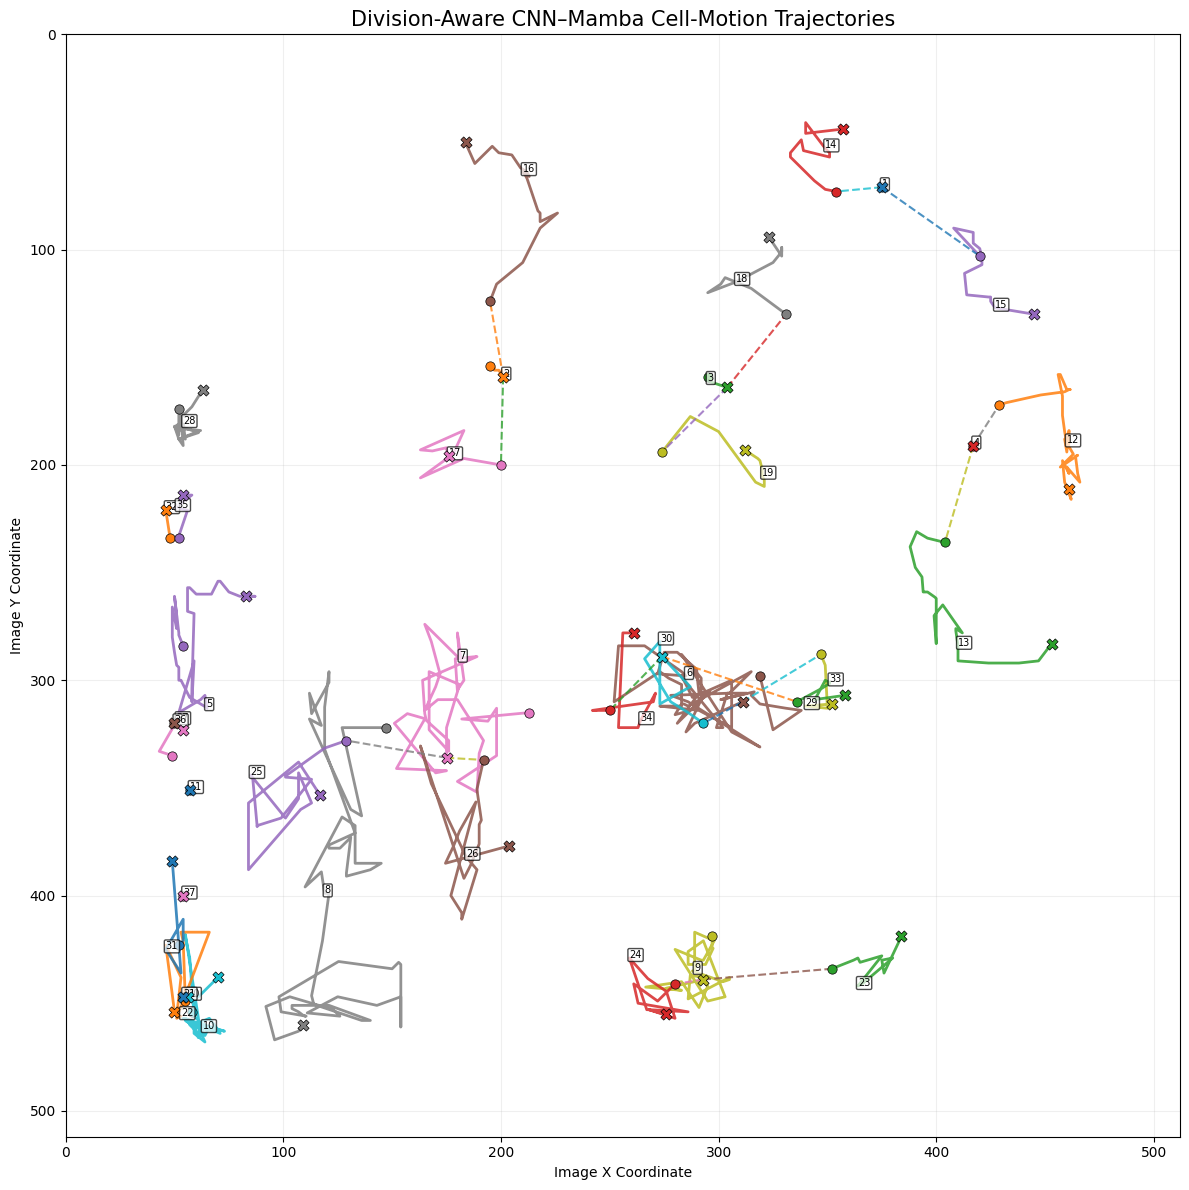

SPATIAL CELL-MOTION TRAJECTORIES
Predicted tracks: 37
Lineage edges   : 16
Saved to        : /kaggle/working/temporal_mamba_ctc_results/cell31_spatial_motion_trajectories.png

Circle = trajectory start
X      = trajectory end
Dashed line = predicted parent–daughter connection

CELL 31 PASSED ✅


In [45]:
# ============================================================
# CELL 31 — PREDICTED CELL-MOTION TRAJECTORIES
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

RESULTS_DIR = "/kaggle/working/temporal_mamba_ctc_results"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)


# ============================================================
# REQUIRED OBJECTS
# ============================================================

assert "division_aware_tracks" in globals(), (
    "division_aware_tracks is missing. Run Cell 29 first."
)

assert "predicted_lineage_edges" in globals(), (
    "predicted_lineage_edges is missing. Run Cell 29 first."
)


# ============================================================
# CREATE SPATIAL TRAJECTORY PLOT
# ============================================================

plt.figure(
    figsize=(12, 12)
)


for predicted_track_id in sorted(
    division_aware_tracks
):

    track = division_aware_tracks[
        predicted_track_id
    ]

    detections = sorted(
        track["detections"],
        key=lambda detection: int(
            detection["frame"]
        )
    )

    if len(detections) == 0:
        continue

    centroids = np.asarray(
        [
            detection["centroid"]
            for detection
            in detections
        ],
        dtype=np.float32
    )

    # Centroid format:
    # (row, column)
    #
    # Image plotting:
    # x = column
    # y = row

    y_positions = centroids[:, 0]

    x_positions = centroids[:, 1]

    line = plt.plot(
        x_positions,
        y_positions,
        linewidth=2.0,
        alpha=0.85
    )[0]

    trajectory_color = (
        line.get_color()
    )

    # --------------------------------------------------------
    # Starting point
    # --------------------------------------------------------

    plt.scatter(
        x_positions[0],
        y_positions[0],
        marker="o",
        s=45,
        color=trajectory_color,
        edgecolors="black",
        linewidths=0.5,
        zorder=3
    )

    # --------------------------------------------------------
    # Ending point
    # --------------------------------------------------------

    plt.scatter(
        x_positions[-1],
        y_positions[-1],
        marker="X",
        s=65,
        color=trajectory_color,
        edgecolors="black",
        linewidths=0.5,
        zorder=4
    )

    # --------------------------------------------------------
    # Track-ID label
    # --------------------------------------------------------

    middle_index = (
        len(x_positions)
        //
        2
    )

    plt.text(
        x_positions[middle_index],
        y_positions[middle_index],
        str(predicted_track_id),
        fontsize=7,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            alpha=0.70
        )
    )


# ============================================================
# DRAW PARENT → DAUGHTER CONNECTIONS
# ============================================================

for parent_track_id, daughter_track_id in (
    predicted_lineage_edges
):

    parent_track = division_aware_tracks[
        int(parent_track_id)
    ]

    daughter_track = division_aware_tracks[
        int(daughter_track_id)
    ]

    parent_last_detection = (
        parent_track["detections"][-1]
    )

    daughter_first_detection = (
        daughter_track["detections"][0]
    )

    parent_y, parent_x = (
        parent_last_detection["centroid"]
    )

    daughter_y, daughter_x = (
        daughter_first_detection["centroid"]
    )

    plt.plot(
        [
            parent_x,
            daughter_x
        ],
        [
            parent_y,
            daughter_y
        ],
        linestyle="--",
        linewidth=1.5,
        alpha=0.80
    )


# ============================================================
# FORMAT
# ============================================================

plt.title(
    "Division-Aware CNN–Mamba Cell-Motion Trajectories",
    fontsize=15
)

plt.xlabel(
    "Image X Coordinate"
)

plt.ylabel(
    "Image Y Coordinate"
)

plt.xlim(
    0,
    512
)

plt.ylim(
    512,
    0
)

plt.grid(
    alpha=0.20
)

plt.tight_layout()


# ============================================================
# SAVE
# ============================================================

CELL_TRAJECTORY_PATH = os.path.join(
    RESULTS_DIR,
    "cell31_spatial_motion_trajectories.png"
)

plt.savefig(
    CELL_TRAJECTORY_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("=" * 70)

print(
    "SPATIAL CELL-MOTION TRAJECTORIES"
)

print("=" * 70)

print(
    "Predicted tracks:",
    len(
        division_aware_tracks
    )
)

print(
    "Lineage edges   :",
    len(
        predicted_lineage_edges
    )
)

print(
    "Saved to        :",
    CELL_TRAJECTORY_PATH
)

print(
    "\nCircle = trajectory start"
)

print(
    "X      = trajectory end"
)

print(
    "Dashed line = predicted parent–daughter connection"
)

print(
    "\nCELL 31 PASSED ✅"
)

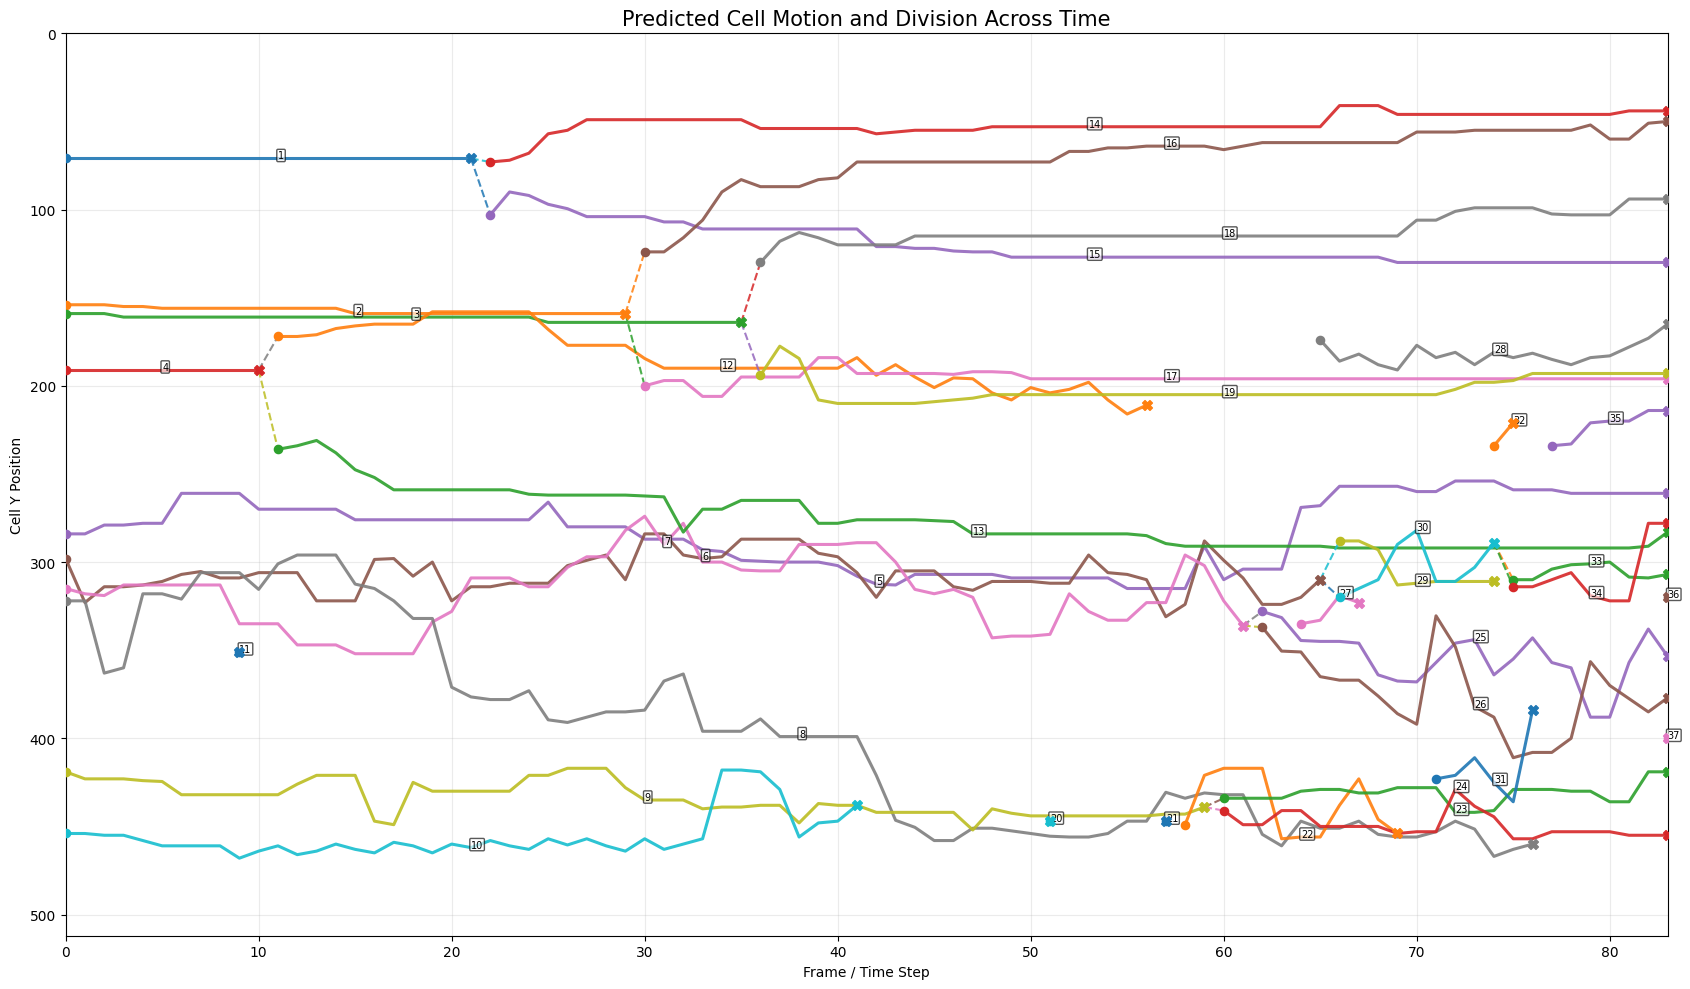

TIME–POSITION TRAJECTORY GRAPH
Tracks plotted: 37
Saved to      : /kaggle/working/temporal_mamba_ctc_results/cell32_time_position_trajectories.png

Horizontal direction = time
Vertical direction   = cell position
Dashed branches      = predicted divisions

CELL 32 PASSED ✅


In [46]:
# ============================================================
# CELL 32 — TIME–POSITION CELL-TRAJECTORY GRAPH
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

assert "division_aware_tracks" in globals()
assert "predicted_lineage_edges" in globals()
assert "RESULTS_DIR" in globals()

plt.figure(figsize=(17, 10))

track_plot_information = {}

for predicted_track_id in sorted(division_aware_tracks):

    track = division_aware_tracks[predicted_track_id]

    detections = sorted(
        track["detections"],
        key=lambda detection: int(detection["frame"])
    )

    if len(detections) == 0:
        continue

    frames = np.asarray(
        [
            int(detection["frame"])
            for detection in detections
        ],
        dtype=np.int32
    )

    centroids = np.asarray(
        [
            detection["centroid"]
            for detection in detections
        ],
        dtype=np.float32
    )

    y_positions = centroids[:, 0]

    line = plt.plot(
        frames,
        y_positions,
        linewidth=2.2,
        alpha=0.90
    )[0]

    trajectory_color = line.get_color()

    plt.scatter(
        frames[0],
        y_positions[0],
        marker="o",
        s=35,
        color=trajectory_color,
        zorder=3
    )

    plt.scatter(
        frames[-1],
        y_positions[-1],
        marker="X",
        s=50,
        color=trajectory_color,
        zorder=4
    )

    label_index = len(frames) // 2

    plt.text(
        frames[label_index],
        y_positions[label_index],
        str(predicted_track_id),
        fontsize=7,
        bbox=dict(
            boxstyle="round,pad=0.12",
            facecolor="white",
            alpha=0.65
        )
    )

    track_plot_information[int(predicted_track_id)] = {
        "frames": frames,
        "positions": y_positions
    }


# ============================================================
# DRAW PARENT → DAUGHTER CONNECTIONS
# ============================================================

for parent_track_id, daughter_track_id in predicted_lineage_edges:

    parent_information = track_plot_information[
        int(parent_track_id)
    ]

    daughter_information = track_plot_information[
        int(daughter_track_id)
    ]

    parent_frame = parent_information["frames"][-1]
    parent_position = parent_information["positions"][-1]

    daughter_frame = daughter_information["frames"][0]
    daughter_position = daughter_information["positions"][0]

    plt.plot(
        [parent_frame, daughter_frame],
        [parent_position, daughter_position],
        linestyle="--",
        linewidth=1.5,
        alpha=0.85
    )


# ============================================================
# FORMAT
# ============================================================

plt.title(
    "Predicted Cell Motion and Division Across Time",
    fontsize=15
)

plt.xlabel("Frame / Time Step")

plt.ylabel("Cell Y Position")

plt.xlim(0, 83)

plt.ylim(512, 0)

plt.grid(alpha=0.25)

plt.tight_layout()


# ============================================================
# SAVE
# ============================================================

TIME_TRAJECTORY_PATH = os.path.join(
    RESULTS_DIR,
    "cell32_time_position_trajectories.png"
)

plt.savefig(
    TIME_TRAJECTORY_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("=" * 70)

print("TIME–POSITION TRAJECTORY GRAPH")

print("=" * 70)

print(
    "Tracks plotted:",
    len(track_plot_information)
)

print(
    "Saved to      :",
    TIME_TRAJECTORY_PATH
)

print(
    "\nHorizontal direction = time"
)

print(
    "Vertical direction   = cell position"
)

print(
    "Dashed branches      = predicted divisions"
)

print(
    "\nCELL 32 PASSED ✅"
)

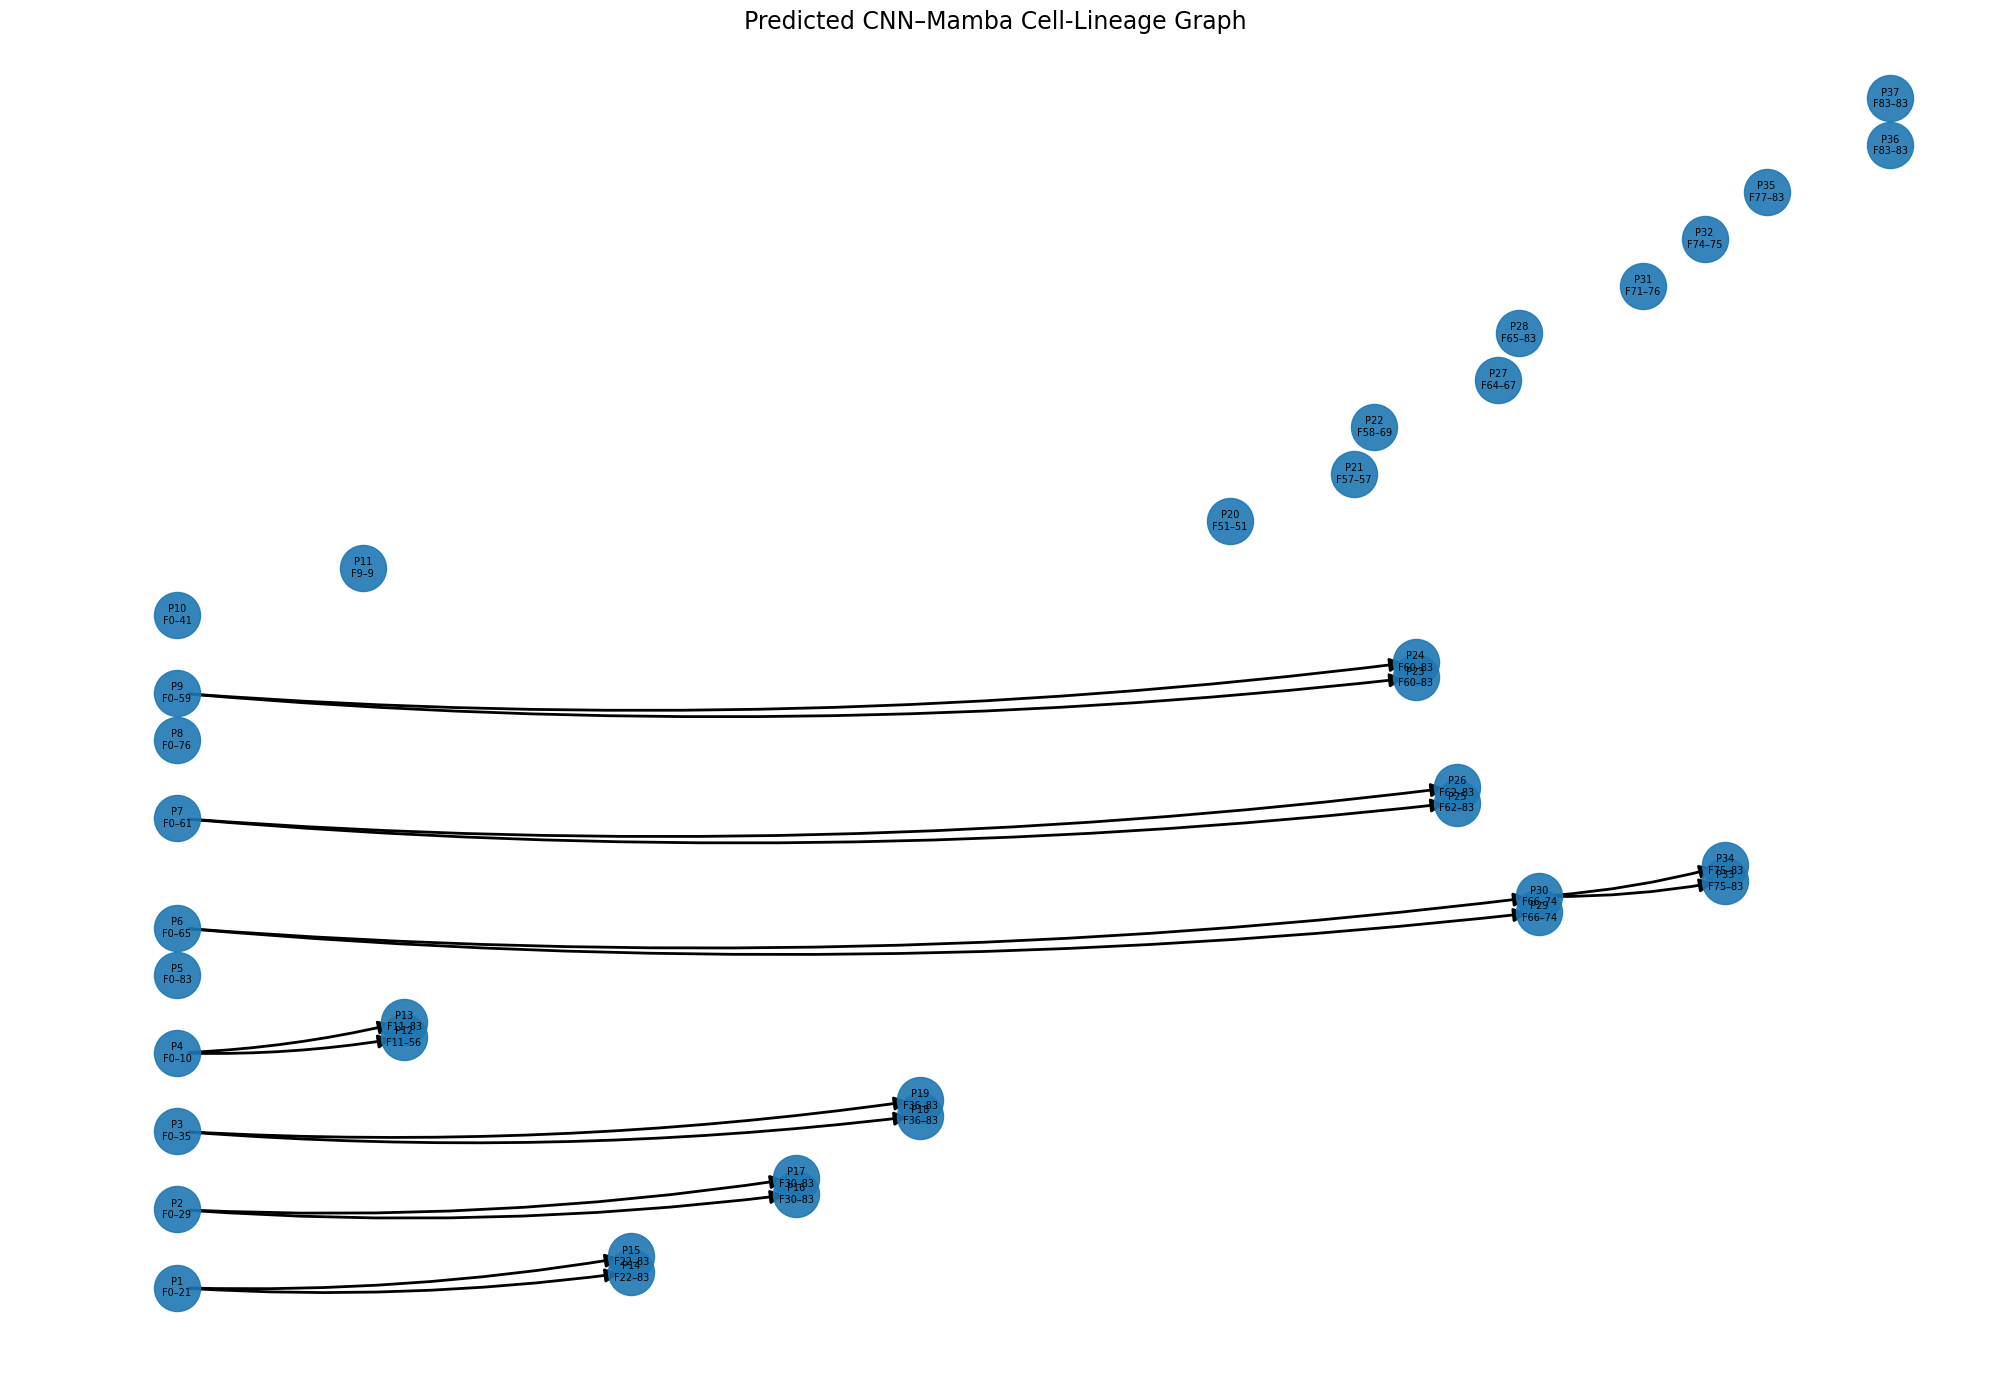

PREDICTED CELL-LINEAGE GRAPH
Predicted tracks: 37
Lineage edges   : 16
Root tracks     : 21

PREDICTED PARENT → DAUGHTER RELATIONSHIPS
Predicted Parent 1 → Daughters [14, 15]
Predicted Parent 2 → Daughters [16, 17]
Predicted Parent 3 → Daughters [18, 19]
Predicted Parent 4 → Daughters [12, 13]
Predicted Parent 6 → Daughters [29, 30]
Predicted Parent 7 → Daughters [25, 26]
Predicted Parent 9 → Daughters [23, 24]
Predicted Parent 30 → Daughters [33, 34]

Saved to: /kaggle/working/temporal_mamba_ctc_results/cell33_predicted_lineage_graph.png

CELL 33 PASSED ✅


In [47]:
# ============================================================
# CELL 33 — PREDICTED CELL-LINEAGE GRAPH
# ============================================================

import os
import matplotlib.pyplot as plt
import networkx as nx

assert "division_aware_tracks" in globals()
assert "predicted_lineage_edges" in globals()
assert "RESULTS_DIR" in globals()


# ============================================================
# CREATE DIRECTED LINEAGE GRAPH
# ============================================================

lineage_graph = nx.DiGraph()


# ============================================================
# ADD ALL PREDICTED TRACKS
# ============================================================

for predicted_track_id in sorted(division_aware_tracks):

    track = division_aware_tracks[predicted_track_id]

    lineage_graph.add_node(
        int(predicted_track_id),
        start_frame=int(track["start_frame"]),
        end_frame=int(track["end_frame"]),
        length=int(track["length"])
    )


# ============================================================
# ADD PARENT → DAUGHTER EDGES
# ============================================================

for parent_track_id, daughter_track_id in predicted_lineage_edges:

    lineage_graph.add_edge(
        int(parent_track_id),
        int(daughter_track_id)
    )


# ============================================================
# CREATE LINEAGE-TREE POSITIONS
# ============================================================

root_nodes = sorted(
    [
        node
        for node in lineage_graph.nodes
        if lineage_graph.in_degree(node) == 0
    ]
)

node_positions = {}

current_y = 0


for root_id in root_nodes:

    family_nodes = [
        root_id
    ] + sorted(
        nx.descendants(
            lineage_graph,
            root_id
        )
    )

    for family_index, node_id in enumerate(family_nodes):

        track = division_aware_tracks[node_id]

        start_frame = int(
            track["start_frame"]
        )

        node_positions[node_id] = (
            start_frame,
            current_y + family_index
        )

    current_y += len(family_nodes) + 2


# ============================================================
# DRAW LINEAGE GRAPH
# ============================================================

plt.figure(
    figsize=(20, 14)
)


nx.draw_networkx_nodes(
    lineage_graph,
    pos=node_positions,
    node_size=1100,
    alpha=0.90
)


nx.draw_networkx_edges(
    lineage_graph,
    pos=node_positions,
    arrows=True,
    arrowsize=20,
    width=2.0,
    connectionstyle="arc3,rad=0.05"
)


# ============================================================
# CREATE NODE LABELS
# ============================================================

node_labels = {}


for node_id in lineage_graph.nodes:

    track = division_aware_tracks[node_id]

    node_labels[node_id] = (
        f"P{node_id}\n"
        f"F{track['start_frame']}"
        f"–"
        f"{track['end_frame']}"
    )


nx.draw_networkx_labels(
    lineage_graph,
    pos=node_positions,
    labels=node_labels,
    font_size=7
)


# ============================================================
# FORMAT
# ============================================================

plt.title(
    "Predicted CNN–Mamba Cell-Lineage Graph",
    fontsize=17
)

plt.axis("off")

plt.tight_layout()


# ============================================================
# SAVE
# ============================================================

LINEAGE_GRAPH_PATH = os.path.join(
    RESULTS_DIR,
    "cell33_predicted_lineage_graph.png"
)

plt.savefig(
    LINEAGE_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# RESULTS
# ============================================================

print("=" * 70)

print(
    "PREDICTED CELL-LINEAGE GRAPH"
)

print("=" * 70)

print(
    "Predicted tracks:",
    lineage_graph.number_of_nodes()
)

print(
    "Lineage edges   :",
    lineage_graph.number_of_edges()
)

print(
    "Root tracks     :",
    len(root_nodes)
)


print(
    "\nPREDICTED PARENT → DAUGHTER RELATIONSHIPS"
)


for parent_id in sorted(lineage_graph.nodes):

    daughter_ids = sorted(
        lineage_graph.successors(
            parent_id
        )
    )

    if len(daughter_ids) > 0:

        print(
            f"Predicted Parent "
            f"{parent_id}"
            f" → "
            f"Daughters "
            f"{daughter_ids}"
        )


print(
    "\nSaved to:",
    LINEAGE_GRAPH_PATH
)

print(
    "\nCELL 33 PASSED ✅"
)